#### Aggregated weighted full-school network (static, weighted)  SocioPatterns High School (2013)

In [ ]:
# ============================================================
# Load Libraries
# ============================================================
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy import stats as scipy_stats
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# -----------------------------
# Paths (as uploaded)
# -----------------------------
CONTACTS_PATH = "High-School_data_2013.csv"
META_PATH     = "metadata_2013.txt"


In [ ]:
# -----------------------------
# 0) Load data
# -----------------------------
def load_contacts(path: str) -> pd.DataFrame:
    """
    Expected whitespace-separated columns:
    t i j class_i class_j
    """
    df = pd.read_csv(path, sep=r"\s+", header=None, names=["t", "i", "j", "class_i", "class_j"])
    df["i"] = df["i"].astype(int)
    df["j"] = df["j"].astype(int)
    return df

def load_metadata(path: str) -> pd.DataFrame:
    """
    Expected whitespace-separated columns:
    id class gender
    """
    meta = pd.read_csv(path, sep=r"\s+", header=None, names=["id", "class", "gender"])
    meta["id"] = meta["id"].astype(int)
    meta["class"] = meta["class"].astype(str)
    meta["gender"] = meta["gender"].astype(str)
    return meta

contacts = load_contacts(CONTACTS_PATH)
meta = load_metadata(META_PATH)

print("Contacts:", contacts.shape, "Metadata:", meta.shape)
print(contacts.head())
print(meta.head())

Contacts: (188508, 5) Metadata: (329, 3)
            t    i    j class_i class_j
0  1385982020  454  640      MP      MP
1  1385982020    1  939   2BIO3   2BIO3
2  1385982020  185  258     PC*     PC*
3  1385982020   55  170   2BIO3   2BIO3
4  1385982020    9  453      PC      PC
    id  class gender
0  650  2BIO1      F
1  498  2BIO1      F
2  627  2BIO1      F
3  857  2BIO1      F
4  487  2BIO1      F


In [ ]:
# -----------------------------
# 1) Build aggregated weighted graph
# -----------------------------
def aggregate_edges(contacts: pd.DataFrame, dt_seconds: int = 20) -> pd.DataFrame:
    """
    Aggregates pairwise contacts into undirected edges:
    - count: number of contact records
    - duration_s: count * dt_seconds
    """
    uv = np.sort(contacts[["i", "j"]].values, axis=1)
    tmp = contacts.copy()
    tmp["u"] = uv[:, 0]
    tmp["v"] = uv[:, 1]

    agg = tmp.groupby(["u", "v"]).size().reset_index(name="count")
    agg["duration_s"] = agg["count"] * dt_seconds
    return agg

edge_df = aggregate_edges(contacts, dt_seconds=20)
print("Aggregated edges:", edge_df.shape)
print(edge_df.head())

def build_graph(edge_df: pd.DataFrame, meta: pd.DataFrame) -> nx.Graph:
    """
    Graph edges contain:
    - count
    - duration_s
    We'll also prepare normalized weights:
    - w_count_norm
    - w_dur_norm
    Node attributes:
    - class
    - gender
    """
    G = nx.Graph()

    # add edges
    for _, r in edge_df.iterrows():
        u, v = int(r["u"]), int(r["v"])
        G.add_edge(
            u, v,
            count=float(r["count"]),
            duration_s=float(r["duration_s"]),
        )

    # node attributes from metadata
    mm = meta.set_index("id")[["class", "gender"]].to_dict(orient="index")
    for n in G.nodes():
        if n in mm:
            G.nodes[n]["class"] = mm[n]["class"]
            G.nodes[n]["gender"] = mm[n]["gender"]
        else:
            G.nodes[n]["class"] = "Unknown"
            G.nodes[n]["gender"] = "Unknown"

    # normalized edge weights (important for curvature + infection probs)
    counts = np.array([d["count"] for _, _, d in G.edges(data=True)], dtype=float)
    durs   = np.array([d["duration_s"] for _, _, d in G.edges(data=True)], dtype=float)

    # scale to (0,1] using max (simple, stable)
    cmax = counts.max() if len(counts) else 1.0
    dmax = durs.max() if len(durs) else 1.0

    for u, v, d in G.edges(data=True):
        d["w_count_norm"] = d["count"] / cmax if cmax > 0 else 0.0
        d["w_dur_norm"]   = d["duration_s"] / dmax if dmax > 0 else 0.0

    return G

G = build_graph(edge_df, meta)
print("Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

Aggregated edges: (5818, 4)
   u    v  count  duration_s
0  1   55      8         160
1  1   63      2          40
2  1  101      1          20
3  1  106      4          80
4  1  117     18         360
Graph: 327 nodes, 5818 edges


In [ ]:
# -----------------------------
# 2) Global structure & mixing
# -----------------------------
def global_structure_stats(G: nx.Graph, weight_attr: str = "duration_s") -> Dict[str, float]:
    """
    Basic network statistics. Uses weighted degree ('strength') and weighted clustering.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)

    # weighted degree / strength
    strengths = np.array([G.degree(v, weight=weight_attr) for v in G.nodes()], dtype=float)
    degrees   = np.array([G.degree(v) for v in G.nodes()], dtype=float)

    # weighted clustering
    wclust = nx.clustering(G, weight=weight_attr)
    avg_wclust = float(np.mean(list(wclust.values()))) if len(wclust) else 0.0

    # assortativity by class and gender
    # (NetworkX treats attributes as categorical; Unknowns will be included)
    class_assort  = nx.attribute_assortativity_coefficient(G, "class")
    gender_assort = nx.attribute_assortativity_coefficient(G, "gender")

    out = {
        "n_nodes": n,
        "n_edges": m,
        "density": density,
        "degree_mean": float(degrees.mean()),
        "degree_p95": float(np.percentile(degrees, 95)),
        "strength_mean": float(strengths.mean()),
        "strength_p95": float(np.percentile(strengths, 95)),
        "avg_weighted_clustering": avg_wclust,
        "assortativity_class": float(class_assort),
        "assortativity_gender": float(gender_assort),
    }
    return out

stats_dur = global_structure_stats(G, weight_attr="duration_s")
stats_cnt = global_structure_stats(G, weight_attr="count")

print("\n--- Global stats (duration_s weights) ---")
for k, v in stats_dur.items():
    print(f"{k:>28}: {v}")

print("\n--- Global stats (count weights) ---")
for k, v in stats_cnt.items():
    print(f"{k:>28}: {v}")

def compute_communities_louvain(G: nx.Graph, weight_attr: str = "duration_s") -> Tuple[List[set], float]:
    """
    Community structure + modularity.
    Uses NetworkX louvain if available; falls back to greedy modularity.
    """
    try:
        from networkx.algorithms.community import louvain_communities
        comms = louvain_communities(G, weight=weight_attr, seed=42)
        mod = nx.algorithms.community.modularity(G, comms, weight=weight_attr)
        return comms, float(mod)
    except Exception:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G, weight=weight_attr))
        mod = nx.algorithms.community.modularity(G, comms, weight=weight_attr)
        return comms, float(mod)

comms_dur, mod_dur = compute_communities_louvain(G, weight_attr="duration_s")
print("\nCommunities (duration_s):", len(comms_dur), "Modularity:", mod_dur)



--- Global stats (duration_s weights) ---
                     n_nodes: 327
                     n_edges: 5818
                     density: 0.10915367441511416
                 degree_mean: 35.584097859327215
                  degree_p95: 57.0
               strength_mean: 23059.08256880734
                strength_p95: 55248.0
     avg_weighted_clustering: 0.0023150680243185177
         assortativity_class: 0.6527202065166846
        assortativity_gender: 0.17183728104088722

--- Global stats (count weights) ---
                     n_nodes: 327
                     n_edges: 5818
                     density: 0.10915367441511416
                 degree_mean: 35.584097859327215
                  degree_p95: 57.0
               strength_mean: 1152.954128440367
                strength_p95: 2762.4
     avg_weighted_clustering: 0.0023150680243185177
         assortativity_class: 0.6527202065166846
        assortativity_gender: 0.17183728104088722

Communities (duration_s): 10 Modularity

In [ ]:
# -----------------------------
# 3) Curvature profiling (Forman–Ricci on weighted graph)
# USed FormanRicci class (uniform with the published paper)
# -----------------------------


class FormanRicci:
    def __init__(self, G: nx.Graph):
        self.G = G.copy()

    def compute_ricci_curvature(self) -> nx.Graph:
        """
        Compute the Forman-Ricci curvature for all edges and nodes in an undirected graph.
        Stores:
          - edge attr: 'formanCurvature'
          - node attr: 'formanCurvature' (average over incident edges)
        """
        if self.G.is_directed():
            raise ValueError("The graph must be undirected.")

        # Iterate over all edges in the graph
        for u, v in self.G.edges():
            # Edge weight (default 1)
            w_e = float(self.G[u][v].get("weight", 1.0))
            w_e = max(w_e, 1e-12)

            # Node weights (default 1)
            w_u = float(self.G.nodes[u].get("weight", 1.0))
            w_v = float(self.G.nodes[v].get("weight", 1.0))

            # Summation terms
            sum_u = 0.0
            sum_v = 0.0

            # Adjacent to u
            for _, u_neigh in self.G.edges(u):
                if u_neigh == v:
                    continue
                w_u_neigh = float(self.G[u][u_neigh].get("weight", 1.0))
                w_u_neigh = max(w_u_neigh, 1e-12)
                sum_u += w_u / np.sqrt(w_e * w_u_neigh)

            # Adjacent to v
            for _, v_neigh in self.G.edges(v):
                if v_neigh == u:
                    continue
                w_v_neigh = float(self.G[v][v_neigh].get("weight", 1.0))
                w_v_neigh = max(w_v_neigh, 1e-12)
                sum_v += w_v / np.sqrt(w_e * w_v_neigh)

            # Forman-Ricci curvature
            F_e = w_e * (w_u / w_e + w_v / w_e - sum_u - sum_v)

            # Store
            self.G[u][v]["formanCurvature"] = float(F_e)

        # Average curvature per node
        for n in self.G.nodes():
            deg = self.G.degree(n)
            if deg == 0:
                self.G.nodes[n]["formanCurvature"] = 0.0
            else:
                fcsum = 0.0
                for nbr in self.G.neighbors(n):
                    fcsum += float(self.G[n][nbr].get("formanCurvature", 0.0))
                self.G.nodes[n]["formanCurvature"] = fcsum / deg

        print("Forman curvature computation done.")
        return self.G


# -----------------------------
# Helpers: run FRC on either count- or duration-normalized weights
# -----------------------------
def attach_weight_for_frc(G: nx.Graph, w_attr: str, node_weight_attr: str = None) -> nx.Graph:
    """
    Create a copy of G and map chosen edge attribute -> 'weight' for FormanRicci class.

    Parameters
    ----------
    w_attr : str
        Edge attribute to use as weight (e.g. 'w_dur_norm' or 'w_count_norm').
    node_weight_attr : str or None
        Optional node attribute to use as node weight. If None, node weights default to 1.
        (In your published-paper class, node weights are read from G.nodes[n]['weight'].)
    """
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d["weight"] = float(d.get(w_attr, 1.0))
    if node_weight_attr is not None:
        for n in H.nodes():
            H.nodes[n]["weight"] = float(H.nodes[n].get(node_weight_attr, 1.0))
    else:
        # ensure no stale node weights interfere
        for n in H.nodes():
            if "weight" in H.nodes[n]:
                # keep if you intentionally set it elsewhere; otherwise set to 1
                pass
    return H

def extract_edge_curvature(G_frc: nx.Graph) -> Dict[Tuple[int, int], float]:
    """
    Extract edge 'formanCurvature' as dict keyed by (u,v).
    """
    curv = {}
    for u, v, d in G_frc.edges(data=True):
        curv[(u, v)] = float(d.get("formanCurvature", 0.0))
    return curv

def curvature_summary(curv: Dict[Tuple[int, int], float], q=(1, 5, 50, 95, 99)) -> Dict[str, float]:
    vals = np.array(list(curv.values()), dtype=float)
    out = {
        "min": float(vals.min()),
        "max": float(vals.max()),
        "mean": float(vals.mean()),
        "median": float(np.median(vals)),
    }
    for qq in q:
        out[f"q{qq}"] = float(np.percentile(vals, qq))
    return out

def edge_attribute_df_from_frc(G: nx.Graph, G_frc: nx.Graph) -> pd.DataFrame:
    """
    Build edge dataframe including curvature from G_frc (edge attr 'formanCurvature').
    Keeps your original columns + 'curvature' field.
    """
    rows = []
    for u, v, d in G.edges(data=True):
        # curvature in G_frc (either (u,v) or (v,u))
        if G_frc.has_edge(u, v):
            c = float(G_frc[u][v].get("formanCurvature", 0.0))
        else:
            c = float(G_frc[v][u].get("formanCurvature", 0.0))

        rows.append({
            "u": u, "v": v,
            "count": float(d.get("count", 0.0)),
            "duration_s": float(d.get("duration_s", 0.0)),
            "w_count_norm": float(d.get("w_count_norm", 0.0)),
            "w_dur_norm": float(d.get("w_dur_norm", 0.0)),
            "curvature": c,
            "class_u": G.nodes[u].get("class", "Unknown"),
            "class_v": G.nodes[v].get("class", "Unknown"),
            "gender_u": G.nodes[u].get("gender", "Unknown"),
            "gender_v": G.nodes[v].get("gender", "Unknown"),
            "inter_class": int(G.nodes[u].get("class") != G.nodes[v].get("class")),
        })
    return pd.DataFrame(rows)


# -----------------------------
# Compute curvature on normalized weights (count and duration)
# -----------------------------
# G is your aggregated graph from earlier steps
# - for duration-based curvature use w_dur_norm
# - for count-based curvature use w_count_norm

G_for_dur = attach_weight_for_frc(G, w_attr="w_dur_norm")
G_for_cnt = attach_weight_for_frc(G, w_attr="w_count_norm")

G_frc_dur = FormanRicci(G_for_dur).compute_ricci_curvature()
G_frc_cnt = FormanRicci(G_for_cnt).compute_ricci_curvature()

curv_dur = extract_edge_curvature(G_frc_dur)
curv_count = extract_edge_curvature(G_frc_cnt)

print("\n--- Curvature summary (count norm; FRC class) ---")
print(curvature_summary(curv_count))

print("\n--- Curvature summary (duration norm; FRC class) ---")
print(curvature_summary(curv_dur))


# -----------------------------
# Edge-level analysis: extreme negative bridges + compare with betweenness
# -----------------------------
edges_curv_dur = edge_attribute_df_from_frc(G, G_frc_dur)

K = 50  # you can change this
extreme_neg = edges_curv_dur.sort_values("curvature", ascending=True).head(K)

print(f"\nTop-{K} most negative curvature edges: inter-class fraction =",
      float(extreme_neg["inter_class"].mean()))

print("\nExamples of extreme negative-curvature edges (u,v,curv, inter_class):")
print(extreme_neg[["u","v","curvature","inter_class","class_u","class_v"]].head(10))


print("\nComputing edge betweenness centrality (may take a bit on larger graphs)...")
eb = nx.edge_betweenness_centrality(G, weight="duration_s")  # weighted shortest paths

edges_curv_dur["edge_betweenness"] = edges_curv_dur.apply(
    lambda r: eb.get((r["u"], r["v"]), eb.get((r["v"], r["u"]), 0.0)), axis=1
)

top_b = set(tuple(x) for x in edges_curv_dur.sort_values("edge_betweenness", ascending=False)[["u","v"]].head(K).values)
top_c = set(tuple(x) for x in edges_curv_dur.sort_values("curvature", ascending=True)[["u","v"]].head(K).values)

agree = top_b.intersection(top_c)
disagree_c_only = top_c - top_b
disagree_b_only = top_b - top_c

print(f"\nAgreement size (Top-{K}):", len(agree))
print("Curvature-only edges:", len(disagree_c_only))
print("Betweenness-only edges:", len(disagree_b_only))


# -----------------------------
# Node-level comparison: curvature concentration vs strength
# Using the same definition as your earlier code: sum of (-curvature) over negative edges
# (You can also directly use node avg curvature stored in G_frc_dur.nodes[n]['formanCurvature'])
# -----------------------------
node_neg_curv = {n: 0.0 for n in G.nodes()}
for (u, v), c in curv_dur.items():
    if c < 0:
        node_neg_curv[u] += (-c)
        node_neg_curv[v] += (-c)

strength = {n: float(G.degree(n, weight="duration_s")) for n in G.nodes()}

node_df = pd.DataFrame({
    "node": list(G.nodes()),
    "neg_curv_score": [node_neg_curv[n] for n in G.nodes()],
    "strength": [strength[n] for n in G.nodes()],
    "avg_node_curvature": [float(G_frc_dur.nodes[n].get("formanCurvature", 0.0)) for n in G.nodes()],
    "class": [G.nodes[n].get("class") for n in G.nodes()],
    "gender": [G.nodes[n].get("gender") for n in G.nodes()],
})

node_df["neg_curv_rank"] = node_df["neg_curv_score"].rank(ascending=False, method="min")
node_df["strength_rank"] = node_df["strength"].rank(ascending=False, method="min")

print("\nTop nodes by negative-curvature score:")
print(node_df.sort_values("neg_curv_score", ascending=False).head(10)[
    ["node","neg_curv_score","avg_node_curvature","strength","class","gender"]
])

Forman curvature computation done.
Forman curvature computation done.

--- Curvature summary (count norm; FRC class) ---
{'min': -2772.761020235241, 'max': -9.796184150435282, 'mean': -154.28290600754212, 'median': -81.6330535246554, 'q1': -1075.091307404626, 'q5': -542.2537168647298, 'q50': -81.6330535246554, 'q95': -31.64810440992822, 'q99': -23.26024984471136}

--- Curvature summary (duration norm; FRC class) ---
{'min': -2772.761020235241, 'max': -9.796184150435282, 'mean': -154.28290600754212, 'median': -81.6330535246554, 'q1': -1075.091307404626, 'q5': -542.2537168647298, 'q50': -81.6330535246554, 'q95': -31.64810440992822, 'q99': -23.26024984471136}

Top-50 most negative curvature edges: inter-class fraction = 0.06

Examples of extreme negative-curvature edges (u,v,curv, inter_class):
         u     v    curvature  inter_class class_u class_v
5063   275   255 -2772.761020            0   2BIO3   2BIO3
832      3   884 -2627.404683            0   2BIO2   2BIO2
795      3   147 -26

In [ ]:
# ============================================================
# EPIDEMIC SIMULATION (Curvature-modulated SIR)
# Aligned with published framework:
#   beta_ij = beta0 * exp(F(e_ij))
# and infection probability per step:
#   p_ij = 1 - exp( - beta_ij * w_ij )
# where w_ij is our chosen (normalized) contact weight.
# ============================================================


# -----------------------------
# Result container
# -----------------------------
@dataclass
class SIRResult:
    peak_infected: int
    peak_time: int
    final_size: int
    curve_I: List[int]


# -----------------------------
# Curvature-modulated SIR simulation (discrete-time τ-leap style)
# -----------------------------
def simulate_curvature_sir_discrete(
    G: nx.Graph,
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    seed: int = 1,
    initial_infected: Optional[List[int]] = None,
    max_steps: int = 5000,
) -> SIRResult:
    """
    Discrete-time stochastic SIR on a static weighted network, aligned with published framework.

    Published transmission law:
      beta_ij = beta0 * exp(F(e_ij))

    We use a hazard-to-probability mapping per time step (Δt = 1):
      p_ij = 1 - exp( - beta_ij * w_ij )

    Recovery probability per infected per step:
      p_rec = 1 - exp(-gamma)

    Parameters
    ----------
    G : nx.Graph
        Undirected graph with edge attributes:
          - weight_attr (e.g. 'w_dur_norm' or 'w_count_norm')
          - curvature_attr (e.g. 'formanCurvature')
    beta0 : float
        Baseline transmission rate (β0)
    gamma : float
        Recovery rate (γ)
    weight_attr : str
        Edge weight attribute used as contact intensity
    curvature_attr : str
        Edge curvature attribute (default 'formanCurvature')
    seed : int
        RNG seed
    initial_infected : list[int] or None
        Initial infected nodes; if None, picks one random node
    max_steps : int
        Max simulation steps

    Returns
    -------
    SIRResult
    """
    if G.is_directed():
        raise ValueError("This simulation expects an undirected graph.")

    rng = random.Random(seed)
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return SIRResult(peak_infected=0, peak_time=0, final_size=0, curve_I=[0])

    if initial_infected is None:
        initial_infected = [rng.choice(nodes)]

    # State sets
    S = set(nodes)
    I = set(initial_infected)
    R = set()

    for x in initial_infected:
        S.discard(x)

    I_curve = [len(I)]
    peak_I = len(I)
    peak_t = 0

    # Precompute recovery probability
    p_rec = 1.0 - math.exp(-gamma)

    for t in range(1, max_steps + 1):
        if len(I) == 0:
            break

        new_infected = set()
        new_recovered = set()

        # Infections (curvature-modulated)
        for i in I:
            for j in G.neighbors(i):
                if j not in S:
                    continue

                w_ij = float(G[i][j].get(weight_attr, 0.0))
                if w_ij <= 0.0:
                    continue

                kappa_ij = float(G[i][j].get(curvature_attr, 0.0))

                # Published law: beta_ij = beta0 * exp(F(e_ij))
                beta_ij = beta0 * math.exp(kappa_ij)

                # τ-leap probability for Δt=1
                p_inf = 1.0 - math.exp(-beta_ij * w_ij)

                if rng.random() < p_inf:
                    new_infected.add(j)

        # Recoveries
        for i in I:
            if rng.random() < p_rec:
                new_recovered.add(i)

        # Update sets
        for j in new_infected:
            S.discard(j)
        I |= new_infected
        I -= new_recovered
        R |= new_recovered

        I_curve.append(len(I))
        if len(I) > peak_I:
            peak_I = len(I)
            peak_t = t

    final_size = len(R) + len(I)
    return SIRResult(
        peak_infected=peak_I,
        peak_time=peak_t,
        final_size=final_size,
        curve_I=I_curve
    )


# -----------------------------
# Epidemic threshold proxy (heuristic)
# -----------------------------
def threshold_proxy(G: nx.Graph, weight_attr: str, curvature_attr: str = "formanCurvature", beta0: float = 1.0) -> float:
    """
    Heuristic threshold proxy based on spectral radius of an effective weighted adjacency.

    Since beta_ij = beta0 * exp(kappa_ij), define effective edge weight:
      a_ij = beta0 * exp(kappa_ij) * w_ij

    Then lambda_max(A_eff) is a proxy; an R0-like proxy would be:
      R0_proxy ~ lambda_max(A_eff) / gamma

    Note: This is a heuristic for the discrete-time stochastic model.
    """
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return 0.0

    idx = {n: i for i, n in enumerate(nodes)}
    A = np.zeros((len(nodes), len(nodes)), dtype=float)

    for u, v, d in G.edges(data=True):
        w = float(d.get(weight_attr, 0.0))
        if w <= 0.0:
            continue
        kappa = float(d.get(curvature_attr, 0.0))
        a = beta0 * math.exp(kappa) * w

        i, j = idx[u], idx[v]
        A[i, j] = a
        A[j, i] = a

    vals = np.linalg.eigvalsh(A)
    return float(vals.max())


# -----------------------------
# Ensemble runner
# -----------------------------
def run_curvature_sir_ensemble(
    G: nx.Graph,
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    n_runs: int = 200,
    seed0: int = 123,
    max_steps: int = 2000
) -> Dict[str, float]:
    peaks, peaktimes, finals = [], [], []

    for r in range(n_runs):
        res = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=seed0 + r,
            max_steps=max_steps
        )
        peaks.append(res.peak_infected)
        peaktimes.append(res.peak_time)
        finals.append(res.final_size)

    return {
        "beta0": float(beta0),
        "gamma": float(gamma),
        "weight_attr": weight_attr,
        "curvature_attr": curvature_attr,
        "peak_I_mean": float(np.mean(peaks)),
        "peak_t_mean": float(np.mean(peaktimes)),
        "final_size_mean": float(np.mean(finals)),
        "peak_I_p90": float(np.percentile(peaks, 90)),
        "final_size_p90": float(np.percentile(finals, 90)),
    }


# ============================================================
# EXAMPLE USAGE
# Requirements:
# - Our graph G must already have:
#     edges: weight_attr (e.g. 'w_dur_norm' / 'w_count_norm')
#     edges: 'formanCurvature' (from 0our FormanRicci class)
# ============================================================

# Baseline parameters (tune later)
BETA0 = 1.2 #0.8   # β0 (baseline transmission rate)
GAMMA = 0.08  # γ  (recovery rate)

# Duration-normalized weights
sir_dur = run_curvature_sir_ensemble(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_dur_norm",
    curvature_attr="formanCurvature",
    n_runs=200, seed0=123, max_steps=2000
)

# Count-normalized weights (sensitivity)
sir_cnt = run_curvature_sir_ensemble(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_count_norm",
    curvature_attr="formanCurvature",
    n_runs=200, seed0=123, max_steps=2000
)

print("\n--- Curvature-SIR ensemble (duration normalized) ---")
print(sir_dur)

print("\n--- Curvature-SIR ensemble (count normalized) ---")
print(sir_cnt)

# Threshold proxies (heuristic)
lam_eff_dur = threshold_proxy(G, weight_attr="w_dur_norm", curvature_attr="formanCurvature", beta0=BETA0)
lam_eff_cnt = threshold_proxy(G, weight_attr="w_count_norm", curvature_attr="formanCurvature", beta0=BETA0)

print("\nSpectral radius lambda_max (effective, dur_norm):", lam_eff_dur)
print("Spectral radius lambda_max (effective, count_norm):", lam_eff_cnt)

print("\nR0 proxy (dur):", lam_eff_dur / GAMMA if GAMMA > 0 else float("inf"))
print("R0 proxy (cnt):", lam_eff_cnt / GAMMA if GAMMA > 0 else float("inf"))


--- Curvature-SIR ensemble (duration normalized) ---
{'beta0': 1.2, 'gamma': 0.08, 'weight_attr': 'w_dur_norm', 'curvature_attr': 'formanCurvature', 'peak_I_mean': 57.395, 'peak_t_mean': 36.095, 'final_size_mean': 193.82, 'peak_I_p90': 98.0, 'final_size_p90': 288.1}

--- Curvature-SIR ensemble (count normalized) ---
{'beta0': 1.2, 'gamma': 0.08, 'weight_attr': 'w_count_norm', 'curvature_attr': 'formanCurvature', 'peak_I_mean': 57.395, 'peak_t_mean': 36.095, 'final_size_mean': 193.82, 'peak_I_p90': 98.0, 'final_size_p90': 288.1}

Spectral radius lambda_max (effective, dur_norm): 1.2830779955482035
Spectral radius lambda_max (effective, count_norm): 1.2830779955482035

R0 proxy (dur): 16.038474944352544
R0 proxy (cnt): 16.038474944352544


In [ ]:
# -----------------------------
# 5) Intervention experiments (CURVATURE-ALIGNED)
# -----------------------------

from typing import List, Tuple, Dict
import networkx as nx
import pandas as pd


def remove_edges_by_list(G: nx.Graph, edges_to_remove: List[Tuple[int, int]]) -> nx.Graph:
    H = G.copy()
    H.remove_edges_from(edges_to_remove)
    return H


def remove_nodes_by_list(G: nx.Graph, nodes_to_remove: List[int]) -> nx.Graph:
    H = G.copy()
    H.remove_nodes_from(nodes_to_remove)
    return H


def intervention_sets(
    G: nx.Graph,
    curv: Dict[Tuple[int, int], float],
    budget_edges_frac: float = 0.02,
    budget_nodes_frac: float = 0.02,
    betweenness_weight: str = "duration_s",
    strength_weight: str = "duration_s"
) -> Dict[str, Dict]:
    """
    Define intervention targets under equal budget:
      - edge_curvature: remove most negative-FRC edges
      - edge_betweenness: remove highest betweenness edges
      - node_strength: remove highest-strength nodes
    """
    m = G.number_of_edges()
    n = G.number_of_nodes()

    m_budget = max(1, int(round(budget_edges_frac * m)))
    n_budget = max(1, int(round(budget_nodes_frac * n)))

    # --- Curvature-based edges (most negative FRC)
    curv_sorted = sorted(curv.items(), key=lambda x: x[1])  # ascending = most negative
    edges_curv = [e for e, _ in curv_sorted[:m_budget]]

    # --- Betweenness-based edges
    eb = nx.edge_betweenness_centrality(G, weight=betweenness_weight)
    edges_betw = [e for e, _ in sorted(eb.items(), key=lambda x: x[1], reverse=True)[:m_budget]]

    # --- Strength-based nodes
    strength = {v: G.degree(v, weight=strength_weight) for v in G.nodes()}
    nodes_strength = [v for v, _ in sorted(strength.items(), key=lambda x: x[1], reverse=True)[:n_budget]]

    return {
        "edge_curvature": {"edge_budget": m_budget, "targets": edges_curv},
        "edge_betweenness": {"edge_budget": m_budget, "targets": edges_betw},
        "node_strength": {"node_budget": n_budget, "targets": nodes_strength},
    }


def evaluate_intervention_curvature_sir(
    G: nx.Graph,
    curv: Dict[Tuple[int, int], float],
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    budget_edges_frac: float = 0.02,
    budget_nodes_frac: float = 0.02,
    n_runs: int = 200,
    seed0: int = 555,
    max_steps: int = 2000
) -> pd.DataFrame:
    """
    Compare baseline vs interventions under the curvature-modulated SIR model.
    Reports:
      - cases averted
      - peak reduction
      - peak delay
    """

    # ---- Baseline
    base = run_curvature_sir_ensemble(
        G, beta0, gamma,
        weight_attr=weight_attr,
        curvature_attr=curvature_attr,
        n_runs=n_runs,
        seed0=seed0,
        max_steps=max_steps
    )

    base_peak = base["peak_I_mean"]
    base_time = base["peak_t_mean"]
    base_final = base["final_size_mean"]

    rows = [{
        "strategy": "baseline",
        "peak_I_mean": base_peak,
        "peak_t_mean": base_time,
        "final_size_mean": base_final,
        "cases_averted": 0.0,
        "peak_reduction": 0.0,
        "peak_delay": 0.0,
    }]

    sets = intervention_sets(G, curv, budget_edges_frac, budget_nodes_frac)

    # ---- Edge-based interventions
    for strat in ["edge_curvature", "edge_betweenness"]:
        H = remove_edges_by_list(G, sets[strat]["targets"])

        out = run_curvature_sir_ensemble(
            H, beta0, gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            n_runs=n_runs,
            seed0=seed0,
            max_steps=max_steps
        )

        rows.append({
            "strategy": strat,
            "peak_I_mean": out["peak_I_mean"],
            "peak_t_mean": out["peak_t_mean"],
            "final_size_mean": out["final_size_mean"],
            "cases_averted": base_final - out["final_size_mean"],
            "peak_reduction": base_peak - out["peak_I_mean"],
            "peak_delay": out["peak_t_mean"] - base_time,
        })

    # ---- Node-based intervention
    H = remove_nodes_by_list(G, sets["node_strength"]["targets"])
    out = run_curvature_sir_ensemble(
        H, beta0, gamma,
        weight_attr=weight_attr,
        curvature_attr=curvature_attr,
        n_runs=n_runs,
        seed0=seed0,
        max_steps=max_steps
    )

    rows.append({
        "strategy": "node_strength",
        "peak_I_mean": out["peak_I_mean"],
        "peak_t_mean": out["peak_t_mean"],
        "final_size_mean": out["final_size_mean"],
        "cases_averted": base_final - out["final_size_mean"],
        "peak_reduction": base_peak - out["peak_I_mean"],
        "peak_delay": out["peak_t_mean"] - base_time,
    })

    return pd.DataFrame(rows)

In [ ]:
BETA0 = 1.2
GAMMA = 0.08

interv_dur = evaluate_intervention_curvature_sir(
    G, curv_dur,
    beta0=BETA0,
    gamma=GAMMA,
    weight_attr="w_dur_norm",
    budget_edges_frac=0.02,
    budget_nodes_frac=0.02,
    n_runs=200
)

print("\n--- Curvature-SIR interventions (duration norm) ---")
print(interv_dur)

interv_cnt = evaluate_intervention_curvature_sir(
    G, curv_count,
    beta0=BETA0,
    gamma=GAMMA,
    weight_attr="w_count_norm",
    budget_edges_frac=0.02,
    budget_nodes_frac=0.02,
    n_runs=200
)

print("\n--- Curvature-SIR interventions (count norm) ---")
print(interv_cnt)



--- Curvature-SIR interventions (duration norm) ---
           strategy  peak_I_mean  peak_t_mean  final_size_mean  cases_averted  \
0          baseline       55.825        33.63          193.545          0.000   
1    edge_curvature       36.040        39.74          154.810         38.735   
2  edge_betweenness       55.540        36.16          192.185          1.360   
3     node_strength       52.710        36.83          190.795          2.750   

   peak_reduction  peak_delay  
0           0.000        0.00  
1          19.785        6.11  
2           0.285        2.53  
3           3.115        3.20  

--- Curvature-SIR interventions (count norm) ---
           strategy  peak_I_mean  peak_t_mean  final_size_mean  cases_averted  \
0          baseline       55.825        33.63          193.545          0.000   
1    edge_curvature       36.040        39.74          154.810         38.735   
2  edge_betweenness       55.540        36.16          192.185          1.360   
3     n

In [ ]:
# -----------------------------
# Save outputs (curvature-aligned)
# -----------------------------

edges_curv_dur.to_csv("edges_curvature_duration.csv", index=False)
node_df.to_csv("nodes_curvature_strength.csv", index=False)
interv_dur.to_csv("intervention_results_duration.csv", index=False)
interv_cnt.to_csv("intervention_results_count.csv", index=False)

print("\nSaved:")
print(" - edges_curvature_duration.csv")
print(" - nodes_curvature_strength.csv")
print(" - intervention_results_duration.csv")
print(" - intervention_results_count.csv")


Saved:
 - edges_curvature_duration.csv
 - nodes_curvature_strength.csv
 - intervention_results_duration.csv
 - intervention_results_count.csv


In [ ]:
# ============================================================
# PAPER-READY PLOTS (Curvature-SIR aligned)
# Requires (already computed earlier):
#   - G : aggregated full-school network with edge attrs:
#       'duration_s', 'count', 'w_dur_norm', 'w_count_norm', 'formanCurvature'
#   - edges_curv_dur : DataFrame with columns ['u','v','curvature','edge_betweenness', ...]
#   - curv_dur : dict of edge -> curvature (optional; used for histogram)
#
# Produces:
#   1) Degree histogram
#   2) Strength histogram (duration_s)
#   3) Curvature histogram (duration-normalized curvature values)
#   4) Curvature vs edge-betweenness scatter (+ Pearson/Spearman)
#   5) Epidemic curves with confidence bands using UPDATED curvature-SIR simulation:
#        beta_ij = beta0 * exp(F(e_ij))
# Saves figures as high-res PNG + PDF to figures/
# ============================================================

# -----------------------------
# Output folder
# -----------------------------
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------------
# Global plot style (clean, paper-ready)
# NOTE: using matplotlib defaults for colors
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_fig(name: str):
    png = os.path.join(FIG_DIR, f"{name}.png")
    pdf = os.path.join(FIG_DIR, f"{name}.pdf")
    plt.tight_layout()
    plt.savefig(png, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png}")
    print(f"Saved: {pdf}")

Saved: figures/degree_histogram.png
Saved: figures/degree_histogram.pdf


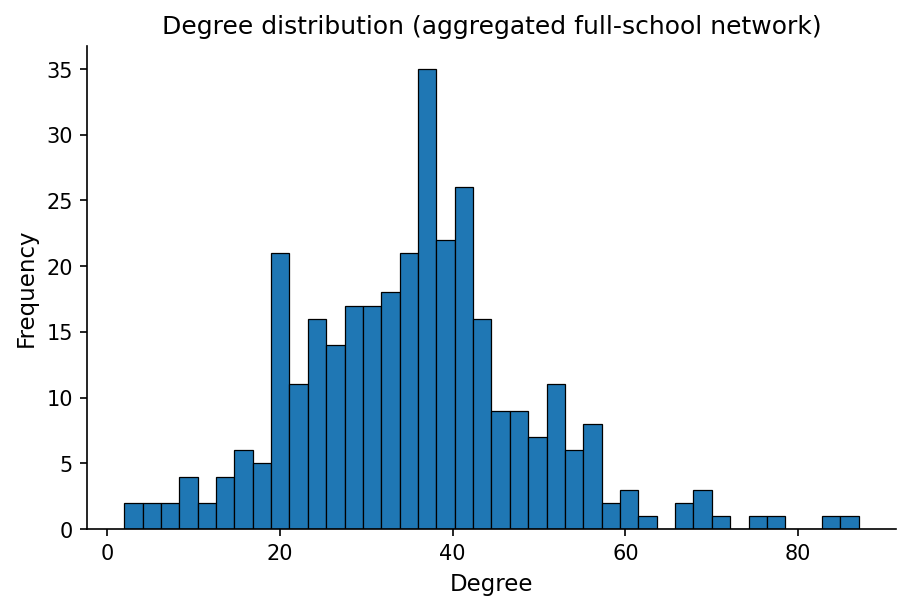

In [ ]:
# ============================================================
# 1) Degree histogram
# ============================================================
degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

plt.figure(figsize=(6.2, 4.2))
plt.hist(degrees, bins=40, edgecolor="black", linewidth=0.6)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree distribution (aggregated full-school network)")
save_fig("degree_histogram")
plt.show()

Saved: figures/strength_histogram_duration.png
Saved: figures/strength_histogram_duration.pdf


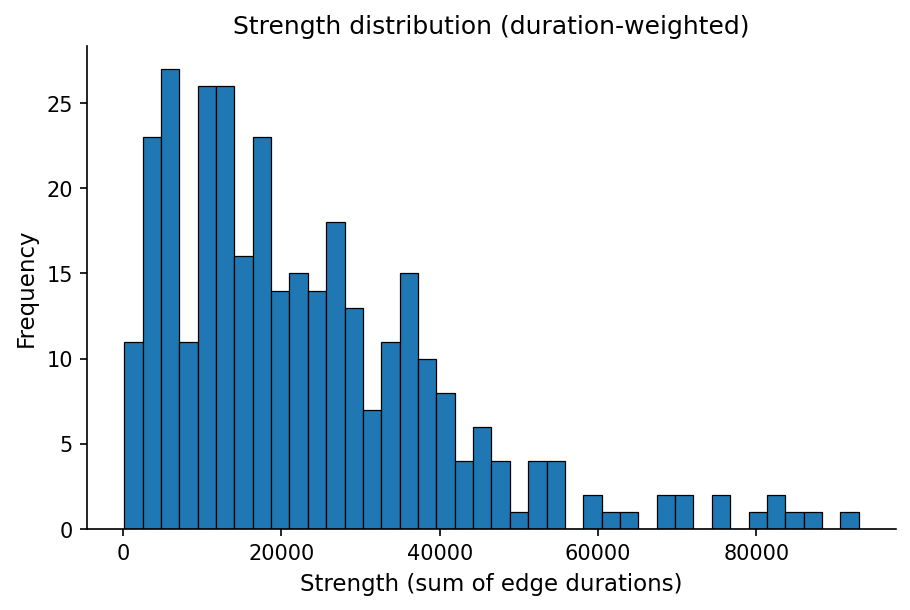

In [ ]:
# ============================================================
# 2) Strength histogram (duration_s)
# ============================================================
strengths = np.array([G.degree(n, weight="duration_s") for n in G.nodes()], dtype=float)

plt.figure(figsize=(6.2, 4.2))
plt.hist(strengths, bins=40, edgecolor="black", linewidth=0.6)
plt.xlabel("Strength (sum of edge durations)")
plt.ylabel("Frequency")
plt.title("Strength distribution (duration-weighted)")
save_fig("strength_histogram_duration")
plt.show()

Saved: figures/curvature_histogram_duration_norm.png
Saved: figures/curvature_histogram_duration_norm.pdf


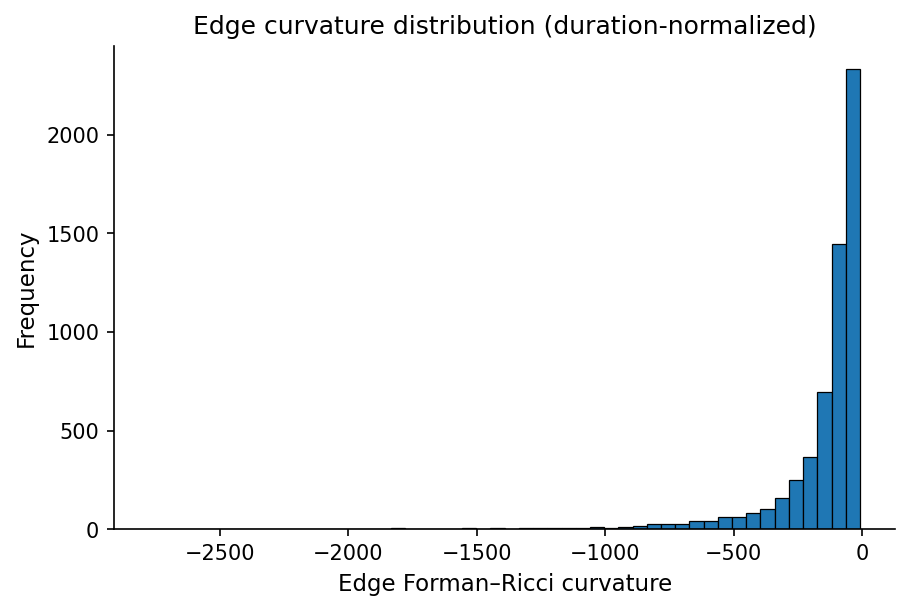

In [ ]:
# ============================================================
# 3) Curvature histogram (duration-normalized curvature)
# Use:
#  - edges_curv_dur["curvature"] if available
#  - else fallback to curv_dur dict
# ============================================================
if "curvature" in edges_curv_dur.columns:
    curv_vals = edges_curv_dur["curvature"].to_numpy(dtype=float)
else:
    curv_vals = np.array(list(curv_dur.values()), dtype=float)

plt.figure(figsize=(6.2, 4.2))
plt.hist(curv_vals, bins=50, edgecolor="black", linewidth=0.6)
plt.xlabel("Edge Forman–Ricci curvature")
plt.ylabel("Frequency")
plt.title("Edge curvature distribution (duration-normalized)")
save_fig("curvature_histogram_duration_norm")
plt.show()

Saved: figures/curvature_vs_betweenness_scatter.png
Saved: figures/curvature_vs_betweenness_scatter.pdf


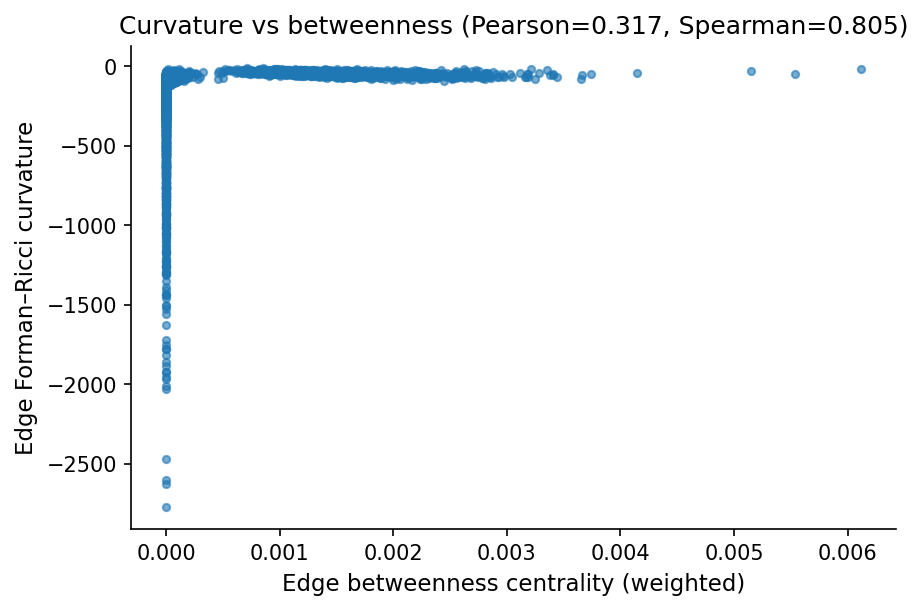

In [ ]:
# ============================================================
# 4) Curvature vs edge betweenness scatter (+ correlations)
# Requires edges_curv_dur has 'edge_betweenness'
# ============================================================
if "edge_betweenness" not in edges_curv_dur.columns:
    raise ValueError("edges_curv_dur must contain 'edge_betweenness'. Compute it before plotting.")

x = edges_curv_dur["edge_betweenness"].to_numpy(dtype=float)
y = edges_curv_dur["curvature"].to_numpy(dtype=float)

def safe_corr(a, b) -> float:
    if len(a) < 3:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])

pearson = safe_corr(x, y)

# Spearman without scipy: rank-transform then Pearson
rx = pd.Series(x).rank(method="average").to_numpy()
ry = pd.Series(y).rank(method="average").to_numpy()
spearman = safe_corr(rx, ry)

plt.figure(figsize=(6.2, 4.2))
plt.scatter(x, y, s=12, alpha=0.6)
plt.xlabel("Edge betweenness centrality (weighted)")
plt.ylabel("Edge Forman–Ricci curvature")
plt.title(f"Curvature vs betweenness (Pearson={pearson:.3f}, Spearman={spearman:.3f})")
save_fig("curvature_vs_betweenness_scatter")
plt.show()

Added edge attribute: 'w_dur_sat_norm' with c = 0.001046361255170799
Saved: figures/curvature_sir_curves_duration_norm_linear_band.png
Saved: figures/curvature_sir_curves_duration_norm_linear_band.pdf


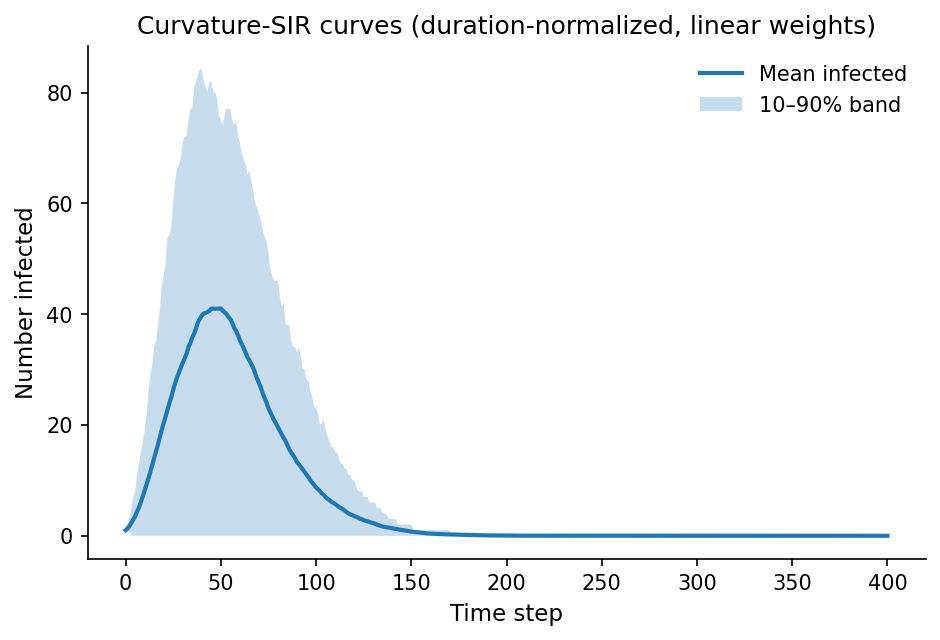

Saved: figures/curvature_sir_curves_duration_norm_saturating_band.png
Saved: figures/curvature_sir_curves_duration_norm_saturating_band.pdf


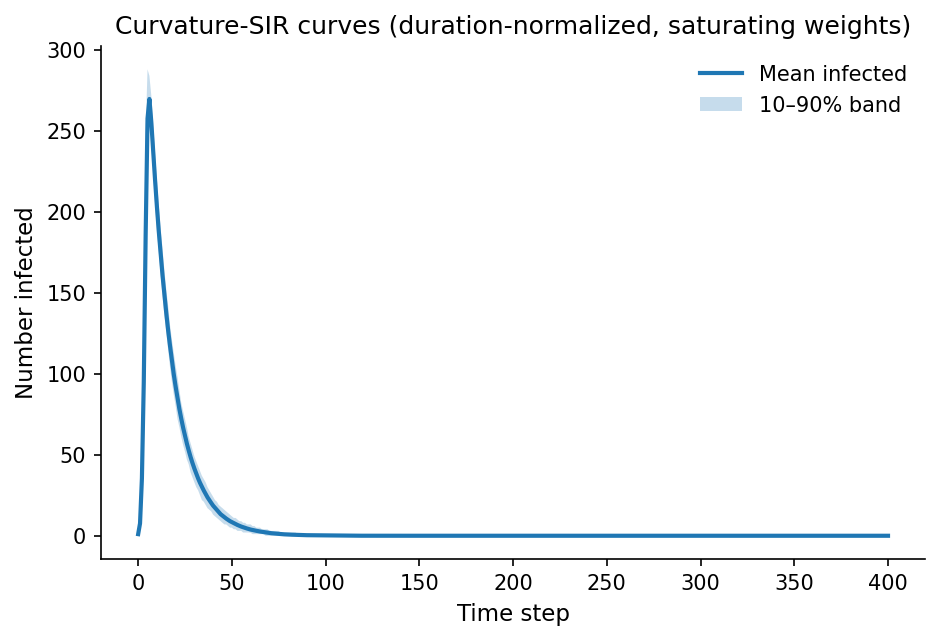

Saved: figures/curvature_sir_mean_overlay_linear_vs_saturating.png
Saved: figures/curvature_sir_mean_overlay_linear_vs_saturating.pdf


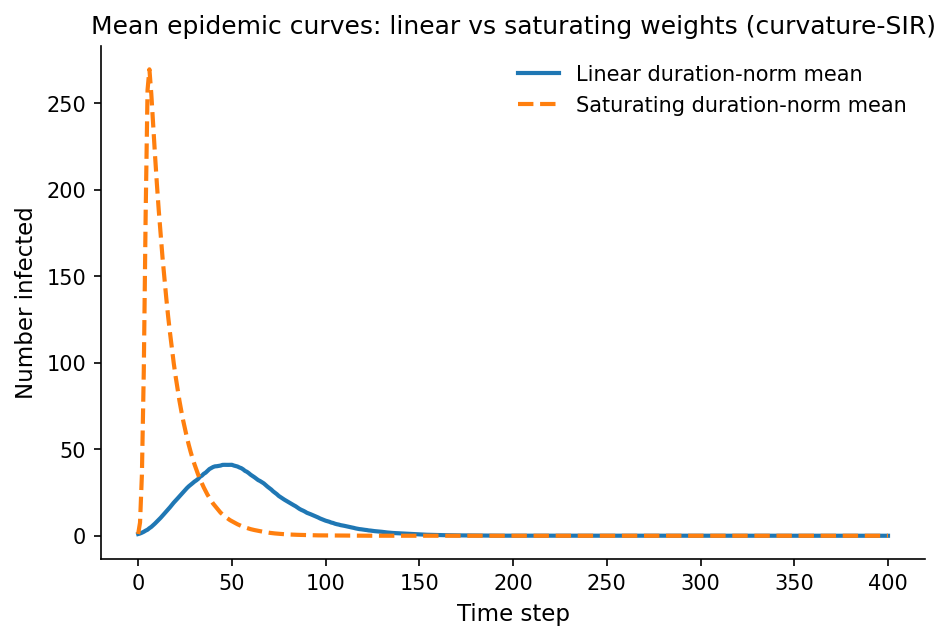

In [ ]:
# ============================================================
# 5) Epidemic curves with confidence bands (curvature-SIR) — TWEAKED
# Goal: make the "sensitivity" comparison meaningful.
#
# Reason: our previous duration-vs-count curves overlap:
#   duration_ij = 20 * count_ij  and after max-normalization => identical weights.
#
# This tweak compares:
#   (A) duration-norm linear weights  : w_dur_norm  (as before)
#   (B) duration-norm SATURATING map  : w_sat = (1 - exp(-c * duration_s)) normalized
#
# This keeps the SAME simulator and curvature law:
#   beta_ij = beta0 * exp(F(e_ij))
#   p_ij = 1 - exp(-beta_ij * w_ij)
# ============================================================

# -----------------------------
# Build a saturating-weight attribute (publishable sensitivity)
# -----------------------------
def add_saturating_weight(
    G: nx.Graph,
    source_attr: str = "duration_s",
    out_attr: str = "w_dur_sat_norm",
    c: float = 1.0,
    eps: float = 1e-12
) -> None:
    """
    Create a saturating transform of edge weight:
      w_sat = 1 - exp(-c * w_raw)
    then normalize by max so it's in (0,1].

    Parameters
    ----------
    source_attr : str
        Raw edge attribute (e.g., 'duration_s' or 'count')
    out_attr : str
        New edge attribute name
    c : float
        Saturation constant. Larger c => faster saturation.
    """
    vals = []
    for u, v, d in G.edges(data=True):
        w_raw = float(d.get(source_attr, 0.0))
        w_raw = max(w_raw, 0.0)
        w_sat = 1.0 - math.exp(-c * w_raw)
        d[out_attr] = w_sat
        vals.append(w_sat)

    mx = max(vals) if len(vals) else 1.0
    mx = max(mx, eps)
    for u, v, d in G.edges(data=True):
        d[out_attr] = float(d[out_attr]) / mx


# -----------------------------
# Optional helper: choose c automatically (robust)
# c is picked so that the 95th percentile maps to a target saturation level.
# Example: want w_sat(q95) ≈ 0.95  =>  1-exp(-c*q95)=0.95 => c = -ln(0.05)/q95
# -----------------------------
def choose_c_for_target_saturation(
    G: nx.Graph,
    source_attr: str = "duration_s",
    target_level: float = 0.95,
    quantile: float = 0.95,
    eps: float = 1e-12
) -> float:
    w = np.array([float(d.get(source_attr, 0.0)) for _, _, d in G.edges(data=True)], dtype=float)
    w = np.clip(w, 0.0, None)
    if len(w) == 0:
        return 1.0
    q = float(np.quantile(w, quantile))
    q = max(q, eps)
    target_level = min(max(target_level, eps), 1 - eps)
    c = -math.log(1 - target_level) / q
    return float(c)


# Pick c based on your data (recommended)
c_auto = choose_c_for_target_saturation(G, source_attr="duration_s", target_level=0.95, quantile=0.95)
add_saturating_weight(G, source_attr="duration_s", out_attr="w_dur_sat_norm", c=c_auto)

print("Added edge attribute: 'w_dur_sat_norm' with c =", c_auto)


# ============================================================
# Epidemic curves with confidence bands (curvature-SIR)
# Uses simulate_curvature_sir_discrete() defined earlier.
# ============================================================
def curvature_sir_ensemble_curves(
    G: nx.Graph,
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    n_runs: int = 300,
    seed0: int = 2024,
    max_steps: int = 400
) -> np.ndarray:
    """
    Returns array of shape (n_runs, T) where T=max_steps+1.
    Curves are padded with zeros after extinction.
    """
    curves = []
    for r in range(n_runs):
        res = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=seed0 + r,
            max_steps=max_steps
        )
        c = np.array(res.curve_I, dtype=float)
        if len(c) < max_steps + 1:
            c = np.pad(c, (0, max_steps + 1 - len(c)), constant_values=0.0)
        else:
            c = c[:max_steps + 1]
        curves.append(c)
    return np.vstack(curves)


def plot_epidemic_band(curves: np.ndarray, title: str, fname: str):
    t = np.arange(curves.shape[1])
    mean = curves.mean(axis=0)
    lo = np.percentile(curves, 10, axis=0)
    hi = np.percentile(curves, 90, axis=0)

    plt.figure(figsize=(6.4, 4.4))
    plt.plot(t, mean, linewidth=2.0, label="Mean infected")
    plt.fill_between(t, lo, hi, alpha=0.25, label="10–90% band")
    plt.xlabel("Time step")
    plt.ylabel("Number infected")
    plt.title(title)
    plt.legend(frameon=False)
    save_fig(fname)
    plt.show()


# ---- Use SAME parameters as your curvature-SIR runs
BETA0 = 1.2
GAMMA = 0.08

# A) Duration-normalized (linear) curves
curves_dur = curvature_sir_ensemble_curves(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_dur_norm",
    curvature_attr="formanCurvature",
    n_runs=300, seed0=2024, max_steps=400
)
plot_epidemic_band(
    curves_dur,
    title="Curvature-SIR curves (duration-normalized, linear weights)",
    fname="curvature_sir_curves_duration_norm_linear_band"
)

# B) Duration SATURATING curves (meaningful sensitivity)
curves_sat = curvature_sir_ensemble_curves(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_dur_sat_norm",
    curvature_attr="formanCurvature",
    n_runs=300, seed0=2024, max_steps=400
)
plot_epidemic_band(
    curves_sat,
    title="Curvature-SIR curves (duration-normalized, saturating weights)",
    fname="curvature_sir_curves_duration_norm_saturating_band"
)

# Optional: overlay both MEANS (paper-friendly comparison)
t = np.arange(curves_dur.shape[1])
mean_dur = curves_dur.mean(axis=0)
mean_sat = curves_sat.mean(axis=0)

plt.figure(figsize=(6.4, 4.4))
plt.plot(t, mean_dur, linewidth=2.0, label="Linear duration-norm mean")
plt.plot(t, mean_sat, linewidth=2.0, linestyle="--", label="Saturating duration-norm mean")
plt.xlabel("Time step")
plt.ylabel("Number infected")
plt.title("Mean epidemic curves: linear vs saturating weights (curvature-SIR)")
plt.legend(frameon=False)
save_fig("curvature_sir_mean_overlay_linear_vs_saturating")
plt.show()

In [ ]:
print("\nAll updated figures saved to:", FIG_DIR)


All updated figures saved to: figures


In [ ]:
# ============================================================
# EXPERIMENT 6
# EMPIRICAL HIGH-SCHOOL NETWORK VALIDATION
# ============================================================


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

E6_SEED0 = 20260907

# ------------------------------------------------------------
# Epidemic parameters
# ------------------------------------------------------------

E6_BETA0 = 1.2
E6_GAMMA = 0.08

# ------------------------------------------------------------
# Curvature-strength parameter
# ------------------------------------------------------------

E6_ALPHA_MAIN = 1.0

E6_ALPHA_GRID = np.array([
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00
])

# ------------------------------------------------------------
# Simulation settings
# ------------------------------------------------------------

E6_N_RUNS = 200
E6_MAX_STEPS = 2000

# ------------------------------------------------------------
# Primary empirical weight
# ------------------------------------------------------------

E6_WEIGHT_ATTR = "w_dur_norm"

# ------------------------------------------------------------
# Numerical safeguard
# ------------------------------------------------------------

E6_EPSILON = 1e-6

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

E6_OUTPUT_DIR = "experiment6_results"

os.makedirs(
    E6_OUTPUT_DIR,
    exist_ok=True
)

print("Experiment 6 configuration loaded.")
print("beta0 =", E6_BETA0)
print("gamma =", E6_GAMMA)
print("alpha =", E6_ALPHA_MAIN)
print("runs  =", E6_N_RUNS)
print("weight =", E6_WEIGHT_ATTR)

Experiment 6 configuration loaded.
beta0 = 1.2
gamma = 0.08
alpha = 1.0
runs  = 200
weight = w_dur_norm


In [ ]:
# ============================================================
# STEP 6.1 — VERIFY EMPIRICAL NETWORK
# ============================================================

print("Number of nodes :", G.number_of_nodes())
print("Number of edges :", G.number_of_edges())

if G.number_of_nodes() == 0:
    raise ValueError("Empirical network G contains no nodes.")

if G.number_of_edges() == 0:
    raise ValueError("Empirical network G contains no edges.")

# Check that the primary transmission weight exists
missing_weight = sum(
    1
    for _, _, d in G.edges(data=True)
    if E6_WEIGHT_ATTR not in d
)

print(
    f"Edges missing '{E6_WEIGHT_ATTR}':",
    missing_weight
)

if missing_weight > 0:
    raise ValueError(
        f"Some edges are missing the required weight attribute "
        f"'{E6_WEIGHT_ATTR}'."
    )

Number of nodes : 327
Number of edges : 5818
Edges missing 'w_dur_norm': 0


In [ ]:
# ============================================================
# STEP 6.2 — TRANSFER WEIGHTED FRC TO EMPIRICAL NETWORK
# ============================================================

if "G_frc_dur" not in globals():
    raise ValueError(
        "G_frc_dur is not available. "
        "Run the weighted Forman-Ricci curvature calculation first."
    )

for u, v, d in G.edges(data=True):

    if G_frc_dur.has_edge(u, v):

        d["formanCurvature"] = float(
            G_frc_dur[u][v].get(
                "formanCurvature",
                0.0
            )
        )

    elif G_frc_dur.has_edge(v, u):

        d["formanCurvature"] = float(
            G_frc_dur[v][u].get(
                "formanCurvature",
                0.0
            )
        )

    else:

        raise ValueError(
            f"Could not find FRC for edge ({u}, {v})."
        )

print(
    "Weighted Forman-Ricci curvature "
    "successfully transferred to G."
)

Weighted Forman-Ricci curvature successfully transferred to G.


In [ ]:
# ============================================================
# STEP 6.3 — VERIFY CURVATURE TRANSFER
# ============================================================

e6_curvature_values = np.array(
    [
        float(d["formanCurvature"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

print("Curvature summary")
print("-----------------")
print("Number of edges :", len(e6_curvature_values))
print("Minimum         :", e6_curvature_values.min())
print("Maximum         :", e6_curvature_values.max())
print("Mean            :", e6_curvature_values.mean())
print("Median          :", np.median(e6_curvature_values))
print("SD              :", e6_curvature_values.std(ddof=1))
print(
    "Non-zero edges  :",
    np.sum(e6_curvature_values != 0)
)

if np.allclose(
    e6_curvature_values,
    0.0
):
    raise ValueError(
        "All transferred curvature values are zero. "
        "FRC transfer failed."
    )

Curvature summary
-----------------
Number of edges : 5818
Minimum         : -2772.761020235241
Maximum         : -9.796184150435282
Mean            : -154.28290600754212
Median          : -81.6330535246554
SD              : 212.52337017444597
Non-zero edges  : 5818


In [ ]:
# ============================================================
# STEP 6.4 — STANDARDIZE EMPIRICAL CURVATURE
# ============================================================

e6_F_mean = np.mean(
    e6_curvature_values
)

e6_F_sd = np.std(
    e6_curvature_values,
    ddof=1
)

if e6_F_sd <= 0:
    raise ValueError(
        "Empirical curvature has zero variance."
    )

for u, v, d in G.edges(data=True):

    F = float(
        d["formanCurvature"]
    )

    d["curvature_std"] = (
        F - e6_F_mean
    ) / e6_F_sd

print(
    "Standardized curvature attached "
    "as 'curvature_std'."
)

print(
    "Mean standardized curvature:",
    np.mean([
        d["curvature_std"]
        for _, _, d in G.edges(data=True)
    ])
)

print(
    "SD standardized curvature:",
    np.std([
        d["curvature_std"]
        for _, _, d in G.edges(data=True)
    ], ddof=1)
)

Standardized curvature attached as 'curvature_std'.
Mean standardized curvature: 3.1753370797116885e-17
SD standardized curvature: 1.0


In [ ]:
# ============================================================
# STEP 6.5 — STANDARD WEIGHTED NETWORK-SIR BASELINE
# ============================================================

for u, v, d in G.edges(data=True):

    d["curvature_zero"] = 0.0

e6_network_sir = run_curvature_sir_ensemble(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="curvature_zero",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)

print("\n--- Standard weighted Network-SIR ---")
print(e6_network_sir)


--- Standard weighted Network-SIR ---
{'beta0': 1.2, 'gamma': 0.08, 'weight_attr': 'w_dur_norm', 'curvature_attr': 'curvature_zero', 'peak_I_mean': 59.68, 'peak_t_mean': 36.2, 'final_size_mean': 202.995, 'peak_I_p90': 97.0, 'final_size_p90': 288.1}


In [ ]:
# ============================================================
# STEP 6.6 — CURVATURE-SIR
# ============================================================

e6_curvature_sir = run_curvature_sir_ensemble(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="curvature_std",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)

print("\n--- Curvature-SIR ---")
print(e6_curvature_sir)


--- Curvature-SIR ---
{'beta0': 1.2, 'gamma': 0.08, 'weight_attr': 'w_dur_norm', 'curvature_attr': 'curvature_std', 'peak_I_mean': 8.7, 'peak_t_mean': 29.13, 'final_size_mean': 40.315, 'peak_I_p90': 26.0, 'final_size_p90': 146.1}


In [ ]:
# ============================================================
# STEP 6.7 — EMPIRICAL CURVATURE EFFECT
# ============================================================

e6_baseline_peak = e6_network_sir["peak_I_mean"]
e6_curvature_peak = e6_curvature_sir["peak_I_mean"]

e6_baseline_time = e6_network_sir["peak_t_mean"]
e6_curvature_time = e6_curvature_sir["peak_t_mean"]

e6_baseline_final = e6_network_sir["final_size_mean"]
e6_curvature_final = e6_curvature_sir["final_size_mean"]

e6_effects = pd.DataFrame([{

    "Network":
        "High-School",

    "Baseline_Peak":
        e6_baseline_peak,

    "Curvature_Peak":
        e6_curvature_peak,

    "Peak_Change_Pct":
        (
            (e6_curvature_peak - e6_baseline_peak)
            / e6_baseline_peak
            * 100
        ),

    "Baseline_Peak_Time":
        e6_baseline_time,

    "Curvature_Peak_Time":
        e6_curvature_time,

    "Peak_Time_Change_Pct":
        (
            (e6_curvature_time - e6_baseline_time)
            / e6_baseline_time
            * 100
        ),

    "Baseline_Final_Size":
        e6_baseline_final,

    "Curvature_Final_Size":
        e6_curvature_final,

    "Final_Size_Change_Pct":
        (
            (e6_curvature_final - e6_baseline_final)
            / e6_baseline_final
            * 100
        )

}])

e6_effects

,Network,Baseline_Peak,Curvature_Peak,Peak_Change_Pct,Baseline_Peak_Time,Curvature_Peak_Time,Peak_Time_Change_Pct,Baseline_Final_Size,Curvature_Final_Size,Final_Size_Change_Pct
0,High-School,59.68,8.7,-85.422252,36.2,29.13,-19.530387,202.995,40.315,-80.139905


In [ ]:
# ============================================================
# STEP 6.8 — UNCERTAINTY SUMMARY
# ============================================================

e6_uncertainty = pd.DataFrame([

    {
        "Model":
            "Standard weighted Network-SIR",

        "Peak_I_Mean":
            e6_network_sir["peak_I_mean"],

        "Peak_I_P90":
            e6_network_sir["peak_I_p90"],

        "Final_Size_Mean":
            e6_network_sir["final_size_mean"],

        "Final_Size_P90":
            e6_network_sir["final_size_p90"]
    },

    {
        "Model":
            "Curvature-SIR",

        "Peak_I_Mean":
            e6_curvature_sir["peak_I_mean"],

        "Peak_I_P90":
            e6_curvature_sir["peak_I_p90"],

        "Final_Size_Mean":
            e6_curvature_sir["final_size_mean"],

        "Final_Size_P90":
            e6_curvature_sir["final_size_p90"]
    }

])

e6_uncertainty

,Model,Peak_I_Mean,Peak_I_P90,Final_Size_Mean,Final_Size_P90
0,Standard weighted Network-SIR,59.68,97.0,202.995,288.1
1,Curvature-SIR,8.70,26.0,40.315,146.1


In [ ]:
# ============================================================
# STEP 6.9 — CURVATURE-TO-TRANSMISSION MAPPINGS
# ============================================================

def attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=1.0
):

    F = np.array(
        [
            float(
                d.get(source_attr, 0.0)
            )
            for _, _, d in G.edges(data=True)
        ],
        dtype=float
    )

    # --------------------------------------------------------
    # Uniform mapping
    # --------------------------------------------------------

    g_uniform = np.ones_like(F)

    # --------------------------------------------------------
    # Linear mapping
    # --------------------------------------------------------

    g_linear = np.maximum(
        E6_EPSILON,
        1.0 + alpha * F
    )

    # --------------------------------------------------------
    # Exponential mapping
    # --------------------------------------------------------

    g_exponential = np.exp(
        alpha * F
    )

    # --------------------------------------------------------
    # Saturating mapping
    # --------------------------------------------------------

    g_saturating = (
        1.0 +
        np.tanh(alpha * F)
    )

    # --------------------------------------------------------
    # Contact-weighted normalization
    #
    # The epidemic transmission kernel is
    #
    #     beta_ij = beta0 * w_ij * g_ij
    #
    # Hence we normalize using the contact-weighted
    # mean of the modifier.
    # --------------------------------------------------------

    weights = np.array(
        [
            float(
                d.get(E6_WEIGHT_ATTR, 0.0)
            )
            for _, _, d in G.edges(data=True)
        ],
        dtype=float
    )

    if np.any(weights < 0):
        raise ValueError(
            "Edge weights must be non-negative."
        )

    total_weight = np.sum(weights)

    if total_weight <= 0:
        raise ValueError(
            "Total contact weight must be positive."
        )

    def contact_weighted_normalize(
        g,
        weights
    ):
        weighted_mean = (
            np.sum(weights * g)
            / np.sum(weights)
        )

        if weighted_mean <= 0:
            raise ValueError(
                "Contact-weighted mapping mean "
                "must be positive."
            )

        return g / weighted_mean

    g_uniform = contact_weighted_normalize(
        g_uniform,
        weights
    )

    g_linear = contact_weighted_normalize(
        g_linear,
        weights
    )

    g_exponential = contact_weighted_normalize(
        g_exponential,
        weights
    )

    g_saturating = contact_weighted_normalize(
        g_saturating,
        weights
    )

    # --------------------------------------------------------
    # Store mapping values directly for diagnostics
    # --------------------------------------------------------

    for idx, (u, v, d) in enumerate(
        G.edges(data=True)
    ):

        d["mapping_uniform_value"] = (
            float(g_uniform[idx])
        )

        d["mapping_linear_value"] = (
            float(g_linear[idx])
        )

        d["mapping_exponential_value"] = (
            float(g_exponential[idx])
        )

        d["mapping_saturating_value"] = (
            float(g_saturating[idx])
        )

        # ----------------------------------------------------
        # Existing simulator applies exp(kappa)
        # Therefore store log(mapping)
        # ----------------------------------------------------

        d["mapping_uniform"] = 0.0

        d["mapping_linear"] = math.log(
            max(
                g_linear[idx],
                E6_EPSILON
            )
        )

        d["mapping_exponential"] = math.log(
            max(
                g_exponential[idx],
                E6_EPSILON
            )
        )

        d["mapping_saturating"] = math.log(
            max(
                g_saturating[idx],
                E6_EPSILON
            )
        )

    return G

In [ ]:
# ============================================================
# STEP 6.10 — ATTACH AND VERIFY MAPPINGS
# ============================================================

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=E6_ALPHA_MAIN
)

mapping_columns = [
    "mapping_uniform_value",
    "mapping_linear_value",
    "mapping_exponential_value",
    "mapping_saturating_value"
]

mapping_summary = []

for col in mapping_columns:

    values = np.array([
        float(d[col])
        for _, _, d in G.edges(data=True)
    ])

    mapping_summary.append({

        "Mapping":
            col,

        "Mean":
            values.mean(),

        "SD":
            values.std(ddof=1),

        "Min":
            values.min(),

        "Max":
            values.max(),

        "Unique_Values":
            len(np.unique(values))

    })

e6_mapping_check = pd.DataFrame(
    mapping_summary
)

e6_mapping_check

,Mapping,Mean,SD,Min,Max,Unique_Values
0,mapping_uniform_value,1.000000,0.000000,1.000000e+00,1.000000,1
1,mapping_linear_value,6.139092,2.656484,5.401281e-06,9.073410,5294
2,mapping_exponential_value,4.668532,1.874858,1.672184e-05,7.403575,5818
3,mapping_saturating_value,5.272055,2.110508,1.854866e-10,7.427864,5818


In [ ]:
# ============================================================
# STEP 6.10A — VERIFY CONTACT-WEIGHTED EXPONENTIAL MAPPING
# ============================================================

# The exponential curvature modifier used in the epidemic
# simulation must have contact-weighted mean equal to one
# at the main curvature strength.
#
# This is required because transmission is proportional to
#
#     beta_ij = beta0 * w_ij * g_ij
#
# where w_ij is the empirical contact weight.

exponential_mapping_values = np.array(
    [
        float(d["mapping_exponential_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

contact_weights = np.array(
    [
        float(d[E6_WEIGHT_ATTR])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

# ------------------------------------------------------------
# Compute both means for diagnostic purposes
# ------------------------------------------------------------

exponential_mapping_mean = (
    exponential_mapping_values.mean()
)

exponential_mapping_weighted_mean = np.average(
    exponential_mapping_values,
    weights=contact_weights
)

print(
    "CONTACT-WEIGHTED EXPONENTIAL MAPPING CHECK"
)

print("=" * 60)

print(
    f"Alpha                         : "
    f"{E6_ALPHA_MAIN:.2f}"
)

print(
    f"Unweighted mean modifier      : "
    f"{exponential_mapping_mean:.12f}"
)

print(
    f"Contact-weighted mean modifier: "
    f"{exponential_mapping_weighted_mean:.12f}"
)

print(
    f"Minimum modifier              : "
    f"{exponential_mapping_values.min():.6f}"
)

print(
    f"Maximum modifier              : "
    f"{exponential_mapping_values.max():.6f}"
)

# ------------------------------------------------------------
# The contact-weighted mean must equal one
# ------------------------------------------------------------

if not np.isclose(
    exponential_mapping_weighted_mean,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Contact-weighted exponential mapping "
        "does not have weighted mean equal to one."
    )

print(
    "✓ Contact-weighted exponential mapping "
    "verified."
)

CONTACT-WEIGHTED EXPONENTIAL MAPPING CHECK
Alpha                         : 1.00
Unweighted mean modifier      : 4.668531782334
Contact-weighted mean modifier: 1.000000000000
Minimum modifier              : 0.000017
Maximum modifier              : 7.403575
✓ Contact-weighted exponential mapping verified.


In [ ]:
# ============================================================
# FUNCTION — EXTENDED SIR ENSEMBLE
# Canonical ensemble function for all model conditions
# ============================================================

import random


def run_curvature_sir_ensemble_extended(
    G,
    beta0,
    gamma,
    weight_attr,
    curvature_attr="formanCurvature",
    n_runs=200,
    seed0=123,
    max_steps=2000
):
    """
    Run a stochastic ensemble of network-based SIR simulations.

    Each replicate uses the deterministic seed:

        seed = seed0 + run

    The function records:
        - Run_ID
        - Seed
        - Initial_Infected
        - Peak_Infected
        - Peak_Time
        - Final_Size
        - Duration
        - Hit_Max_Steps

    The initial infected node is reconstructed from the same seed
    used by simulate_curvature_sir_discrete(). This records the
    initial condition without changing the simulator's random-number
    sequence.

    Because all model conditions use the same seed sequence on the
    same graph, Run_ID, Seed, and Initial_Infected can be used to
    verify paired replicate structure.
    """

    # --------------------------------------------------------
    # Storage containers
    # --------------------------------------------------------

    run_ids = []
    run_seeds = []
    initial_infected_nodes = []

    peak_I = []
    peak_t = []
    final_size = []
    duration = []
    hit_max_steps = []

    infected_curves = []

    # --------------------------------------------------------
    # Node ordering used by the simulator
    # --------------------------------------------------------

    nodes = list(G.nodes())

    if len(nodes) == 0:
        raise ValueError(
            "The supplied graph contains no nodes."
        )

    # --------------------------------------------------------
    # Run stochastic ensemble
    # --------------------------------------------------------

    for run in range(n_runs):

        # Explicit replicate identifier
        run_id = run + 1

        # Deterministic replicate seed
        run_seed = seed0 + run

        # ----------------------------------------------------
        # Reconstruct the initial infected node
        #
        # IMPORTANT:
        # This does NOT alter the simulator's RNG.
        #
        # simulate_curvature_sir_discrete() creates its own
        # random.Random(seed), so this separate RNG reproduces
        # the same initial node that the simulator selects.
        # ----------------------------------------------------

        rng_check = random.Random(
            run_seed
        )

        initial_node = rng_check.choice(
            nodes
        )

        # Store pairing metadata
        run_ids.append(
            run_id
        )

        run_seeds.append(
            run_seed
        )

        initial_infected_nodes.append(
            initial_node
        )

        # ----------------------------------------------------
        # Run simulation
        # ----------------------------------------------------

        result = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=run_seed,
            max_steps=max_steps
        )

        # ----------------------------------------------------
        # Epidemiological outcomes
        # ----------------------------------------------------

        peak_I.append(
            float(
                result.peak_infected
            )
        )

        peak_t.append(
            float(
                result.peak_time
            )
        )

        final_size.append(
            float(
                result.final_size
            )
        )

        # ----------------------------------------------------
        # Epidemic curve
        # ----------------------------------------------------

        curve_I = np.asarray(
            result.curve_I,
            dtype=float
        )

        infected_curves.append(
            curve_I
        )

        # ----------------------------------------------------
        # Epidemic duration
        # ----------------------------------------------------

        run_duration = (
            len(curve_I) - 1
        )

        duration.append(
            run_duration
        )

        # ----------------------------------------------------
        # Maximum-step truncation diagnostic
        # ----------------------------------------------------

        truncated = (
            run_duration >= max_steps
            and curve_I[-1] > 0
        )

        hit_max_steps.append(
            truncated
        )

    # --------------------------------------------------------
    # Pad epidemic curves
    # --------------------------------------------------------

    max_len = max(
        len(curve)
        for curve in infected_curves
    )

    padded_curves = np.full(
        (n_runs, max_len),
        np.nan,
        dtype=float
    )

    for i, curve in enumerate(
        infected_curves
    ):

        padded_curves[
            i,
            :len(curve)
        ] = curve

    # --------------------------------------------------------
    # Run-level metrics
    # --------------------------------------------------------

    metrics = pd.DataFrame({

        "Run_ID":
            run_ids,

        "Seed":
            run_seeds,

        "Initial_Infected":
            initial_infected_nodes,

        "Peak_Infected":
            peak_I,

        "Peak_Time":
            peak_t,

        "Final_Size":
            final_size,

        "Duration":
            duration,

        "Hit_Max_Steps":
            hit_max_steps
    })

    # --------------------------------------------------------
    # Return ensemble results
    # --------------------------------------------------------

    return {

        "metrics":
            metrics,

        "infected_curves":
            padded_curves,

        "beta0":
            beta0,

        "gamma":
            gamma,

        "weight_attr":
            weight_attr,

        "curvature_attr":
            curvature_attr,

        # Convenient top-level access
        "Hit_Max_Steps":
            hit_max_steps,

        "Run_ID":
            run_ids,

        "Seed":
            run_seeds,

        "Initial_Infected":
            initial_infected_nodes
    }

In [ ]:
# ============================================================
# VERIFY EXTENDED ENSEMBLE FUNCTION
# ============================================================

print(
    "run_curvature_sir_ensemble_extended"
    in globals()
)

print(
    run_curvature_sir_ensemble_extended
)

True
<function run_curvature_sir_ensemble_extended at 0x782429441f80>


In [ ]:
# ============================================================
# FUNCTION — STATISTICAL SUMMARY
# ============================================================

def summarize_metric(values):

    values = np.asarray(
        values,
        dtype=float
    )

    # Remove missing/infinite values
    values = values[
        np.isfinite(values)
    ]

    n = len(values)

    if n == 0:
        raise ValueError(
            "No valid observations were provided."
        )

    # --------------------------------------------------------
    # Mean
    # --------------------------------------------------------

    mean = np.mean(values)

    # --------------------------------------------------------
    # Standard deviation
    # --------------------------------------------------------

    sd = (
        np.std(
            values,
            ddof=1
        )
        if n > 1
        else 0.0
    )

    # --------------------------------------------------------
    # Median and IQR
    # --------------------------------------------------------

    median = np.median(
        values
    )

    q25, q75 = np.percentile(
        values,
        [25, 75]
    )

    # --------------------------------------------------------
    # 95% confidence interval for the mean
    #
    # Use the t distribution rather than the normal
    # approximation because this is the appropriate
    # finite-sample CI calculation.
    # --------------------------------------------------------

    if n > 1:

        t_critical = scipy_stats.t.ppf(
            0.975,
            df=n - 1
        )

        se = (
            sd /
            np.sqrt(n)
        )

        ci_lower = (
            mean -
            t_critical * se
        )

        ci_upper = (
            mean +
            t_critical * se
        )

    else:

        ci_lower = mean
        ci_upper = mean

    # --------------------------------------------------------
    # Return summary
    # --------------------------------------------------------

    return {

        "N":
            n,

        "Mean":
            mean,

        "SD":
            sd,

        "CI95_Lower":
            ci_lower,

        "CI95_Upper":
            ci_upper,

        "Median":
            median,

        "IQR_Lower":
            q25,

        "IQR_Upper":
            q75
    }

In [ ]:
print(
    "summarize_metric" in globals()
)

print(
    summarize_metric
)

True
<function summarize_metric at 0x782429443b00>


In [ ]:
test_values = np.array([
    1, 2, 3, 4, 5
])

test_summary = summarize_metric(
    test_values
)

test_summary

{'N': 5,
 'Mean': np.float64(3.0),
 'SD': np.float64(1.5811388300841898),
 'CI95_Lower': np.float64(1.036756838522439),
 'CI95_Upper': np.float64(4.9632431614775605),
 'Median': np.float64(3.0),
 'IQR_Lower': np.float64(2.0),
 'IQR_Upper': np.float64(4.0)}

In [ ]:
#STEP 6.10B — Verify Transmission-Scale Preservation

# ============================================================
# FINAL TRANSMISSION-KERNEL CONSISTENCY CHECK
# ============================================================

uniform_total = 0.0
exponential_total = 0.0

for _, _, d in G.edges(data=True):

    # Contact weight used by the epidemic simulator.
    w = float(d[E6_WEIGHT_ATTR])

    # Uniform model has modifier equal to one.
    uniform_total += w

    # IMPORTANT:
    # Reconstruct the modifier exactly as the simulator does.
    # The stored attribute contains log(g), so exp(...) gives
    # the normalized multiplicative transmission modifier.
    g_exp = np.exp(
        float(d["mapping_exponential"])
    )

    exponential_total += w * g_exp


print("TRANSMISSION-KERNEL CONSISTENCY CHECK")
print("=" * 60)

print(
    f"Uniform weighted total     : "
    f"{uniform_total:.12f}"
)

print(
    f"Exponential weighted total : "
    f"{exponential_total:.12f}"
)

print(
    f"Ratio (Exp / Uniform)      : "
    f"{exponential_total / uniform_total:.12f}"
)

if not np.isclose(
    exponential_total,
    uniform_total,
    rtol=1e-10,
    atol=1e-12
):
    raise RuntimeError(
        "The actual exponential transmission kernel "
        "does not preserve the uniform weighted total."
    )

print(
    "✓ Actual epidemic transmission kernel "
    "preserves the weighted transmission scale."
)

TRANSMISSION-KERNEL CONSISTENCY CHECK
Uniform weighted total     : 63.922685656156
Exponential weighted total : 63.922685656155
Ratio (Exp / Uniform)      : 1.000000000000
✓ Actual epidemic transmission kernel preserves the weighted transmission scale.


In [ ]:
# ============================================================
# STEP 6.11 — EXPERIMENT 6B
# MAPPING ROBUSTNESS
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
# Rebuild all mapping attributes explicitly at the main
# curvature strength before running the comparison.
#
# This prevents STEP 6.13 (alpha sensitivity) from leaving
# G with mappings corresponding to the final alpha value.
# ------------------------------------------------------------

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=float(E6_ALPHA_MAIN)
)


E6_MAPPINGS = {
    "Uniform":
        "mapping_uniform",

    "Linear":
        "mapping_linear",

    "Exponential":
        "mapping_exponential",

    "Saturating":
        "mapping_saturating"
}


e6_mapping_results = []


for mapping_name, curvature_attr in E6_MAPPINGS.items():

    print(
        f"\nRunning mapping: {mapping_name}"
    )

    output = run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr=curvature_attr,
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )

    metrics = output["metrics"]

    # --------------------------------------------------------
    # Check that no runs were truncated
    # --------------------------------------------------------

    n_truncated = int(
        metrics["Hit_Max_Steps"].sum()
    )

    if n_truncated > 0:
        raise RuntimeError(
            f"{mapping_name} mapping has "
            f"{n_truncated} truncated runs."
        )

    # --------------------------------------------------------
    # Summarize the four epidemiological outcomes
    # --------------------------------------------------------

    peak_summary = summarize_metric(
        metrics["Peak_Infected"]
    )

    peak_time_summary = summarize_metric(
        metrics["Peak_Time"]
    )

    final_size_summary = summarize_metric(
        metrics["Final_Size"]
    )

    duration_summary = summarize_metric(
        metrics["Duration"]
    )

    e6_mapping_results.append({

        "Network":
            "High-School",

        "Mapping":
            mapping_name,

        "Alpha":
            float(E6_ALPHA_MAIN),

        # Peak infected
        "Peak_Infected_Mean":
            peak_summary["Mean"],

        "Peak_Infected_SD":
            peak_summary["SD"],

        "Peak_Infected_CI95_Lower":
            peak_summary["CI95_Lower"],

        "Peak_Infected_CI95_Upper":
            peak_summary["CI95_Upper"],

        # Peak time
        "Peak_Time_Mean":
            peak_time_summary["Mean"],

        "Peak_Time_SD":
            peak_time_summary["SD"],

        "Peak_Time_CI95_Lower":
            peak_time_summary["CI95_Lower"],

        "Peak_Time_CI95_Upper":
            peak_time_summary["CI95_Upper"],

        # Final size
        "Final_Size_Mean":
            final_size_summary["Mean"],

        "Final_Size_SD":
            final_size_summary["SD"],

        "Final_Size_CI95_Lower":
            final_size_summary["CI95_Lower"],

        "Final_Size_CI95_Upper":
            final_size_summary["CI95_Upper"],

        # Duration
        "Duration_Mean":
            duration_summary["Mean"],

        "Duration_SD":
            duration_summary["SD"],

        "Duration_CI95_Lower":
            duration_summary["CI95_Lower"],

        "Duration_CI95_Upper":
            duration_summary["CI95_Upper"],

        # Distributional summaries
        "Peak_Infected_Median":
            peak_summary["Median"],

        "Peak_Infected_IQR_Lower":
            peak_summary["IQR_Lower"],

        "Peak_Infected_IQR_Upper":
            peak_summary["IQR_Upper"],

        "Final_Size_Median":
            final_size_summary["Median"],

        "Final_Size_IQR_Lower":
            final_size_summary["IQR_Lower"],

        "Final_Size_IQR_Upper":
            final_size_summary["IQR_Upper"],

        "Duration_Median":
            duration_summary["Median"],

        "Duration_IQR_Lower":
            duration_summary["IQR_Lower"],

        "Duration_IQR_Upper":
            duration_summary["IQR_Upper"],

        "N":
            peak_summary["N"]
    })


e6_mapping_df = pd.DataFrame(
    e6_mapping_results
)

e6_mapping_df


Running mapping: Uniform

Running mapping: Linear

Running mapping: Exponential

Running mapping: Saturating


,Network,Mapping,Alpha,Peak_Infected_Mean,Peak_Infected_SD,Peak_Infected_CI95_Lower,Peak_Infected_CI95_Upper,Peak_Time_Mean,Peak_Time_SD,Peak_Time_CI95_Lower,...,Peak_Infected_Median,Peak_Infected_IQR_Lower,Peak_Infected_IQR_Upper,Final_Size_Median,Final_Size_IQR_Lower,Final_Size_IQR_Upper,Duration_Median,Duration_IQR_Lower,Duration_IQR_Upper,N
0,High-School,Uniform,1.0,59.680,37.270404,54.483075,64.876925,36.200,24.990450,32.715372,...,73.0,11.75,87.0,274.0,26.25,282.0,119.5,61.5,144.0,200
1,High-School,Linear,1.0,125.270,50.892705,118.173603,132.366397,26.385,11.707781,24.752486,...,144.0,128.00,153.0,318.0,316.00,321.0,103.5,90.0,117.0,200
2,High-School,Exponential,1.0,119.955,51.215212,112.813634,127.096366,27.095,12.636232,25.333024,...,137.0,121.75,148.0,317.0,314.00,319.0,105.0,91.0,117.0,200
3,High-School,Saturating,1.0,123.720,49.554920,116.810142,130.629858,26.795,11.339573,25.213828,...,139.0,125.00,151.0,318.0,315.00,320.0,103.0,91.0,116.0,200


In [ ]:
# ============================================================
# STEP 6.11A — VERIFY MAPPING EXPERIMENT STATE
# ============================================================

print("MAPPING EXPERIMENT STATE CHECK")
print("=" * 50)

print(
    f"Configured main alpha: {E6_ALPHA_MAIN}"
)

print(
    f"Reported mapping alpha: "
    f"{e6_mapping_df['Alpha'].unique()}"
)

if not np.allclose(
    e6_mapping_df["Alpha"].to_numpy(dtype=float),
    float(E6_ALPHA_MAIN)
):
    raise RuntimeError(
        "Mapping results do not correspond to E6_ALPHA_MAIN."
    )

print(
    "✓ All mapping results are labelled with E6_ALPHA_MAIN."
)

MAPPING EXPERIMENT STATE CHECK
Configured main alpha: 1.0
Reported mapping alpha: [1.]
✓ All mapping results are labelled with E6_ALPHA_MAIN.


In [ ]:
mapping_state_check = {}

for mapping_name, curvature_attr in E6_MAPPINGS.items():

    values = np.array([
        float(d.get(curvature_attr, np.nan))
        for _, _, d in G.edges(data=True)
    ])

    mapping_state_check[mapping_name] = {
        "Mean_log_mapping": np.mean(values),
        "SD_log_mapping": np.std(values, ddof=1),
        "Min_log_mapping": np.min(values),
        "Max_log_mapping": np.max(values)
    }

pd.DataFrame(mapping_state_check).T

,Mean_log_mapping,SD_log_mapping,Min_log_mapping,Max_log_mapping
Uniform,0.000000,0.000000,0.000000,0.000000
Linear,0.569769,4.029085,-12.128874,2.205348
Exponential,1.322100,1.000000,-10.998795,2.001963
Saturating,1.297965,1.614862,-13.815511,2.005238


In [ ]:
# ============================================================
# STEP 6.12 — RELATIVE MAPPING EFFECTS
# ============================================================

e6_uniform = (
    e6_mapping_df[
        e6_mapping_df["Mapping"] == "Uniform"
    ]
    .iloc[0]
)

e6_mapping_effects = e6_mapping_df.copy()

e6_mapping_effects[
    "Peak_Change_Pct"
] = (
    (
        e6_mapping_effects["Peak_Infected_Mean"]
        - e6_uniform["Peak_Infected_Mean"]
    )
    /
    e6_uniform["Peak_Infected_Mean"]
    * 100
)

e6_mapping_effects[
    "Peak_Time_Change_Pct"
] = (
    (
        e6_mapping_effects["Peak_Time_Mean"]
        - e6_uniform["Peak_Time_Mean"]
    )
    /
    e6_uniform["Peak_Time_Mean"]
    * 100
)

e6_mapping_effects[
    "Final_Size_Change_Pct"
] = (
    (
        e6_mapping_effects["Final_Size_Mean"]
        - e6_uniform["Final_Size_Mean"]
    )
    /
    e6_uniform["Final_Size_Mean"]
    * 100
)

e6_mapping_effects

,Network,Mapping,Alpha,Peak_Infected_Mean,Peak_Infected_SD,Peak_Infected_CI95_Lower,Peak_Infected_CI95_Upper,Peak_Time_Mean,Peak_Time_SD,Peak_Time_CI95_Lower,...,Final_Size_Median,Final_Size_IQR_Lower,Final_Size_IQR_Upper,Duration_Median,Duration_IQR_Lower,Duration_IQR_Upper,N,Peak_Change_Pct,Peak_Time_Change_Pct,Final_Size_Change_Pct
0,High-School,Uniform,1.0,59.680,37.270404,54.483075,64.876925,36.200,24.990450,32.715372,...,274.0,26.25,282.0,119.5,61.5,144.0,200,0.000000,0.000000,0.000000
1,High-School,Linear,1.0,125.270,50.892705,118.173603,132.366397,26.385,11.707781,24.752486,...,318.0,316.00,321.0,103.5,90.0,117.0,200,109.902815,-27.113260,35.991034
2,High-School,Exponential,1.0,119.955,51.215212,112.813634,127.096366,27.095,12.636232,25.333024,...,317.0,314.00,319.0,105.0,91.0,117.0,200,100.996984,-25.151934,33.924481
3,High-School,Saturating,1.0,123.720,49.554920,116.810142,130.629858,26.795,11.339573,25.213828,...,318.0,315.00,320.0,103.0,91.0,116.0,200,107.305630,-25.980663,36.476268


In [ ]:
# ============================================================
# STEP 6D.2
# SUMMARY STATISTICS
# ============================================================

# ============================================================
# STATISTICAL SUMMARY HELPER
# Mean, SD, Median, IQR, and 95% CI
# ============================================================


def summarize_metric(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    n = len(values)

    if n == 0:
        raise ValueError("No valid observations were provided.")

    mean = np.mean(values)

    sd = np.std(values, ddof=1) if n > 1 else 0.0

    median = np.median(values)

    q25, q75 = np.percentile(values, [25, 75])

    if n > 1:
        t_critical = scipy_stats.t.ppf(0.975, df=n - 1)
        se = sd / np.sqrt(n)

        ci_lower = mean - t_critical * se
        ci_upper = mean + t_critical * se
    else:
        ci_lower = mean
        ci_upper = mean

    return {
        "N": n,
        "Mean": mean,
        "SD": sd,
        "CI95_Lower": ci_lower,
        "CI95_Upper": ci_upper,
        "Median": median,
        "IQR_Lower": q25,
        "IQR_Upper": q75
    }

In [ ]:
# ============================================================
# STEP 6D.3
# BASELINE VS CURVATURE ENSEMBLES
# ============================================================

# ------------------------------------------------------------
# Rebuild the curvature-to-transmission mappings explicitly
# at the principal curvature strength.
#
# The curvature-aware model uses the contact-weighted
# normalized exponential mapping.
#
# For the empirical weighted network:
#
#     beta_ij = beta0 * w_ij * g_ij
#
# Therefore, normalization is performed using
# the contact-weighted mean of g:
#
#     sum(w_ij * g_ij) / sum(w_ij) = 1
#
# The ordinary/unweighted edge mean is NOT required to
# equal one.
# ------------------------------------------------------------

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=float(E6_ALPHA_MAIN)
)

# ------------------------------------------------------------
# Verify the contact-weighted exponential modifier.
# ------------------------------------------------------------

exponential_mapping_values = np.array(
    [
        float(
            d["mapping_exponential_value"]
        )
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

contact_weights = np.array(
    [
        float(
            d[E6_WEIGHT_ATTR]
        )
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

# Ordinary edge mean — diagnostic only.
# It is NOT required to equal one.
exponential_mapping_mean = (
    exponential_mapping_values.mean()
)

# Contact-weighted mean — this MUST equal one.
exponential_mapping_weighted_mean = np.average(
    exponential_mapping_values,
    weights=contact_weights
)

print(
    "CONTACT-WEIGHTED EXPONENTIAL MAPPING CHECK"
)

print("=" * 60)

print(
    f"Alpha                         : "
    f"{E6_ALPHA_MAIN:.2f}"
)

print(
    f"Unweighted mean modifier      : "
    f"{exponential_mapping_mean:.12f}"
)

print(
    f"Contact-weighted mean modifier: "
    f"{exponential_mapping_weighted_mean:.12f}"
)

print(
    f"Minimum modifier              : "
    f"{exponential_mapping_values.min():.6f}"
)

print(
    f"Maximum modifier              : "
    f"{exponential_mapping_values.max():.6f}"
)

if not np.isclose(
    exponential_mapping_weighted_mean,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Contact-weighted exponential mapping "
        "does not have weighted mean equal to one."
    )

print(
    "✓ Contact-weighted exponential mapping "
    "verified."
)


# ------------------------------------------------------------
# Weighted Network-SIR baseline
#
# curvature_zero = 0
#
# Therefore:
#
#     beta_ij = beta0 * w_ij
# ------------------------------------------------------------

baseline_runs = run_curvature_sir_ensemble_extended(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="curvature_zero",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)


# ------------------------------------------------------------
# Curvature-SIR
#
# mapping_exponential stores the LOG of the already
# contact-weight-normalized exponential modifier:
#
#     log(
#         exp(alpha * F_tilde)
#         /
#         contact_weighted_mean(
#             exp(alpha * F_tilde)
#         )
#     )
#
# The existing simulator exponentiates this value,
# recovering the normalized modifier.
# ------------------------------------------------------------

curvature_runs = run_curvature_sir_ensemble_extended(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="mapping_exponential",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)


# ------------------------------------------------------------
# Report ensemble sizes
# ------------------------------------------------------------

print(
    "Baseline runs:",
    len(baseline_runs["metrics"])
)

print(
    "Curvature runs:",
    len(curvature_runs["metrics"])
)

print()
print("Configuration:")
print("Beta0      :", E6_BETA0)
print("Gamma      :", E6_GAMMA)
print("Weight     :", E6_WEIGHT_ATTR)
print("Alpha      :", E6_ALPHA_MAIN)
print("N runs     :", E6_N_RUNS)
print("Seed       :", E6_SEED0)
print("Max steps  :", E6_MAX_STEPS)

print(
    "Curvature mapping : "
    "contact-weighted normalized exponential"
)

# ------------------------------------------------------------
# Verify paired replicate structure
# ------------------------------------------------------------

required_pair_columns = [
    "Run_ID",
    "Seed"
]

for col in required_pair_columns:

    if col not in baseline_runs["metrics"].columns:
        raise RuntimeError(
            f"Baseline ensemble is missing required pairing column: {col}"
        )

    if col not in curvature_runs["metrics"].columns:
        raise RuntimeError(
            f"Curvature ensemble is missing required pairing column: {col}"
        )

    if not np.array_equal(
        baseline_runs["metrics"][col].to_numpy(),
        curvature_runs["metrics"][col].to_numpy()
    ):
        raise RuntimeError(
            f"Baseline and Curvature-SIR {col} values are not aligned."
        )

if (
    "Initial_Infected" in baseline_runs["metrics"].columns
    and
    "Initial_Infected" in curvature_runs["metrics"].columns
):

    if not np.array_equal(
        baseline_runs["metrics"]["Initial_Infected"].to_numpy(),
        curvature_runs["metrics"]["Initial_Infected"].to_numpy()
    ):
        raise RuntimeError(
            "Baseline and Curvature-SIR initial infected nodes "
            "are not aligned."
        )

    print("✓ Run_ID, Seed, and Initial_Infected are aligned.")

else:

    print("✓ Run_ID and Seed are aligned.")
    print(
        "⚠ Initial_Infected alignment will be checked after "
        "the revised Cell 30 is executed."
    )


CONTACT-WEIGHTED EXPONENTIAL MAPPING CHECK
Alpha                         : 1.00
Unweighted mean modifier      : 4.668531782334
Contact-weighted mean modifier: 1.000000000000
Minimum modifier              : 0.000017
Maximum modifier              : 7.403575
✓ Contact-weighted exponential mapping verified.
Baseline runs: 200
Curvature runs: 200

Configuration:
Beta0      : 1.2
Gamma      : 0.08
Weight     : w_dur_norm
Alpha      : 1.0
N runs     : 200
Seed       : 20260907
Max steps  : 2000
Curvature mapping : contact-weighted normalized exponential
✓ Run_ID, Seed, and Initial_Infected are aligned.


In [ ]:
print("MAX-STEP TRUNCATION DIAGNOSTIC")
print("=" * 50)

baseline_hit_max = np.sum(
    baseline_runs["metrics"]["Hit_Max_Steps"]
)

curvature_hit_max = np.sum(
    curvature_runs["metrics"]["Hit_Max_Steps"]
)

print(
    f"Baseline runs hitting max_steps: "
    f"{baseline_hit_max} / {len(baseline_runs['metrics'])}"
)

print(
    f"Curvature-SIR runs hitting max_steps: "
    f"{curvature_hit_max} / {len(curvature_runs['metrics'])}"
)

print()

print(
    f"Baseline maximum duration: "
    f"{baseline_runs['metrics']['Duration'].max()} steps"
)

print(
    f"Curvature-SIR maximum duration: "
    f"{curvature_runs['metrics']['Duration'].max()} steps"
)

print()

if baseline_hit_max == 0 and curvature_hit_max == 0:
    print("✓ All runs terminated naturally before max_steps.")
    print("✓ Duration can be interpreted as time to epidemic extinction.")
    print("✓ Final size represents the total number infected during the run.")
else:
    print("⚠ Some runs were truncated at max_steps.")
    print("⚠ Duration is censored for those runs.")
    print("⚠ Final size is not necessarily the eventual final epidemic size.")

MAX-STEP TRUNCATION DIAGNOSTIC
Baseline runs hitting max_steps: 0 / 200
Curvature-SIR runs hitting max_steps: 0 / 200

Baseline maximum duration: 240 steps
Curvature-SIR maximum duration: 182 steps

✓ All runs terminated naturally before max_steps.
✓ Duration can be interpreted as time to epidemic extinction.
✓ Final size represents the total number infected during the run.


In [ ]:
baseline_n = len(baseline_runs["metrics"])
curvature_n = len(curvature_runs["metrics"])

baseline_pct = 100 * baseline_hit_max / baseline_n
curvature_pct = 100 * curvature_hit_max / curvature_n

print(
    f"Baseline truncation rate: {baseline_pct:.2f}%"
)

print(
    f"Curvature-SIR truncation rate: {curvature_pct:.2f}%"
)

Baseline truncation rate: 0.00%
Curvature-SIR truncation rate: 0.00%


In [ ]:
baseline_remaining_I = np.array([
    curve[~np.isnan(curve)][-1]
    for curve in baseline_runs["infected_curves"]
])

curvature_remaining_I = np.array([
    curve[~np.isnan(curve)][-1]
    for curve in curvature_runs["infected_curves"]
])

print("FINAL INFECTED COUNT DIAGNOSTIC")
print("=" * 50)

print(
    f"Baseline maximum final I: "
    f"{baseline_remaining_I.max():.0f}"
)

print(
    f"Curvature-SIR maximum final I: "
    f"{curvature_remaining_I.max():.0f}"
)

FINAL INFECTED COUNT DIAGNOSTIC
Baseline maximum final I: 0
Curvature-SIR maximum final I: 0


In [ ]:
print("EPIDEMIC DURATION SUMMARY")
print("=" * 50)

baseline_duration = baseline_runs["metrics"]["Duration"].to_numpy(dtype=float)
curvature_duration = curvature_runs["metrics"]["Duration"].to_numpy(dtype=float)

print(
    f"Baseline:      "
    f"Mean = {baseline_duration.mean():.2f}, "
    f"SD = {baseline_duration.std(ddof=1):.2f}, "
    f"Median = {np.median(baseline_duration):.2f}"
)

print(
    f"Curvature-SIR: "
    f"Mean = {curvature_duration.mean():.2f}, "
    f"SD = {curvature_duration.std(ddof=1):.2f}, "
    f"Median = {np.median(curvature_duration):.2f}"
)

EPIDEMIC DURATION SUMMARY
Baseline:      Mean = 102.50, SD = 59.45, Median = 119.50
Curvature-SIR: Mean = 94.64, SD = 40.47, Median = 105.00


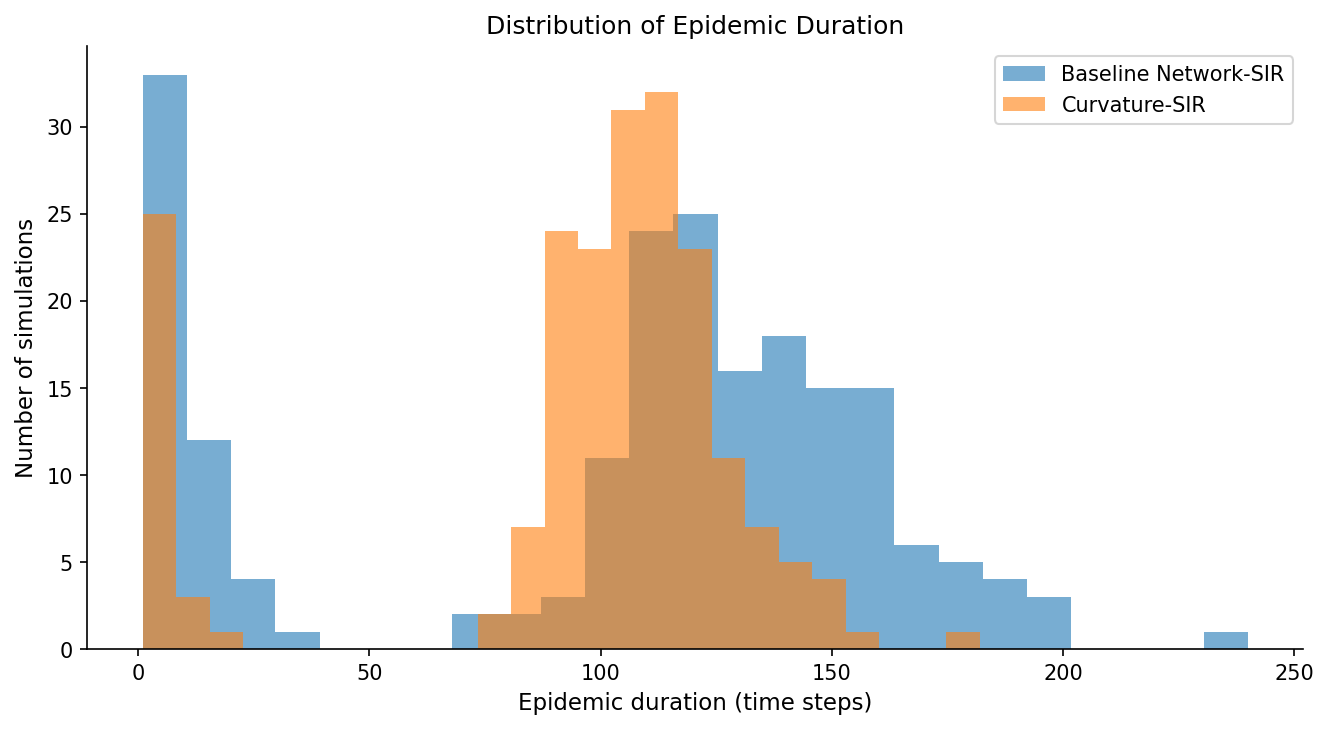

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    baseline_duration,
    bins=25,
    alpha=0.6,
    label="Baseline Network-SIR"
)

plt.hist(
    curvature_duration,
    bins=25,
    alpha=0.6,
    label="Curvature-SIR"
)

plt.xlabel("Epidemic duration (time steps)")
plt.ylabel("Number of simulations")
plt.title("Distribution of Epidemic Duration")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("EPIDEMIC DURATION QUANTILES")
print("=" * 50)

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

baseline_q = np.quantile(baseline_duration, quantiles)
curvature_q = np.quantile(curvature_duration, quantiles)

duration_quantiles = pd.DataFrame({
    "Quantile": [f"{q:.0%}" for q in quantiles],
    "Baseline": baseline_q,
    "Curvature-SIR": curvature_q
})

print(duration_quantiles.to_string(index=False))

EPIDEMIC DURATION QUANTILES
Quantile  Baseline  Curvature-SIR
     10%       4.0            5.0
     25%      61.5           91.0
     50%     119.5          105.0
     75%     144.0          117.0
     90%     163.0          130.0
     95%     176.2          140.0


In [ ]:
# ============================================================
# STEP 6D.3A
# PAIRED DURATION COMPARISON
# ============================================================

baseline_duration = (
    baseline_runs["metrics"]["Duration"]
    .to_numpy(dtype=float)
)

curvature_duration = (
    curvature_runs["metrics"]["Duration"]
    .to_numpy(dtype=float)
)

if not np.array_equal(
    baseline_runs["metrics"]["Run_ID"].to_numpy(),
    curvature_runs["metrics"]["Run_ID"].to_numpy()
):
    raise RuntimeError(
        "Baseline and Curvature-SIR Run_ID values are not aligned."
    )

duration_differences = (
    curvature_duration -
    baseline_duration
)

duration_ttest = scipy_stats.ttest_rel(
    curvature_duration,
    baseline_duration
)

try:
    duration_wilcoxon = scipy_stats.wilcoxon(
        duration_differences,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )
    duration_wilcoxon_stat = duration_wilcoxon.statistic
    duration_wilcoxon_p = duration_wilcoxon.pvalue

except ValueError:
    duration_wilcoxon_stat = 0.0
    duration_wilcoxon_p = 1.0

print("PAIRED DURATION COMPARISON")
print("=" * 60)

print(
    f"Mean paired difference "
    f"(Curvature - Baseline): "
    f"{duration_differences.mean():.6f}"
)

print(
    f"Paired t-test p-value : "
    f"{duration_ttest.pvalue:.6g}"
)

print(
    f"Wilcoxon p-value      : "
    f"{duration_wilcoxon_p:.6g}"
)


PAIRED DURATION COMPARISON
Mean paired difference (Curvature - Baseline): -7.850000
Paired t-test p-value : 0.0671464
Wilcoxon p-value      : 0.00141057


In [ ]:
# ============================================================
# STEP 6D.3B
# PAIRED DURATION EFFECT SIZE AND 95% CI
# ============================================================

n_duration = len(duration_differences)

duration_sd_difference = np.std(
    duration_differences,
    ddof=1
)

if duration_sd_difference > 0:

    duration_cohens_dz = (
        duration_differences.mean()
        /
        duration_sd_difference
    )

else:

    duration_cohens_dz = np.nan

if (
    n_duration > 1
    and
    duration_sd_difference > 0
):

    duration_se = (
        duration_sd_difference
        /
        np.sqrt(n_duration)
    )

    duration_tcrit = scipy_stats.t.ppf(
        0.975,
        df=n_duration - 1
    )

    duration_ci_lower = (
        duration_differences.mean()
        -
        duration_tcrit * duration_se
    )

    duration_ci_upper = (
        duration_differences.mean()
        +
        duration_tcrit * duration_se
    )

else:

    duration_ci_lower = duration_differences.mean()
    duration_ci_upper = duration_differences.mean()

duration_paired_summary = pd.DataFrame([
    {
        "Comparison":
            "Curvature-SIR vs Weighted Network-SIR",

        "Metric":
            "Duration",

        "N":
            n_duration,

        "Mean_Difference":
            duration_differences.mean(),

        "CI95_Lower":
            duration_ci_lower,

        "CI95_Upper":
            duration_ci_upper,

        "Paired_t_p":
            duration_ttest.pvalue,

        "Wilcoxon_p":
            duration_wilcoxon_p,

        "Cohens_dz":
            duration_cohens_dz
    }
])

display(
    duration_paired_summary.round(4)
)


,Comparison,Metric,N,Mean_Difference,CI95_Lower,CI95_Upper,Paired_t_p,Wilcoxon_p,Cohens_dz
0,Curvature-SIR vs Weighted Network-SIR,Duration,200,-7.85,-16.2595,0.5595,0.0671,0.0014,-0.1302


In [ ]:
# ============================================================
# STEP 6D.4
# PAPER-READY DESCRIPTIVE SUMMARY TABLE
# ============================================================

PAIR_METRICS = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

summary_rows = []

for model_name, output in [
    ("Weighted Network-SIR", baseline_runs),
    ("Curvature-SIR", curvature_runs)
]:

    metrics = output["metrics"]

    for metric in PAIR_METRICS:

        stats = summarize_metric(
            metrics[metric]
        )

        summary_rows.append({
            "Model": model_name,
            "Metric": metric,
            **stats
        })

summary_table = pd.DataFrame(
    summary_rows
)

display(
    summary_table.round(3)
)


,Model,Metric,N,Mean,SD,CI95_Lower,CI95_Upper,Median,IQR_Lower,IQR_Upper
0,Weighted Network-SIR,Peak_Infected,200,59.680,37.270,54.483,64.877,73.0,11.75,87.0
1,Weighted Network-SIR,Peak_Time,200,36.200,24.990,32.715,39.685,39.0,17.50,53.0
2,Weighted Network-SIR,Final_Size,200,202.995,121.028,186.119,219.871,274.0,26.25,282.0
3,Weighted Network-SIR,Duration,200,102.495,59.447,94.206,110.784,119.5,61.50,144.0
4,Curvature-SIR,Peak_Infected,200,119.955,51.215,112.814,127.096,137.0,121.75,148.0
5,Curvature-SIR,Peak_Time,200,27.095,12.636,25.333,28.857,29.0,25.00,34.0
6,Curvature-SIR,Final_Size,200,271.860,111.713,256.283,287.437,317.0,314.00,319.0
7,Curvature-SIR,Duration,200,94.645,40.469,89.002,100.288,105.0,91.00,117.0


In [ ]:
# Extract only epidemiological outcomes for the main comparison
e6_main_metrics = pd.concat([
    baseline_runs["metrics"].assign(
        Model="Weighted Network-SIR"
    ),
    curvature_runs["metrics"].assign(
        Model="Curvature-SIR"
    )
], ignore_index=True)

e6_main_metrics = e6_main_metrics[
    [
        "Model",
        "Peak_Infected",
        "Peak_Time",
        "Final_Size",
        "Duration"
    ]
]

print(e6_main_metrics.head())

                  Model  Peak_Infected  Peak_Time  Final_Size  Duration
0  Weighted Network-SIR            1.0        0.0         1.0         2
1  Weighted Network-SIR           98.0       54.0       287.0       156
2  Weighted Network-SIR           88.0       26.0       286.0       114
3  Weighted Network-SIR           57.0       55.0       274.0       186
4  Weighted Network-SIR            1.0        0.0         1.0         7


In [ ]:
summary_rows = []

for model in ["Weighted Network-SIR", "Curvature-SIR"]:
    model_data = e6_main_metrics[
        e6_main_metrics["Model"] == model
    ]

    for metric in [
        "Peak_Infected",
        "Peak_Time",
        "Final_Size",
        "Duration"
    ]:
        values = model_data[metric].to_numpy(dtype=float)

        summary = summarize_metric(values)

        summary_rows.append({
            "Model": model,
            "Metric": metric,
            "N": summary["N"],
            "Mean": summary["Mean"],
            "SD": summary["SD"],
            "CI95_Lower": summary["CI95_Lower"],
            "CI95_Upper": summary["CI95_Upper"],
            "Median": summary["Median"],
            "IQR_Lower": summary["IQR_Lower"],
            "IQR_Upper": summary["IQR_Upper"]
        })

e6_summary_table = pd.DataFrame(summary_rows)

print(
    e6_summary_table.to_string(index=False)
)

               Model        Metric   N    Mean         SD  CI95_Lower  CI95_Upper  Median  IQR_Lower  IQR_Upper
Weighted Network-SIR Peak_Infected 200  59.680  37.270404   54.483075   64.876925    73.0      11.75       87.0
Weighted Network-SIR     Peak_Time 200  36.200  24.990450   32.715372   39.684628    39.0      17.50       53.0
Weighted Network-SIR    Final_Size 200 202.995 121.028154  186.119030  219.870970   274.0      26.25      282.0
Weighted Network-SIR      Duration 200 102.495  59.447117   94.205790  110.784210   119.5      61.50      144.0
       Curvature-SIR Peak_Infected 200 119.955  51.215212  112.813634  127.096366   137.0     121.75      148.0
       Curvature-SIR     Peak_Time 200  27.095  12.636232   25.333024   28.856976    29.0      25.00       34.0
       Curvature-SIR    Final_Size 200 271.860 111.712978  256.282923  287.437077   317.0     314.00      319.0
       Curvature-SIR      Duration 200  94.645  40.469344   89.002020  100.287980   105.0      91.00    

In [ ]:
baseline_means = (
    e6_summary_table[
        e6_summary_table["Model"] == "Weighted Network-SIR"
    ]
    .set_index("Metric")["Mean"]
)

curvature_means = (
    e6_summary_table[
        e6_summary_table["Model"] == "Curvature-SIR"
    ]
    .set_index("Metric")["Mean"]
)

e6_mean_comparison = pd.DataFrame({
    "Baseline_Mean": baseline_means,
    "Curvature_Mean": curvature_means
})

e6_mean_comparison["Absolute_Difference"] = (
    e6_mean_comparison["Curvature_Mean"]
    - e6_mean_comparison["Baseline_Mean"]
)

e6_mean_comparison["Relative_Change_Percent"] = (
    100
    * e6_mean_comparison["Absolute_Difference"]
    / e6_mean_comparison["Baseline_Mean"]
)

print(
    e6_mean_comparison.to_string()
)

               Baseline_Mean  Curvature_Mean  Absolute_Difference  Relative_Change_Percent
Metric                                                                                    
Peak_Infected         59.680         119.955               60.275               100.996984
Peak_Time             36.200          27.095               -9.105               -25.151934
Final_Size           202.995         271.860               68.865                33.924481
Duration             102.495          94.645               -7.850                -7.658910


In [ ]:
summary_table.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_statistical_summary.csv"
    ),
    index=False
)

In [ ]:
# ============================================================
# STEP 6D.6
# MEAN EPIDEMIC CURVES WITH 95% CI
# ============================================================

def epidemic_curve_summary(curves):

    mean = np.nanmean(
        curves,
        axis=0
    )

    n = np.sum(
        ~np.isnan(curves),
        axis=0
    )

    # Initialise SD/CI arrays
    sd = np.full(
        mean.shape,
        np.nan,
        dtype=float
    )

    ci = np.full(
        mean.shape,
        np.nan,
        dtype=float
    )

    # Only calculate sample SD where at least
    # two valid stochastic trajectories remain
    valid = n >= 2

    sd[valid] = np.nanstd(
        curves[:, valid],
        axis=0,
        ddof=1
    )

    se = np.full(
        mean.shape,
        np.nan,
        dtype=float
    )

    se[valid] = (
        sd[valid] / np.sqrt(n[valid])
    )

    ci[valid] = 1.96 * se[valid]

    return mean, ci


# ------------------------------------------------------------
# Compute baseline summary
# ------------------------------------------------------------

baseline_mean, baseline_ci = epidemic_curve_summary(
    baseline_runs["infected_curves"]
)


# ------------------------------------------------------------
# Compute curvature summary
# ------------------------------------------------------------

curvature_mean, curvature_ci = epidemic_curve_summary(
    curvature_runs["infected_curves"]
)


# ------------------------------------------------------------
# Construct CI bounds
#
# The CI itself is unchanged.
# Lower bounds are clipped at zero only for visualization.
# ------------------------------------------------------------

baseline_lower = np.maximum(
    baseline_mean - baseline_ci,
    0
)

baseline_upper = (
    baseline_mean + baseline_ci
)

curvature_lower = np.maximum(
    curvature_mean - curvature_ci,
    0
)

curvature_upper = (
    curvature_mean + curvature_ci
)


# ------------------------------------------------------------
# Define separate time axes
# ------------------------------------------------------------

t_baseline = np.arange(
    len(baseline_mean)
)

t_curvature = np.arange(
    len(curvature_mean)
)


print("Baseline trajectory length:", len(baseline_mean))
print("Curvature trajectory length:", len(curvature_mean))
print("Baseline curves shape:", baseline_runs["infected_curves"].shape)
print("Curvature curves shape:", curvature_runs["infected_curves"].shape)

Baseline trajectory length: 241
Curvature trajectory length: 183
Baseline curves shape: (200, 241)
Curvature curves shape: (200, 183)


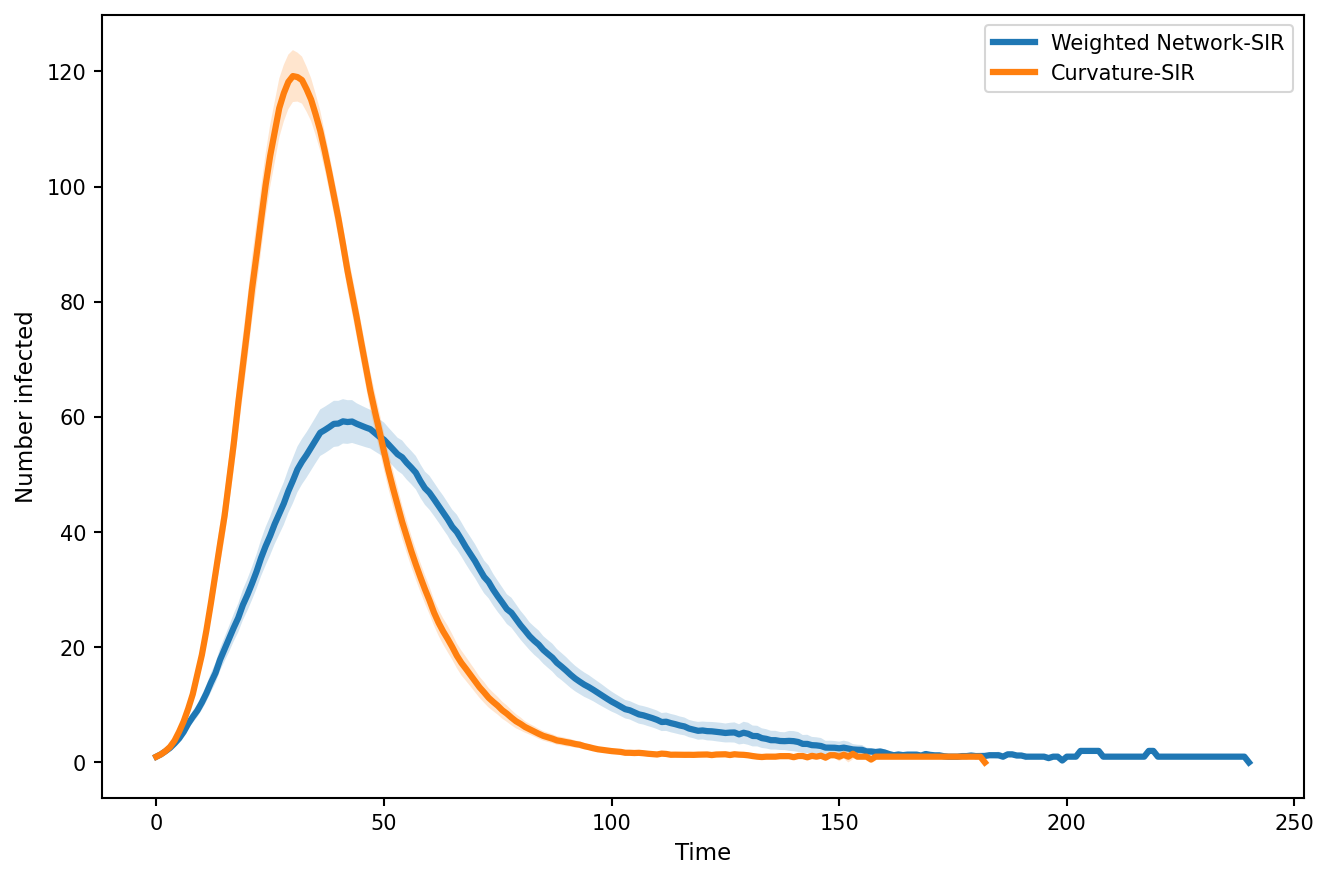

In [ ]:
# ============================================================
# PLOT — BASELINE VS CURVATURE-SIR WITH 95% CI
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150
)

# ------------------------------------------------------------
# Define time axes from the trajectory lengths
# ------------------------------------------------------------

t_baseline = np.arange(len(baseline_mean))
t_curvature = np.arange(len(curvature_mean))

# ------------------------------------------------------------
# Baseline Weighted Network-SIR
# ------------------------------------------------------------

ax.plot(
    t_baseline,
    baseline_mean,
    linewidth=3,
    label="Weighted Network-SIR"
)

ax.fill_between(
    t_baseline,
    baseline_lower,
    baseline_upper,
    alpha=0.20
)

# ------------------------------------------------------------
# Curvature-SIR
# ------------------------------------------------------------

ax.plot(
    t_curvature,
    curvature_mean,
    linewidth=3,
    label="Curvature-SIR"
)

ax.fill_between(
    t_curvature,
    curvature_lower,
    curvature_upper,
    alpha=0.20
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Time"
)

ax.set_ylabel(
    "Number infected"
)

ax.legend()

# ------------------------------------------------------------
# BOXED AXES
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    direction="out",
    length=4,
    width=1.0,
    colors="black"
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Baseline_vs_Curvature_CI.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

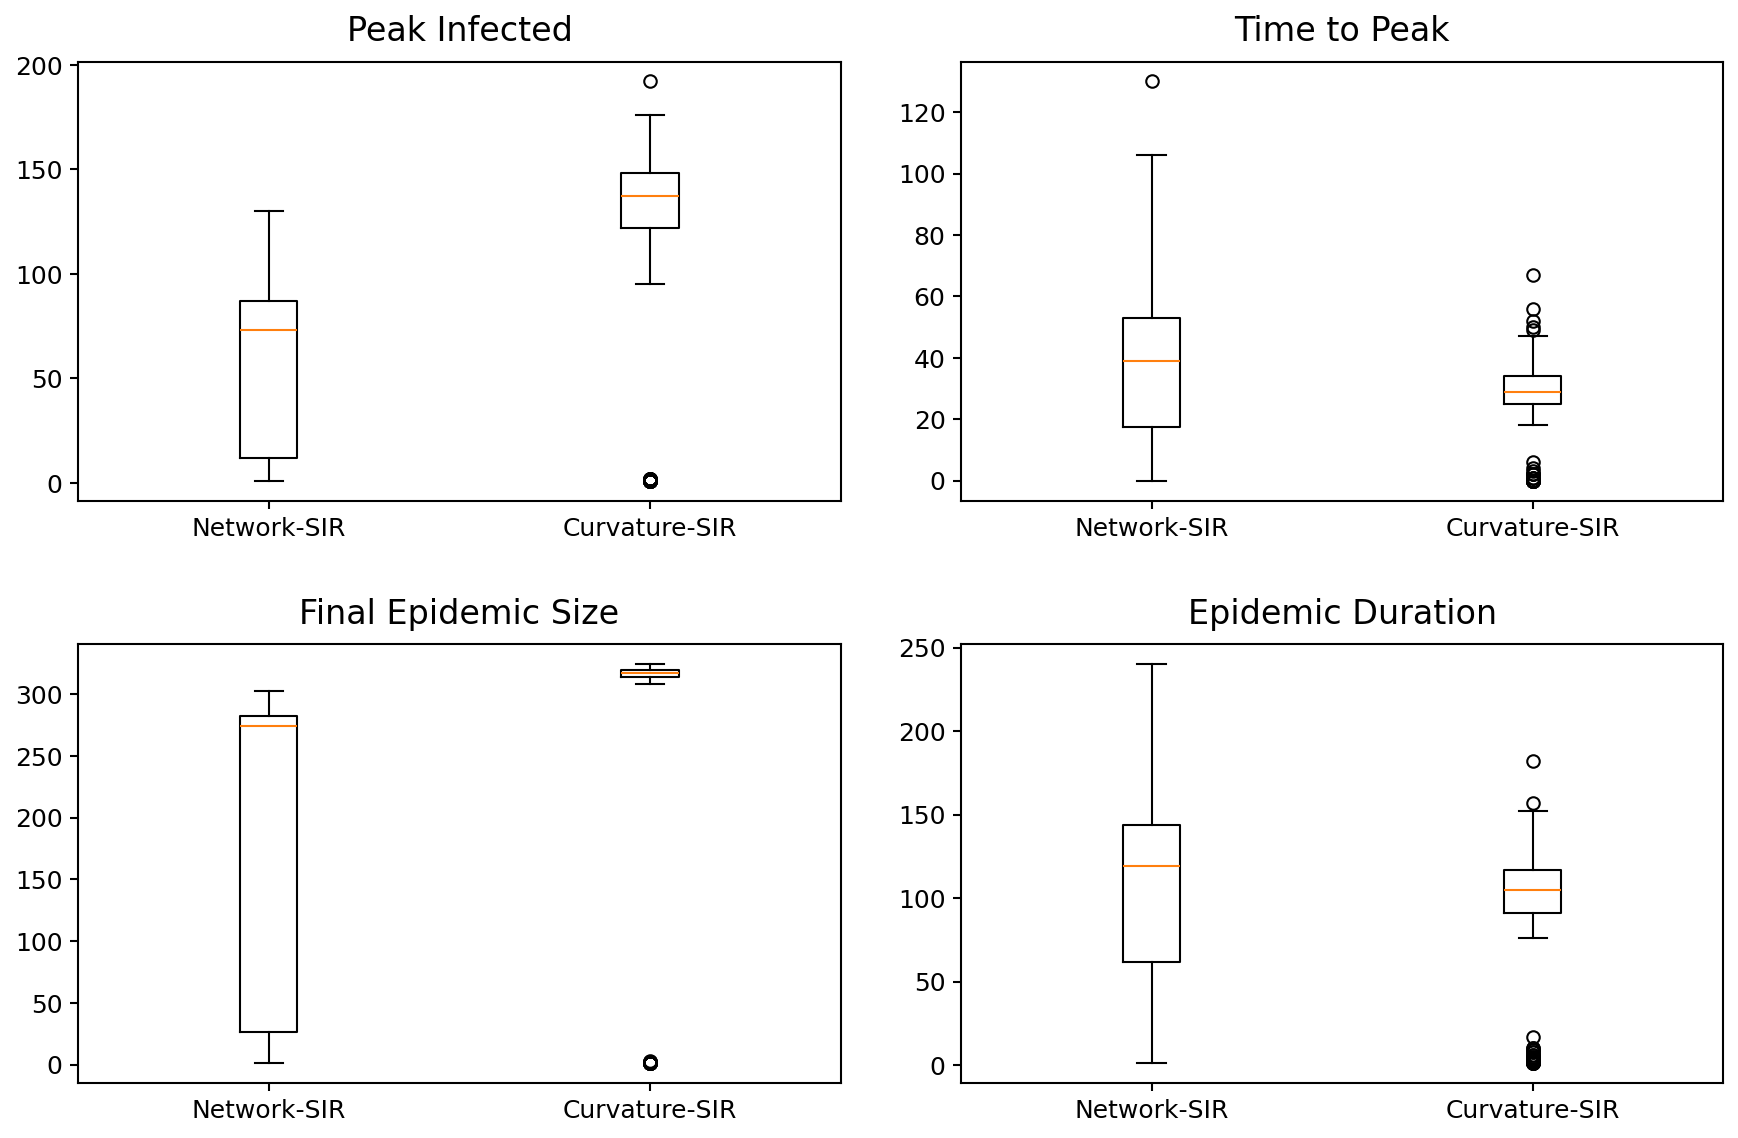

In [ ]:
# ============================================================
# STEP 6D.7
# BOXPLOT COMPARISON OF STOCHASTIC OUTCOMES
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    dpi=150
)

metrics = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

titles = [
    "Peak Infected",
    "Time to Peak",
    "Final Epidemic Size",
    "Epidemic Duration"
]

for ax, metric, title in zip(
    axes.flatten(),
    metrics,
    titles
):

    ax.boxplot(
        [
            baseline_runs["metrics"][metric],
            curvature_runs["metrics"][metric]
        ]
    )

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        [
            "Network-SIR",
            "Curvature-SIR"
        ],
        rotation=0
    )

    ax.set_title(
        title,
        fontsize=16,
        pad=10
    )

    #ax.grid(
     #   axis="y",
      #  alpha=0.3
    #)

    ax.tick_params(
        axis="both",
        labelsize=12
    )

    # ------------------------------------------------------------
    # BOXED AXES (The Rectangle Effect for each subplot)
    # ------------------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    # Ensure ticks are drawn with consistent style
    ax.tick_params(
        direction="out",
        length=4,
        width=1.0,
        colors="black"
    )

plt.tight_layout(
    pad=2.0,
    w_pad=2.5,
    h_pad=2.5
)

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Boxplots.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

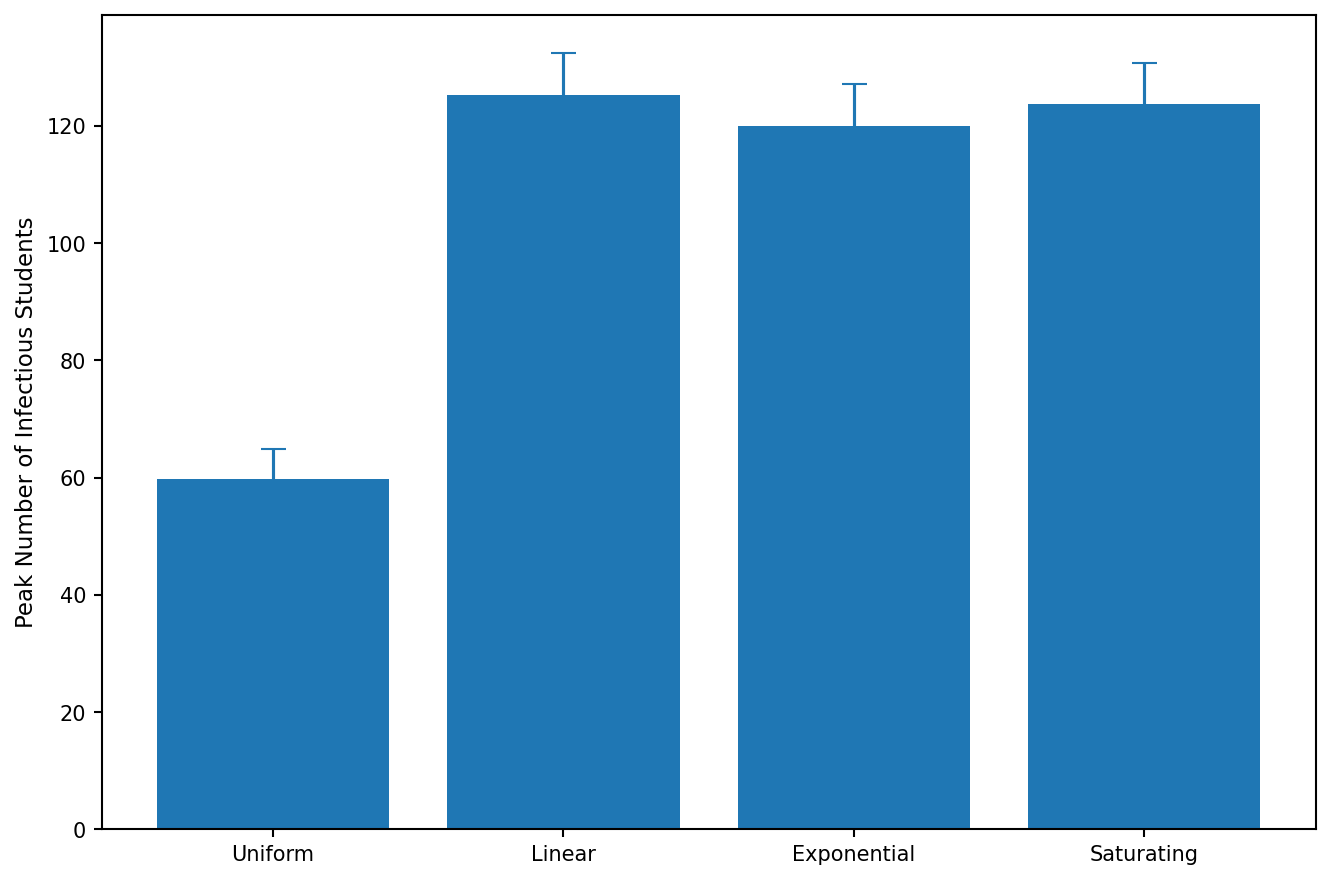

In [ ]:
# ============================================================
# STEP 6D.8
# MAPPING ROBUSTNESS WITH 95% CI
# ============================================================

mapping_results = []

for mapping_name, attr in E6_MAPPINGS.items():

    out = run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr=attr,
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )

    stats = summarize_metric(
        out["metrics"]["Peak_Infected"]
    )

    mapping_results.append({

        "Mapping": mapping_name,
        **stats
    })

mapping_peak_df = pd.DataFrame(mapping_results)

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150
)

means = mapping_peak_df["Mean"]

err_low = means - mapping_peak_df["CI95_Lower"]

err_high = mapping_peak_df["CI95_Upper"] - means

ax.bar(mapping_peak_df["Mapping"], means)

ax.errorbar(
    mapping_peak_df["Mapping"],
    means,
    yerr=[err_low, err_high],
    fmt='none',
    capsize=6
)

ax.set_ylabel("Peak Number of Infectious Students")

#ax.set_title(
#    "Peak Epidemic Size Across Curvature-Transmission Mappings\n"
#    "(Mean ± 95% CI)"
#)

#ax.grid(alpha=0.3)

# ------------------------------------------------------------
# BOXED AXES (The Rectangle Effect)
# ------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    direction="out",
    length=4,
    width=1.0,
    colors="black"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Mapping_Robustness.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 6D.9
# ALPHA SENSITIVITY WITH 95% CI
# ============================================================

alpha_summary = []

# Store the complete ensemble output for each alpha.
# This will also allow us to verify that alpha = 0
# exactly reproduces the baseline ensemble.
alpha_results = {}

for alpha in E6_ALPHA_GRID:

    print(
        f"\nRunning alpha = {alpha:.2f}"
    )

    # --------------------------------------------------------
    # Rebuild curvature-to-transmission mappings
    # for the current alpha value.
    # --------------------------------------------------------

    attach_e6_mapping_curvature(
        G,
        source_attr="curvature_std",
        alpha=float(alpha)
    )

    # --------------------------------------------------------
    # Run the existing stochastic SIR simulator through
    # the extended ensemble wrapper.
    # --------------------------------------------------------

    out = run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr="mapping_exponential",
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )

    alpha_results[float(alpha)] = out

    metrics = out["metrics"]

    # --------------------------------------------------------
    # Check for truncated simulations
    # --------------------------------------------------------

    n_truncated = int(
        metrics["Hit_Max_Steps"].sum()
    )

    if n_truncated > 0:

        raise RuntimeError(
            f"Alpha = {alpha:.2f}: "
            f"{n_truncated} runs reached max_steps."
        )

    # --------------------------------------------------------
    # Statistical summaries
    # --------------------------------------------------------

    peak_stats = summarize_metric(
        metrics["Peak_Infected"]
    )

    peak_time_stats = summarize_metric(
        metrics["Peak_Time"]
    )

    final_size_stats = summarize_metric(
        metrics["Final_Size"]
    )

    duration_stats = summarize_metric(
        metrics["Duration"]
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    alpha_summary.append({

        "Network":
            "High-School",

        "Alpha":
            float(alpha),

        # Peak infected
        "Peak_Infected_Mean":
            peak_stats["Mean"],

        "Peak_Infected_SD":
            peak_stats["SD"],

        "Peak_Infected_CI95_Lower":
            peak_stats["CI95_Lower"],

        "Peak_Infected_CI95_Upper":
            peak_stats["CI95_Upper"],

        "Peak_Infected_Median":
            peak_stats["Median"],

        "Peak_Infected_IQR_Lower":
            peak_stats["IQR_Lower"],

        "Peak_Infected_IQR_Upper":
            peak_stats["IQR_Upper"],

        # Peak time
        "Peak_Time_Mean":
            peak_time_stats["Mean"],

        "Peak_Time_SD":
            peak_time_stats["SD"],

        "Peak_Time_CI95_Lower":
            peak_time_stats["CI95_Lower"],

        "Peak_Time_CI95_Upper":
            peak_time_stats["CI95_Upper"],

        "Peak_Time_Median":
            peak_time_stats["Median"],

        "Peak_Time_IQR_Lower":
            peak_time_stats["IQR_Lower"],

        "Peak_Time_IQR_Upper":
            peak_time_stats["IQR_Upper"],

        # Final epidemic size
        "Final_Size_Mean":
            final_size_stats["Mean"],

        "Final_Size_SD":
            final_size_stats["SD"],

        "Final_Size_CI95_Lower":
            final_size_stats["CI95_Lower"],

        "Final_Size_CI95_Upper":
            final_size_stats["CI95_Upper"],

        "Final_Size_Median":
            final_size_stats["Median"],

        "Final_Size_IQR_Lower":
            final_size_stats["IQR_Lower"],

        "Final_Size_IQR_Upper":
            final_size_stats["IQR_Upper"],

        # Duration
        "Duration_Mean":
            duration_stats["Mean"],

        "Duration_SD":
            duration_stats["SD"],

        "Duration_CI95_Lower":
            duration_stats["CI95_Lower"],

        "Duration_CI95_Upper":
            duration_stats["CI95_Upper"],

        "Duration_Median":
            duration_stats["Median"],

        "Duration_IQR_Lower":
            duration_stats["IQR_Lower"],

        "Duration_IQR_Upper":
            duration_stats["IQR_Upper"],

        "N":
            len(metrics)

    })


# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

alpha_summary_df = pd.DataFrame(
    alpha_summary
)

print("\nALPHA SENSITIVITY SUMMARY")
print("=" * 80)

display(
    alpha_summary_df.round(3)
)


Running alpha = 0.00

Running alpha = 0.25

Running alpha = 0.50

Running alpha = 0.75

Running alpha = 1.00

Running alpha = 1.50

Running alpha = 2.00

ALPHA SENSITIVITY SUMMARY


,Network,Alpha,Peak_Infected_Mean,Peak_Infected_SD,Peak_Infected_CI95_Lower,Peak_Infected_CI95_Upper,Peak_Infected_Median,Peak_Infected_IQR_Lower,Peak_Infected_IQR_Upper,Peak_Time_Mean,...,Final_Size_IQR_Lower,Final_Size_IQR_Upper,Duration_Mean,Duration_SD,Duration_CI95_Lower,Duration_CI95_Upper,Duration_Median,Duration_IQR_Lower,Duration_IQR_Upper,N
0,High-School,0.00,59.680,37.270,54.483,64.877,73.0,11.75,87.00,36.200,...,26.25,282.00,102.495,59.447,94.206,110.784,119.5,61.50,144.0,200
1,High-School,0.25,92.195,42.584,86.257,98.133,106.0,89.00,118.00,33.825,...,296.00,307.00,102.090,45.721,95.715,108.465,114.0,99.75,126.0,200
2,High-School,0.50,105.825,48.217,99.102,112.548,121.5,104.00,133.25,28.975,...,306.00,314.00,95.070,43.287,89.034,101.106,106.5,93.00,118.0,200
3,High-School,0.75,116.440,47.225,109.855,123.025,129.0,115.75,143.00,28.160,...,312.00,318.00,97.095,39.406,91.600,102.590,105.0,95.00,119.0,200
4,High-School,1.00,119.955,51.215,112.814,127.096,137.0,121.75,148.00,27.095,...,314.00,319.00,94.645,40.469,89.002,100.288,105.0,91.00,117.0,200
5,High-School,1.50,131.730,47.839,125.059,138.401,145.5,134.00,156.25,26.385,...,317.00,321.25,96.455,37.259,91.260,101.650,102.0,91.00,116.0,200
6,High-School,2.00,136.365,46.066,129.942,142.788,150.0,137.00,160.00,26.540,...,319.00,322.00,96.750,35.095,91.856,101.644,102.0,91.00,114.0,200


In [ ]:
# ============================================================
# STEP 6.14 — ALPHA-RELATIVE EFFECTS
# ============================================================

alpha_baseline = (
    alpha_summary_df[
        alpha_summary_df["Alpha"] == 0.0
    ]
    .iloc[0]
)

alpha_effects = alpha_summary_df.copy()

alpha_effects["Peak_Change_Pct"] = (
    (
        alpha_effects["Peak_Infected_Mean"]
        - alpha_baseline["Peak_Infected_Mean"]
    )
    / alpha_baseline["Peak_Infected_Mean"]
    * 100
)

alpha_effects["Peak_Time_Change_Pct"] = (
    (
        alpha_effects["Peak_Time_Mean"]
        - alpha_baseline["Peak_Time_Mean"]
    )
    / alpha_baseline["Peak_Time_Mean"]
    * 100
)

alpha_effects["Final_Size_Change_Pct"] = (
    (
        alpha_effects["Final_Size_Mean"]
        - alpha_baseline["Final_Size_Mean"]
    )
    / alpha_baseline["Final_Size_Mean"]
    * 100
)

display(
    alpha_effects[
        [
            "Alpha",
            "Peak_Infected_Mean",
            "Peak_Change_Pct",
            "Peak_Time_Mean",
            "Peak_Time_Change_Pct",
            "Final_Size_Mean",
            "Final_Size_Change_Pct"
        ]
    ].round(3)
)

,Alpha,Peak_Infected_Mean,Peak_Change_Pct,Peak_Time_Mean,Peak_Time_Change_Pct,Final_Size_Mean,Final_Size_Change_Pct
0,0.00,59.680,0.000,36.200,0.000,202.995,0.000
1,0.25,92.195,54.482,33.825,-6.561,255.165,25.700
2,0.50,105.825,77.321,28.975,-19.959,262.150,29.141
3,0.75,116.440,95.107,28.160,-22.210,275.075,35.508
4,1.00,119.955,100.997,27.095,-25.152,271.860,33.924
5,1.50,131.730,120.727,26.385,-27.113,284.780,40.289
6,2.00,136.365,128.494,26.540,-26.685,290.610,43.161


In [ ]:
# ============================================================
# STEP 6.14A — LINEAR MAPPING CLIPPING DIAGNOSTIC
# ============================================================
#
# Quantify the proportion of edges affected by positivity
# clipping under the linear curvature mapping:
#
#     g_linear(F) = max(epsilon, 1 + alpha * F_tilde)
#
# An edge is classified as clipped when:
#
#     1 + alpha * F_tilde <= epsilon
#
# This diagnostic is evaluated independently of the epidemic
# simulations so that clipping can be reported transparently.
# ============================================================

linear_clipping_diagnostic = []

# Curvature values used by the Experiment 6 mapping
F_std = np.array(
    [
        float(d.get("curvature_std", 0.0))
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

n_edges = len(F_std)

if n_edges == 0:
    raise RuntimeError(
        "No edges were found in G for the clipping diagnostic."
    )


for alpha in E6_ALPHA_GRID:

    alpha = float(alpha)

    # Raw linear mapping before positivity clipping
    raw_linear = (
        1.0
        + alpha * F_std
    )

    # Edges whose raw value is at or below epsilon
    clipped_mask = (
        raw_linear <= E6_EPSILON
    )

    n_clipped = int(
        np.sum(clipped_mask)
    )

    clipping_percentage = (
        100.0 * n_clipped / n_edges
    )

    linear_clipping_diagnostic.append({
        "Network": "High-School",
        "Alpha": alpha,
        "Total_Edges": n_edges,
        "Clipped_Edges": n_clipped,
        "Clipped_Edge_Percentage": clipping_percentage,
        "Minimum_Raw_Linear_Mapping": float(
            np.min(raw_linear)
        ),
        "Maximum_Raw_Linear_Mapping": float(
            np.max(raw_linear)
        )
    })


linear_clipping_df = pd.DataFrame(
    linear_clipping_diagnostic
)


display(
    linear_clipping_df.round(4)
)

,Network,Alpha,Total_Edges,Clipped_Edges,Clipped_Edge_Percentage,Minimum_Raw_Linear_Mapping,Maximum_Raw_Linear_Mapping
0,High-School,0.00,5818,0,0.0000,1.0000,1.0000
1,High-School,0.25,5818,71,1.2204,-2.0802,1.1700
2,High-School,0.50,5818,255,4.3829,-5.1604,1.3399
3,High-School,0.75,5818,410,7.0471,-8.2407,1.5099
4,High-School,1.00,5818,525,9.0237,-11.3209,1.6799
5,High-School,1.50,5818,703,12.0832,-17.4813,2.0198
6,High-School,2.00,5818,840,14.4380,-23.6418,2.3597


In [ ]:
# ============================================================
# STEP 6.14B — LINEAR CLIPPING REPORT AT ALPHA = 1
# ============================================================

alpha1_clipping = linear_clipping_df[
    np.isclose(
        linear_clipping_df["Alpha"],
        1.0
    )
].iloc[0]

print(
    "LINEAR MAPPING CLIPPING AT ALPHA = 1"
)
print("=" * 60)

print(
    f"Total edges       : "
    f"{int(alpha1_clipping['Total_Edges'])}"
)

print(
    f"Clipped edges     : "
    f"{int(alpha1_clipping['Clipped_Edges'])}"
)

print(
    f"Clipped edges (%) : "
    f"{alpha1_clipping['Clipped_Edge_Percentage']:.2f}%"
)

LINEAR MAPPING CLIPPING AT ALPHA = 1
Total edges       : 5818
Clipped edges     : 525
Clipped edges (%) : 9.02%


In [ ]:
# ------------------------------------------------------------
# Save clipping diagnostic
# ------------------------------------------------------------

linear_clipping_df.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_linear_clipping_diagnostic.csv"
    ),
    index=False
)

print(
    "Saved:",
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_linear_clipping_diagnostic.csv"
    )
)

Saved: experiment6_results/experiment6d_linear_clipping_diagnostic.csv


In [ ]:
# ============================================================
# STEP 6.15 — VERIFY ALPHA = 0 BASELINE RECOVERY
# ============================================================

alpha0_metrics = alpha_results[0.0]["metrics"]
baseline_metrics = baseline_runs["metrics"]

metrics_to_check = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

print("ALPHA = 0 BASELINE RECOVERY CHECK")
print("=" * 60)

all_passed = True

for metric in metrics_to_check:

    alpha0_values = alpha0_metrics[metric].to_numpy()
    baseline_values = baseline_metrics[metric].to_numpy()

    passed = np.array_equal(
        alpha0_values,
        baseline_values
    )

    max_difference = np.max(
        np.abs(alpha0_values - baseline_values)
    )

    print(
        f"{metric:15s} : "
        f"{'PASS' if passed else 'FAIL'} "
        f"(max difference = {max_difference:.6g})"
    )

    if not passed:
        all_passed = False

if not all_passed:
    raise RuntimeError(
        "Alpha = 0 does not exactly reproduce the baseline ensemble."
    )

print(
    "✓ Alpha = 0 exactly reproduces the baseline ensemble."
)

# ------------------------------------------------------------
# Verify paired replicate metadata
# ------------------------------------------------------------

for col in ["Run_ID", "Seed"]:

    if not np.array_equal(
        alpha_results[0.0]["metrics"][col].to_numpy(),
        baseline_runs["metrics"][col].to_numpy()
    ):
        raise RuntimeError(
            f"Alpha = 0 {col} values do not match the baseline ensemble."
        )

print(
    "✓ Alpha = 0 replicate IDs and seeds match the baseline ensemble."
)


ALPHA = 0 BASELINE RECOVERY CHECK
Peak_Infected   : PASS (max difference = 0)
Peak_Time       : PASS (max difference = 0)
Final_Size      : PASS (max difference = 0)
Duration        : PASS (max difference = 0)
✓ Alpha = 0 exactly reproduces the baseline ensemble.
✓ Alpha = 0 replicate IDs and seeds match the baseline ensemble.


In [ ]:
# ============================================================
# STEP 6.15A — VERIFY ALPHA = 1 TABLE 6 CONSISTENCY
# ============================================================

# The alpha = 1 result from the sensitivity experiment must
# reproduce the principal Curvature-SIR ensemble used for
# Table 6 because both use the same:
#
#   - network
#   - beta0
#   - gamma
#   - edge weights
#   - alpha
#   - random seeds
#   - mean-normalised exponential mapping

alpha1_metrics = alpha_results[
    float(E6_ALPHA_MAIN)
]["metrics"]

table6_curvature_metrics = (
    curvature_runs["metrics"]
)

metrics_to_check = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

print(
    "ALPHA = 1 TABLE 6 CONSISTENCY CHECK"
)
print("=" * 60)

all_passed = True

for metric in metrics_to_check:

    alpha1_values = (
        alpha1_metrics[metric]
        .to_numpy()
    )

    table6_values = (
        table6_curvature_metrics[metric]
        .to_numpy()
    )

    passed = np.array_equal(
        alpha1_values,
        table6_values
    )

    max_difference = np.max(
        np.abs(
            alpha1_values -
            table6_values
        )
    )

    print(
        f"{metric:15s}: "
        f"{'PASS' if passed else 'FAIL'} "
        f"(max difference = "
        f"{max_difference:.6g})"
    )

    if not passed:
        all_passed = False

if not all_passed:

    raise RuntimeError(
        "The alpha = 1 sensitivity ensemble "
        "does not exactly reproduce the "
        "Table 6 curvature ensemble."
    )

print(
    "✓ Alpha = 1 exactly reproduces the "
    "Table 6 Curvature-SIR ensemble."
)

# ------------------------------------------------------------
# Verify paired replicate metadata
# ------------------------------------------------------------

for col in ["Run_ID", "Seed"]:

    if not np.array_equal(
        alpha_results[float(E6_ALPHA_MAIN)]["metrics"][col].to_numpy(),
        curvature_runs["metrics"][col].to_numpy()
    ):
        raise RuntimeError(
            f"Alpha = 1 {col} values do not match the "
            "principal Curvature-SIR ensemble."
        )

print(
    "✓ Alpha = 1 replicate IDs and seeds match the "
    "principal Curvature-SIR ensemble."
)


ALPHA = 1 TABLE 6 CONSISTENCY CHECK
Peak_Infected  : PASS (max difference = 0)
Peak_Time      : PASS (max difference = 0)
Final_Size     : PASS (max difference = 0)
Duration       : PASS (max difference = 0)
✓ Alpha = 1 exactly reproduces the Table 6 Curvature-SIR ensemble.
✓ Alpha = 1 replicate IDs and seeds match the principal Curvature-SIR ensemble.


In [ ]:
print(alpha_summary_df.columns.tolist())

['Network', 'Alpha', 'Peak_Infected_Mean', 'Peak_Infected_SD', 'Peak_Infected_CI95_Lower', 'Peak_Infected_CI95_Upper', 'Peak_Infected_Median', 'Peak_Infected_IQR_Lower', 'Peak_Infected_IQR_Upper', 'Peak_Time_Mean', 'Peak_Time_SD', 'Peak_Time_CI95_Lower', 'Peak_Time_CI95_Upper', 'Peak_Time_Median', 'Peak_Time_IQR_Lower', 'Peak_Time_IQR_Upper', 'Final_Size_Mean', 'Final_Size_SD', 'Final_Size_CI95_Lower', 'Final_Size_CI95_Upper', 'Final_Size_Median', 'Final_Size_IQR_Lower', 'Final_Size_IQR_Upper', 'Duration_Mean', 'Duration_SD', 'Duration_CI95_Lower', 'Duration_CI95_Upper', 'Duration_Median', 'Duration_IQR_Lower', 'Duration_IQR_Upper', 'N']


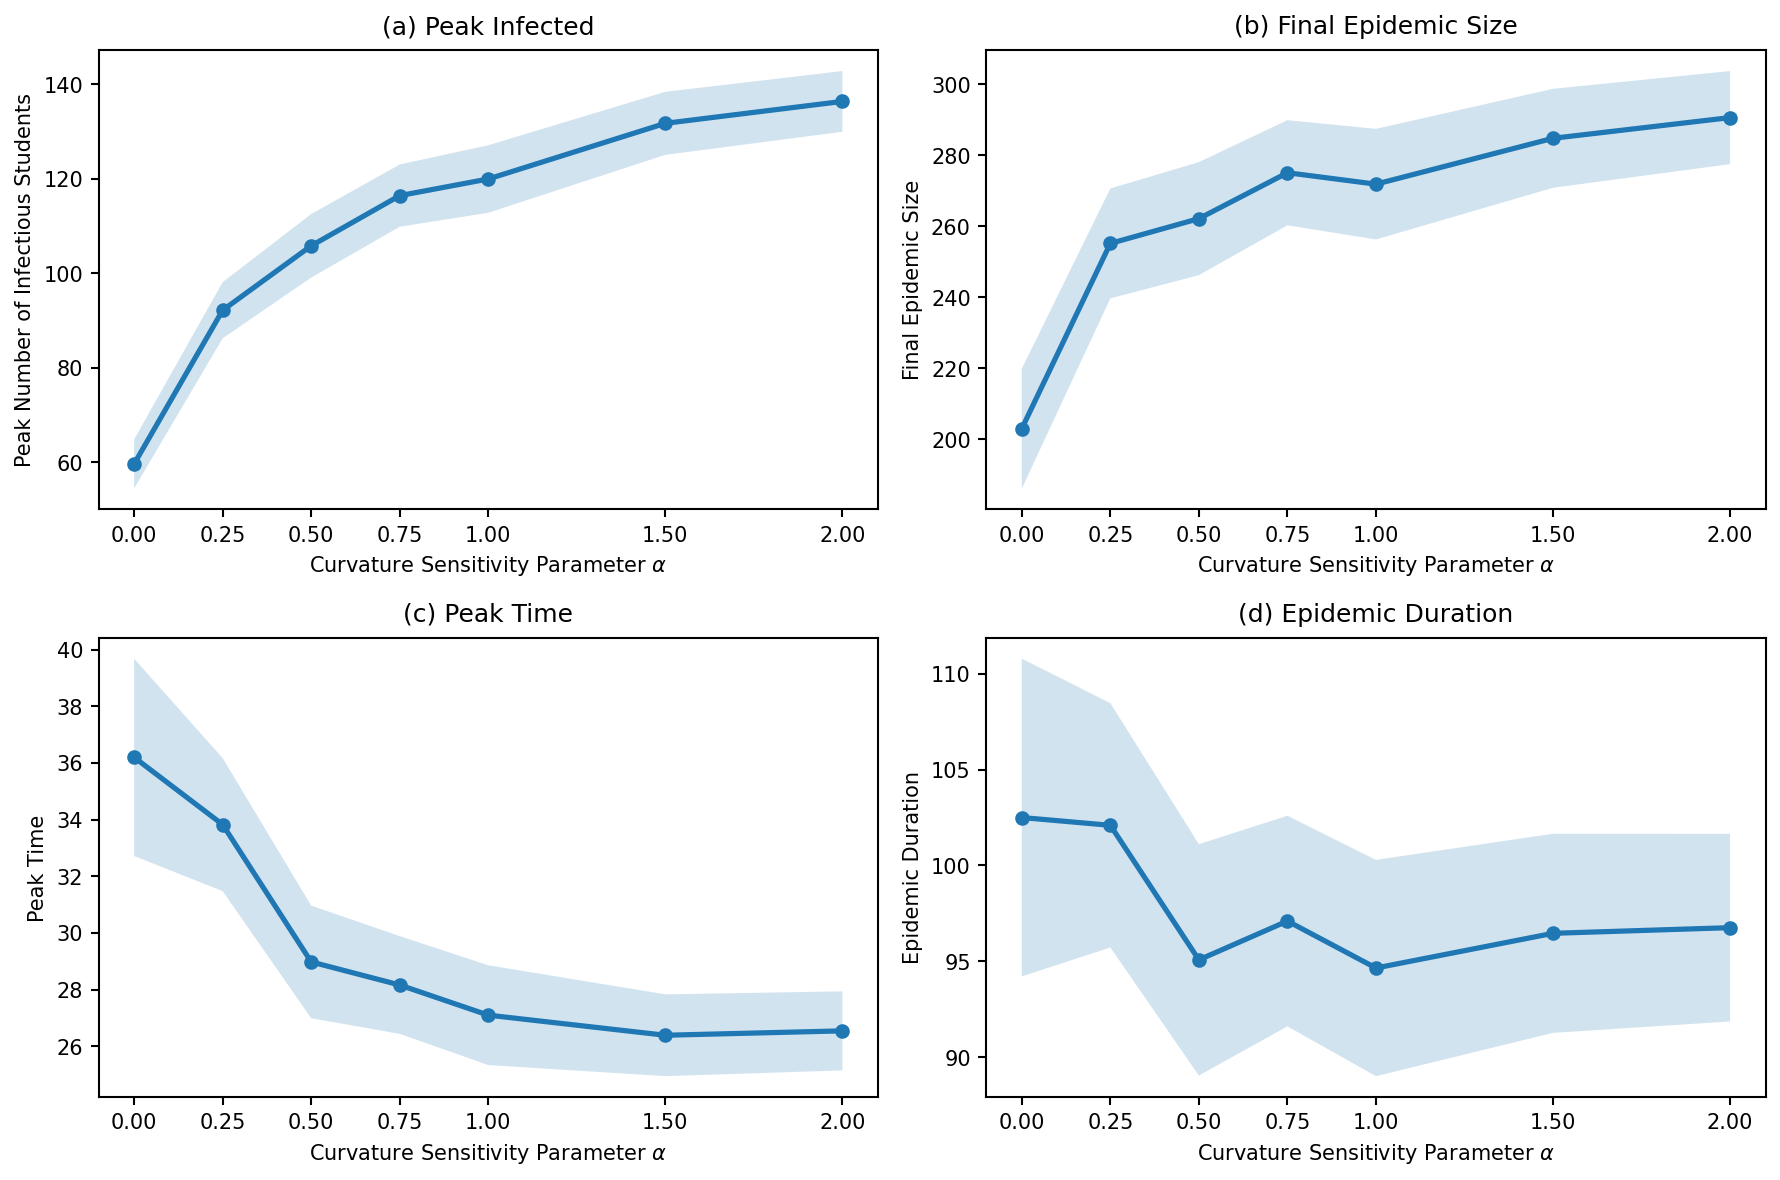

In [ ]:
# ============================================================
# FIGURE E6 — ALPHA SENSITIVITY OF EPIDEMIC OUTCOMES
# ============================================================

# ------------------------------------------------------------
# Create 2 × 2 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    dpi=150
)

axes = axes.flatten()

# ------------------------------------------------------------
# Define metrics
# ------------------------------------------------------------

metrics = [
    {
        "mean": "Peak_Infected_Mean",
        "lower": "Peak_Infected_CI95_Lower",
        "upper": "Peak_Infected_CI95_Upper",
        "ylabel": "Peak Number of Infectious Students",
        "title": "(a) Peak Infected"
    },
    {
        "mean": "Final_Size_Mean",
        "lower": "Final_Size_CI95_Lower",
        "upper": "Final_Size_CI95_Upper",
        "ylabel": "Final Epidemic Size",
        "title": "(b) Final Epidemic Size"
    },
    {
        "mean": "Peak_Time_Mean",
        "lower": "Peak_Time_CI95_Lower",
        "upper": "Peak_Time_CI95_Upper",
        "ylabel": "Peak Time",
        "title": "(c) Peak Time"
    },
    {
        "mean": "Duration_Mean",
        "lower": "Duration_CI95_Lower",
        "upper": "Duration_CI95_Upper",
        "ylabel": "Epidemic Duration",
        "title": "(d) Epidemic Duration"
    }
]

# ------------------------------------------------------------
# Plot each metric
# ------------------------------------------------------------

for ax, metric in zip(axes, metrics):

    x = alpha_summary_df["Alpha"]

    mean = alpha_summary_df[metric["mean"]]
    lower = alpha_summary_df[metric["lower"]]
    upper = alpha_summary_df[metric["upper"]]

    # Mean trajectory
    ax.plot(
        x,
        mean,
        marker="o",
        linewidth=2.5,
        markersize=6
    )

    # 95% confidence interval
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.20
    )

    # Panel title
    ax.set_title(
        metric["title"],
        fontsize=12,
        pad=8
    )

    # Axis labels
    ax.set_xlabel(
        r"Curvature Sensitivity Parameter $\alpha$",
        fontsize=10
    )

    ax.set_ylabel(
        metric["ylabel"],
        fontsize=10
    )

    # Grid
    #ax.grid(alpha=0.3)

    # Ensure all alpha values are displayed
    ax.set_xticks(
        alpha_summary_df["Alpha"]
    )

    # ------------------------------------------------------------
    # BOXED AXES (The Rectangle Effect for each subplot)
    # ------------------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.tick_params(
        direction="out",
        length=4,
        width=1.0,
        colors="black"
    )

# ------------------------------------------------------------
# Overall figure layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Alpha_Sensitivity.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# RESTORE MAIN CURVATURE MAPPING
# ============================================================

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=float(E6_ALPHA_MAIN)
)

print(
    f"Curvature mappings restored to alpha = "
    f"{E6_ALPHA_MAIN:.2f}"
)

Curvature mappings restored to alpha = 1.00


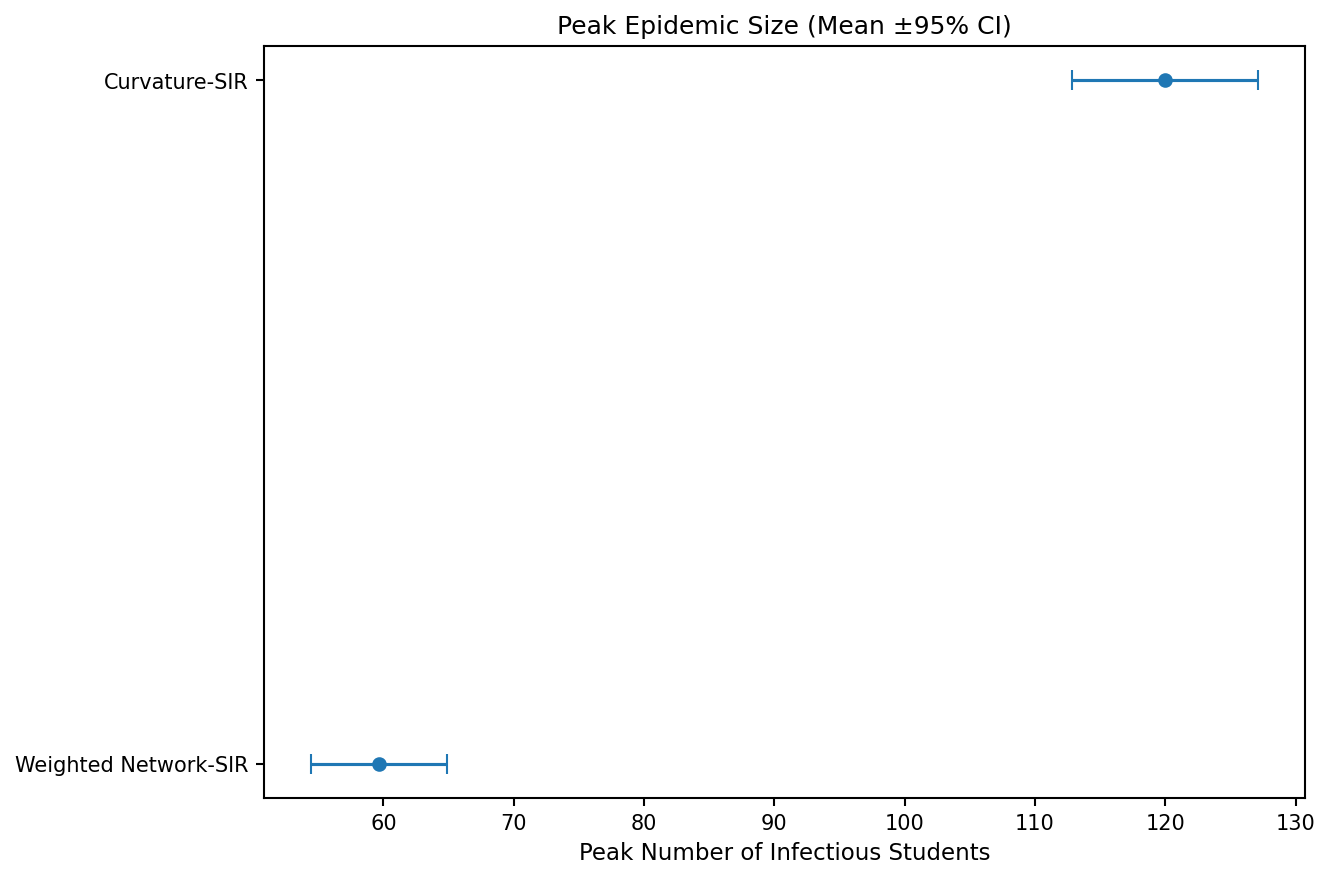

In [ ]:
# ============================================================
# STEP 6D.10
# FOREST PLOT OF ALL METRICS
# ============================================================

forest = summary_table[
    summary_table["Metric"] == "Peak_Infected"
]

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150
)

y = np.arange(len(forest))

means = forest["Mean"]

lower = forest["CI95_Lower"]

upper = forest["CI95_Upper"]

ax.errorbar(
    means,
    y,
    xerr=[means - lower, upper - means],
    fmt='o',
    capsize=5
)

ax.set_yticks(y)

ax.set_yticklabels(forest["Model"])

ax.set_xlabel("Peak Number of Infectious Students")

ax.set_title("Peak Epidemic Size (Mean ±95% CI)")

#ax.grid(alpha=0.3)

# ------------------------------------------------------------
# BOXED AXES (The Rectangle Effect)
# ------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    direction="out",
    length=4,
    width=1.0,
    colors="black"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Forest.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 6D.11
# EXPORT ALL STATISTICAL TABLES
# ============================================================

mapping_peak_df.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_mapping_peak_summary.csv"
    ),
    index=False
)

alpha_summary_df.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_alpha_summary.csv"
    ),
    index=False
)

summary_table.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_full_summary.csv"
    ),
    index=False
)

print("Experiment 6D exported successfully.")

Experiment 6D exported successfully.


In [ ]:
# ============================================================
# STEP 6.18 — EXPERIMENT 6 DIAGNOSTIC REPORT
# ============================================================

print("=" * 60)
print("EXPERIMENT 6 DIAGNOSTIC REPORT")
print("=" * 60)

print("\nNETWORK")
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

print("\nCURVATURE")
print("Raw mean :", e6_F_mean)
print("Raw SD   :", e6_F_sd)

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

baseline_metrics = baseline_runs["metrics"]

print("\nBASELINE — WEIGHTED NETWORK-SIR")

print(
    "Peak I       :",
    baseline_metrics["Peak_Infected"].mean()
)

print(
    "Peak time    :",
    baseline_metrics["Peak_Time"].mean()
)

print(
    "Final size   :",
    baseline_metrics["Final_Size"].mean()
)

# ------------------------------------------------------------
# CURVATURE-SIR
# ------------------------------------------------------------

curvature_metrics = curvature_runs["metrics"]

print("\nCURVATURE-SIR")

print(
    "Peak I       :",
    curvature_metrics["Peak_Infected"].mean()
)

print(
    "Peak time    :",
    curvature_metrics["Peak_Time"].mean()
)

print(
    "Final size   :",
    curvature_metrics["Final_Size"].mean()
)

# ------------------------------------------------------------
# MAPPING CHECK
# ------------------------------------------------------------

print("\nMAPPING CHECK")

print(
    e6_mapping_check[
        [
            "Mapping",
            "Mean",
            "SD",
            "Min",
            "Max"
        ]
    ]
)

# ------------------------------------------------------------
# ALPHA = 0 BASELINE RECOVERY
# ------------------------------------------------------------

print("\nALPHA = 0 BASELINE CHECK")

alpha0_metrics = alpha_results[0.0]["metrics"]

metrics_to_check = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

for metric in metrics_to_check:

    alpha0_values = alpha0_metrics[metric].to_numpy()
    baseline_values = baseline_metrics[metric].to_numpy()

    max_difference = np.max(
        np.abs(alpha0_values - baseline_values)
    )

    print(
        f"{metric:15s}: "
        f"max difference = {max_difference:.6g}"
    )

print("\n" + "=" * 60)
print("EXPERIMENT 6 COMPLETE")
print("=" * 60)

EXPERIMENT 6 DIAGNOSTIC REPORT

NETWORK
Nodes : 327
Edges : 5818

CURVATURE
Raw mean : -154.28290600754212
Raw SD   : 212.52337017444597

BASELINE — WEIGHTED NETWORK-SIR
Peak I       : 59.68
Peak time    : 36.2
Final size   : 202.995

CURVATURE-SIR
Peak I       : 119.955
Peak time    : 27.095
Final size   : 271.86

MAPPING CHECK
                     Mapping      Mean        SD           Min       Max
0      mapping_uniform_value  1.000000  0.000000  1.000000e+00  1.000000
1       mapping_linear_value  6.139092  2.656484  5.401281e-06  9.073410
2  mapping_exponential_value  4.668532  1.874858  1.672184e-05  7.403575
3   mapping_saturating_value  5.272055  2.110508  1.854866e-10  7.427864

ALPHA = 0 BASELINE CHECK
Peak_Infected  : max difference = 0
Peak_Time      : max difference = 0
Final_Size     : max difference = 0
Duration       : max difference = 0

EXPERIMENT 6 COMPLETE


### Control 1A — Endpoint-strength control

In [ ]:
# ============================================================
# STEP 6E.1
# ENDPOINT-STRENGTH CONTROL — COMPUTE NODE STRENGTH
# ============================================================

# For the weighted empirical network:
#
#     s_i = sum_j w_ij
#
# where s_i is the weighted degree (node strength).
#
# The endpoint-strength statistic for edge (i,j) is:
#
#     S_ij = s_i + s_j
#
# This provides a simpler local structural control for the
# curvature-based transmission modifier.

node_strength = {
    node: float(
        G.degree(
            node,
            weight=E6_WEIGHT_ATTR
        )
    )
    for node in G.nodes()
}

print(
    "Endpoint-strength control"
)
print("=" * 60)

print(
    f"Number of nodes : {G.number_of_nodes()}"
)

print(
    f"Number of edges : {G.number_of_edges()}"
)

print(
    f"Minimum strength: "
    f"{min(node_strength.values()):.6f}"
)

print(
    f"Maximum strength: "
    f"{max(node_strength.values()):.6f}"
)

print(
    f"Mean strength   : "
    f"{np.mean(list(node_strength.values())):.6f}"
)

Endpoint-strength control
Number of nodes : 327
Number of edges : 5818
Minimum strength: 0.002374
Maximum strength: 1.575788
Mean strength   : 0.390964


In [ ]:
# ============================================================
# STEP 6E.2
# ENDPOINT-STRENGTH CONTROL — EDGE-LEVEL STATISTIC
# ============================================================

endpoint_strength_values = np.array(
    [
        node_strength[u] + node_strength[v]
        for u, v in G.edges()
    ],
    dtype=float
)

print(
    "ENDPOINT-STRENGTH EDGE STATISTIC"
)

print("=" * 60)

print(
    f"Minimum S_ij : "
    f"{endpoint_strength_values.min():.6f}"
)

print(
    f"Maximum S_ij : "
    f"{endpoint_strength_values.max():.6f}"
)

print(
    f"Mean S_ij    : "
    f"{endpoint_strength_values.mean():.6f}"
)

print(
    f"SD S_ij      : "
    f"{endpoint_strength_values.std(ddof=1):.6f}"
)

ENDPOINT-STRENGTH EDGE STATISTIC
Minimum S_ij : 0.054256
Maximum S_ij : 2.978298
Mean S_ij    : 0.891946
SD S_ij      : 0.444793


In [ ]:
# ============================================================
# STEP 6E.3
# ENDPOINT-STRENGTH CONTROL — STANDARDIZATION
# ============================================================

S_mean = endpoint_strength_values.mean()

S_sd = endpoint_strength_values.std(
    ddof=1
)

if S_sd <= 0:
    raise RuntimeError(
        "Endpoint-strength statistic has zero variance."
    )

endpoint_strength_std = (
    endpoint_strength_values - S_mean
) / S_sd

print(
    "ENDPOINT-STRENGTH STANDARDIZATION CHECK"
)

print("=" * 60)

print(
    f"Mean standardized S_ij : "
    f"{endpoint_strength_std.mean():.12f}"
)

print(
    f"SD standardized S_ij   : "
    f"{endpoint_strength_std.std(ddof=1):.12f}"
)

if not np.isclose(
    endpoint_strength_std.mean(),
    0.0,
    atol=1e-10
):
    raise RuntimeError(
        "Standardized endpoint strength "
        "does not have mean zero."
    )

if not np.isclose(
    endpoint_strength_std.std(ddof=1),
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Standardized endpoint strength "
        "does not have unit variance."
    )

print(
    "✓ Endpoint-strength standardization verified."
)

ENDPOINT-STRENGTH STANDARDIZATION CHECK
Mean standardized S_ij : -0.000000000000
SD standardized S_ij   : 1.000000000000
✓ Endpoint-strength standardization verified.


In [ ]:
# ============================================================
# STEP 6E.3B — FRC VS ENDPOINT-STRENGTH ASSOCIATION
# ============================================================

from scipy.stats import pearsonr, spearmanr

edge_strength_sum = []

edge_frc = []

for u, v, d in G.edges(data=True):

    s_u = node_strength[u]
    s_v = node_strength[v]

    edge_strength_sum.append(
        s_u + s_v
    )

    edge_frc.append(
        float(d["curvature_std"])
    )

edge_strength_sum = np.asarray(
    edge_strength_sum,
    dtype=float
)

edge_frc = np.asarray(
    edge_frc,
    dtype=float
)

pearson_r, pearson_p = pearsonr(
    edge_strength_sum,
    edge_frc
)

spearman_r, spearman_p = spearmanr(
    edge_strength_sum,
    edge_frc
)

print(
    "FRC VS ENDPOINT-STRENGTH ASSOCIATION"
)

print("=" * 60)

print(
    f"Pearson r       : {pearson_r:.6f}"
)

print(
    f"Pearson p-value : {pearson_p:.6e}"
)

print(
    f"Spearman rho    : {spearman_r:.6f}"
)

print(
    f"Spearman p-value: {spearman_p:.6e}"
)

FRC VS ENDPOINT-STRENGTH ASSOCIATION
Pearson r       : -0.245638
Pearson p-value : 1.071082e-80
Spearman rho    : -0.222427
Spearman p-value: 3.897022e-66


In [ ]:
# ============================================================
# STEP 6E.4 — DIRECTION-MATCHED ENDPOINT-STRENGTH MODIFIER
# ============================================================

# The FRC exponential mapping is:
#
#     g(F) = exp(alpha * F)
#
# Conceptual distinction:
#
# For unweighted graphs:
#
#     F_ij = 4 - d_i - d_j
#
# so an endpoint-degree-sum control is especially important
# for the synthetic unweighted networks.
#
# For the empirical weighted network, endpoint strength
# provides a weighted local-statistic control:
#
#     S_ij = s_i + s_j
#
# The exact endpoint-degree control is implemented separately.
#
# To construct a direction-matched endpoint-strength control,
# we therefore use:
#
#     g(S_ij) = exp(-alpha * S_ij_std)
#
# where S_ij = s_i + s_j.

g_strength = np.exp(
    -E6_ALPHA_MAIN * endpoint_strength_std
)

print(
    "DIRECTION-MATCHED ENDPOINT-STRENGTH MODIFIER"
)

print("=" * 60)

print(
    f"Alpha                 : "
    f"{E6_ALPHA_MAIN:.2f}"
)

print(
    f"Raw modifier mean     : "
    f"{g_strength.mean():.6f}"
)

print(
    f"Raw modifier minimum  : "
    f"{g_strength.min():.6f}"
)

print(
    f"Raw modifier maximum  : "
    f"{g_strength.max():.6f}"
)

DIRECTION-MATCHED ENDPOINT-STRENGTH MODIFIER
Alpha                 : 1.00
Raw modifier mean     : 1.480960
Raw modifier minimum  : 0.009181
Raw modifier maximum  : 6.575325


In [ ]:
# ============================================================
# STEP 6E.5
# ENDPOINT-STRENGTH CONTROL — CONTACT-WEIGHTED NORMALIZATION
# ============================================================

control_weights = np.array(
    [
        float(
            d[E6_WEIGHT_ATTR]
        )
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

if np.any(control_weights < 0):
    raise ValueError(
        "Edge weights must be non-negative."
    )

if np.sum(control_weights) <= 0:
    raise ValueError(
        "Total contact weight must be positive."
    )

# Reuse the same normalization principle as the FRC model.
strength_weighted_mean = np.sum(
    control_weights * g_strength
) / np.sum(control_weights)

if strength_weighted_mean <= 0:
    raise RuntimeError(
        "Endpoint-strength modifier has "
        "non-positive weighted mean."
    )

g_strength_normalized = (
    g_strength / strength_weighted_mean
)

# Verify
strength_weighted_mean_after = np.sum(
    control_weights * g_strength_normalized
) / np.sum(control_weights)

print(
    "ENDPOINT-STRENGTH NORMALIZATION CHECK"
)

print("=" * 60)

print(
    f"Before normalization : "
    f"{strength_weighted_mean:.12f}"
)

print(
    f"After normalization  : "
    f"{strength_weighted_mean_after:.12f}"
)

print(
    f"Unweighted mean      : "
    f"{g_strength_normalized.mean():.12f}"
)

if not np.isclose(
    strength_weighted_mean_after,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Endpoint-strength modifier does not "
        "have contact-weighted mean equal to one."
    )

print(
    "✓ Endpoint-strength contact-weighted "
    "normalization verified."
)

ENDPOINT-STRENGTH NORMALIZATION CHECK
Before normalization : 0.897673302432
After normalization  : 1.000000000000
Unweighted mean      : 1.649775914813
✓ Endpoint-strength contact-weighted normalization verified.


In [ ]:
# ============================================================
# STEP 6E.6
# STORE ENDPOINT-STRENGTH CONTROL ON EDGES
# ============================================================

for idx, (u, v, d) in enumerate(
    G.edges(data=True)
):

    normalized_modifier = float(
        g_strength_normalized[idx]
    )

    d["strength_control_value"] = (
        normalized_modifier
    )

    # The simulator exponentiates this attribute.
    d["strength_control"] = np.log(
        max(
            normalized_modifier,
            E6_EPSILON
        )
    )

print(
    "✓ Endpoint-strength control stored on edges."
)

✓ Endpoint-strength control stored on edges.


In [ ]:
# ============================================================
# STEP 6E.7
# VERIFY ENDPOINT-STRENGTH TRANSMISSION KERNEL
# ============================================================

uniform_total = 0.0
strength_total = 0.0

for _, _, d in G.edges(data=True):

    w = float(
        d[E6_WEIGHT_ATTR]
    )

    g_strength_actual = np.exp(
        float(
            d["strength_control"]
        )
    )

    uniform_total += w

    strength_total += (
        w * g_strength_actual
    )

strength_ratio = (
    strength_total
    / uniform_total
)

print(
    "ENDPOINT-STRENGTH TRANSMISSION-KERNEL CHECK"
)

print("=" * 60)

print(
    f"Uniform weighted total  : "
    f"{uniform_total:.12f}"
)

print(
    f"Strength weighted total : "
    f"{strength_total:.12f}"
)

print(
    f"Ratio (Strength / Uniform): "
    f"{strength_ratio:.12f}"
)

if not np.isclose(
    strength_ratio,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Endpoint-strength transmission kernel "
        "does not preserve weighted transmission scale."
    )

print(
    "✓ Endpoint-strength transmission kernel "
    "preserves the weighted transmission scale."
)

ENDPOINT-STRENGTH TRANSMISSION-KERNEL CHECK
Uniform weighted total  : 63.922685656156
Strength weighted total : 63.922685656155
Ratio (Strength / Uniform): 1.000000000000
✓ Endpoint-strength transmission kernel preserves the weighted transmission scale.


In [ ]:
# ============================================================
# STEP 6E.8
# RUN ENDPOINT-STRENGTH CONTROL ENSEMBLE
# ============================================================

strength_control_runs = (
    run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr="strength_control",
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )
)

print(
    "Endpoint-strength control runs:",
    len(
        strength_control_runs["metrics"]
    )
)

Endpoint-strength control runs: 200


### Control 1B — Endpoint-degree control

In [ ]:
# ============================================================
# STEP 6G.1
# ENDPOINT-DEGREE CONTROL — COMPUTE NODE DEGREE
# ============================================================

node_degree = {
    node: float(G.degree(node))
    for node in G.nodes()
}

endpoint_degree_values = np.array(
    [
        node_degree[u] + node_degree[v]
        for u, v in G.edges()
    ],
    dtype=float
)

print("ENDPOINT-DEGREE CONTROL")
print("=" * 60)
print(f"Number of nodes : {G.number_of_nodes()}")
print(f"Number of edges : {G.number_of_edges()}")
print(f"Minimum D_ij   : {endpoint_degree_values.min():.6f}")
print(f"Maximum D_ij   : {endpoint_degree_values.max():.6f}")
print(f"Mean D_ij      : {endpoint_degree_values.mean():.6f}")
print(f"SD D_ij        : {endpoint_degree_values.std(ddof=1):.6f}")


ENDPOINT-DEGREE CONTROL
Number of nodes : 327
Number of edges : 5818
Minimum D_ij   : 20.000000
Maximum D_ij   : 163.000000
Mean D_ij      : 81.407700
SD D_ij        : 19.714321


In [ ]:
# ============================================================
# STEP 6G.2
# ENDPOINT-DEGREE CONTROL — STANDARDIZATION
# ============================================================

D_mean = endpoint_degree_values.mean()
D_sd = endpoint_degree_values.std(ddof=1)

if D_sd <= 0:
    raise RuntimeError(
        "Endpoint-degree statistic has zero variance."
    )

endpoint_degree_std = (
    endpoint_degree_values - D_mean
) / D_sd

print("ENDPOINT-DEGREE STANDARDIZATION CHECK")
print("=" * 60)
print(
    f"Mean standardized D_ij : "
    f"{endpoint_degree_std.mean():.12f}"
)
print(
    f"SD standardized D_ij   : "
    f"{endpoint_degree_std.std(ddof=1):.12f}"
)

if not np.isclose(endpoint_degree_std.mean(), 0.0, atol=1e-10):
    raise RuntimeError(
        "Standardized endpoint degree does not have mean zero."
    )

if not np.isclose(endpoint_degree_std.std(ddof=1), 1.0, atol=1e-10):
    raise RuntimeError(
        "Standardized endpoint degree does not have unit variance."
    )

print("✓ Endpoint-degree standardization verified.")


ENDPOINT-DEGREE STANDARDIZATION CHECK
Mean standardized D_ij : -0.000000000000
SD standardized D_ij   : 1.000000000000
✓ Endpoint-degree standardization verified.


In [ ]:
# ============================================================
# STEP 6G.3
# ENDPOINT-DEGREE CONTROL — FRC ASSOCIATION
# ============================================================

edge_frc = np.array(
    [
        float(d["curvature_std"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

pearson_frc_degree_raw, pearson_frc_degree_raw_p = pearsonr(
    endpoint_degree_values,
    edge_frc
)

spearman_frc_degree_raw, spearman_frc_degree_raw_p = spearmanr(
    endpoint_degree_values,
    edge_frc
)

print("FRC VS ENDPOINT-DEGREE ASSOCIATION")
print("=" * 60)
print(f"Pearson r       : {pearson_frc_degree_raw:.6f}")
print(f"Pearson p-value : {pearson_frc_degree_raw_p:.6e}")
print(f"Spearman rho    : {spearman_frc_degree_raw:.6f}")
print(f"Spearman p-value: {spearman_frc_degree_raw_p:.6e}")


FRC VS ENDPOINT-DEGREE ASSOCIATION
Pearson r       : -0.188505
Pearson p-value : 1.117940e-47
Spearman rho    : -0.343921
Spearman p-value: 3.177448e-161


In [ ]:
# ============================================================
# STEP 6G.4
# ENDPOINT-DEGREE CONTROL — DIRECTION-MATCHED MODIFIER
# ============================================================

# For unweighted networks:
#
#     F_ij = 4 - d_i - d_j
#
# Therefore increasing endpoint degree corresponds to decreasing
# FRC and hence a decreasing exp(alpha * F) modifier.

g_degree = np.exp(
    -E6_ALPHA_MAIN * endpoint_degree_std
)

print("DIRECTION-MATCHED ENDPOINT-DEGREE MODIFIER")
print("=" * 60)
print(f"Alpha                : {E6_ALPHA_MAIN:.2f}")
print(f"Raw modifier mean    : {g_degree.mean():.6f}")
print(f"Raw modifier minimum : {g_degree.min():.6f}")
print(f"Raw modifier maximum : {g_degree.max():.6f}")


DIRECTION-MATCHED ENDPOINT-DEGREE MODIFIER
Alpha                : 1.00
Raw modifier mean    : 1.567478
Raw modifier minimum : 0.015943
Raw modifier maximum : 22.530677


In [ ]:
# ============================================================
# STEP 6G.5
# ENDPOINT-DEGREE CONTROL — CONTACT-WEIGHTED NORMALIZATION
# ============================================================

control_weights = np.array(
    [
        float(d[E6_WEIGHT_ATTR])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

if np.any(control_weights < 0):
    raise ValueError("Edge weights must be non-negative.")

if np.sum(control_weights) <= 0:
    raise ValueError("Total contact weight must be positive.")

degree_weighted_mean = (
    np.sum(control_weights * g_degree)
    /
    np.sum(control_weights)
)

if degree_weighted_mean <= 0:
    raise RuntimeError(
        "Endpoint-degree modifier has non-positive weighted mean."
    )

g_degree_normalized = (
    g_degree / degree_weighted_mean
)

degree_weighted_mean_after = (
    np.sum(
        control_weights * g_degree_normalized
    )
    /
    np.sum(control_weights)
)

print("ENDPOINT-DEGREE NORMALIZATION CHECK")
print("=" * 60)
print(f"Before normalization : {degree_weighted_mean:.12f}")
print(f"After normalization  : {degree_weighted_mean_after:.12f}")
print(f"Unweighted mean      : {g_degree_normalized.mean():.12f}")

if not np.isclose(
    degree_weighted_mean_after,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Endpoint-degree modifier does not have "
        "contact-weighted mean equal to one."
    )

print(
    "✓ Endpoint-degree contact-weighted normalization verified."
)


ENDPOINT-DEGREE NORMALIZATION CHECK
Before normalization : 1.600260398089
After normalization  : 1.000000000000
Unweighted mean      : 0.979514515788
✓ Endpoint-degree contact-weighted normalization verified.


In [ ]:
# ============================================================
# STEP 6G.6
# ENDPOINT-DEGREE CONTROL — STORE ON EDGES
# ============================================================

for idx, (u, v, d) in enumerate(
    G.edges(data=True)
):

    normalized_modifier = float(
        g_degree_normalized[idx]
    )

    d["degree_control_value"] = normalized_modifier

    # The simulator exponentiates this attribute.
    # Therefore store log(modifier).
    d["degree_control"] = np.log(
        max(
            normalized_modifier,
            E6_EPSILON
        )
    )

print("✓ Endpoint-degree control stored on edges.")


✓ Endpoint-degree control stored on edges.


In [ ]:
# ============================================================
# STEP 6G.7
# ENDPOINT-DEGREE CONTROL — TRANSMISSION-KERNEL CHECK
# ============================================================

uniform_total = 0.0
degree_total = 0.0

for _, _, d in G.edges(data=True):

    w = float(d[E6_WEIGHT_ATTR])

    g_degree_actual = np.exp(
        float(d["degree_control"])
    )

    uniform_total += w
    degree_total += w * g_degree_actual

degree_ratio = degree_total / uniform_total

print("ENDPOINT-DEGREE TRANSMISSION-KERNEL CHECK")
print("=" * 60)
print(f"Uniform weighted total : {uniform_total:.12f}")
print(f"Degree weighted total  : {degree_total:.12f}")
print(f"Ratio (Degree / Uniform): {degree_ratio:.12f}")

if not np.isclose(
    degree_ratio,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Endpoint-degree transmission kernel does not "
        "preserve weighted transmission scale."
    )

print(
    "✓ Endpoint-degree transmission kernel preserves "
    "the weighted transmission scale."
)


ENDPOINT-DEGREE TRANSMISSION-KERNEL CHECK
Uniform weighted total : 63.922685656156
Degree weighted total  : 63.922685656155
Ratio (Degree / Uniform): 1.000000000000
✓ Endpoint-degree transmission kernel preserves the weighted transmission scale.


In [ ]:
# ============================================================
# STEP 6G.8
# RUN ENDPOINT-DEGREE CONTROL ENSEMBLE
# ============================================================

degree_control_runs = (
    run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr="degree_control",
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )
)

print(
    "Endpoint-degree control runs:",
    len(degree_control_runs["metrics"])
)

if len(degree_control_runs["metrics"]) != E6_N_RUNS:
    raise RuntimeError(
        "Endpoint-degree control did not produce "
        "the requested number of runs."
    )

print("✓ Endpoint-degree control ensemble completed.")


Endpoint-degree control runs: 200
✓ Endpoint-degree control ensemble completed.


### Control 2 — Shuffled-FRC control

In [ ]:
# ============================================================
# STEP 6F.1
# SHUFFLED-FRC CONTROL — EXTRACT STANDARDIZED CURVATURE
# ============================================================

F_std = np.array(
    [
        float(
            d["curvature_std"]
        )
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

print(
    "STANDARDIZED FRC FOR SHUFFLING"
)

print("=" * 60)

print(
    f"Mean : "
    f"{F_std.mean():.12f}"
)

print(
    f"SD   : "
    f"{F_std.std(ddof=1):.12f}"
)

if not np.isclose(
    F_std.mean(),
    0.0,
    atol=1e-10
):
    raise RuntimeError(
        "Stored standardized curvature "
        "does not have mean zero."
    )

print(
    "✓ Standardized curvature verified."
)

STANDARDIZED FRC FOR SHUFFLING
Mean : 0.000000000000
SD   : 1.000000000000
✓ Standardized curvature verified.


In [ ]:
# ============================================================
# STEP 6F.2
# SHUFFLED-FRC CONTROL — PERMUTE CURVATURE VALUES
# ============================================================

E6_SHUFFLE_SEED = (
    int(E6_SEED0) + 1000
)

rng_shuffle = np.random.default_rng(
    E6_SHUFFLE_SEED
)

F_shuffle = rng_shuffle.permutation(
    F_std
)

print(
    "SHUFFLED-FRC CONTROL"
)

print("=" * 60)

print(
    f"Shuffle seed : "
    f"{E6_SHUFFLE_SEED}"
)

print(
    f"Original mean: "
    f"{F_std.mean():.12f}"
)

print(
    f"Shuffled mean: "
    f"{F_shuffle.mean():.12f}"
)

print(
    f"Original SD  : "
    f"{F_std.std(ddof=1):.12f}"
)

print(
    f"Shuffled SD  : "
    f"{F_shuffle.std(ddof=1):.12f}"
)

if not np.allclose(
    np.sort(F_std),
    np.sort(F_shuffle)
):
    raise RuntimeError(
        "Shuffling changed the FRC value distribution."
    )

print(
    "✓ FRC distribution preserved exactly."
)

SHUFFLED-FRC CONTROL
Shuffle seed : 20261907
Original mean: 0.000000000000
Shuffled mean: 0.000000000000
Original SD  : 1.000000000000
Shuffled SD  : 1.000000000000
✓ FRC distribution preserved exactly.


In [ ]:
# ============================================================
# STEP 6F.3
# SHUFFLED-FRC CONTROL — EXPONENTIAL MODIFIER
# ============================================================

g_shuffle = np.exp(
    float(E6_ALPHA_MAIN)
    * F_shuffle
)

print(
    "RAW SHUFFLED-FRC EXPONENTIAL MODIFIER"
)

print("=" * 60)

print(
    f"Alpha          : "
    f"{E6_ALPHA_MAIN:.2f}"
)

print(
    f"Minimum g      : "
    f"{g_shuffle.min():.6f}"
)

print(
    f"Maximum g      : "
    f"{g_shuffle.max():.6f}"
)

print(
    f"Unweighted mean: "
    f"{g_shuffle.mean():.6f}"
)

RAW SHUFFLED-FRC EXPONENTIAL MODIFIER
Alpha          : 1.00
Minimum g      : 0.000004
Maximum g      : 1.973607
Unweighted mean: 1.244513


In [ ]:
# ============================================================
# STEP 6F.4
# SHUFFLED-FRC CONTROL — CONTACT-WEIGHTED NORMALIZATION
# ============================================================

shuffle_weighted_mean = (
    np.sum(
        control_weights
        * g_shuffle
    )
    / np.sum(control_weights)
)

if shuffle_weighted_mean <= 0:
    raise RuntimeError(
        "Shuffled-FRC modifier has "
        "non-positive weighted mean."
    )

g_shuffle_normalized = (
    g_shuffle
    / shuffle_weighted_mean
)

shuffle_weighted_mean_after = (
    np.sum(
        control_weights
        * g_shuffle_normalized
    )
    / np.sum(control_weights)
)

print(
    "SHUFFLED-FRC NORMALIZATION CHECK"
)

print("=" * 60)

print(
    f"Before normalization : "
    f"{shuffle_weighted_mean:.12f}"
)

print(
    f"After normalization  : "
    f"{shuffle_weighted_mean_after:.12f}"
)

print(
    f"Unweighted mean      : "
    f"{g_shuffle_normalized.mean():.12f}"
)

if not np.isclose(
    shuffle_weighted_mean_after,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Shuffled-FRC modifier does not "
        "have contact-weighted mean equal to one."
    )

print(
    "✓ Shuffled-FRC contact-weighted "
    "normalization verified."
)

SHUFFLED-FRC NORMALIZATION CHECK
Before normalization : 1.235299029872
After normalization  : 1.000000000000
Unweighted mean      : 1.007459060011
✓ Shuffled-FRC contact-weighted normalization verified.


In [ ]:
# ============================================================
# STEP 6F.5
# STORE SHUFFLED-FRC CONTROL ON EDGES
# ============================================================

for idx, (u, v, d) in enumerate(
    G.edges(data=True)
):

    normalized_modifier = float(
        g_shuffle_normalized[idx]
    )

    d["shuffled_frc_value"] = (
        normalized_modifier
    )

    # Existing simulator expects the log modifier.
    d["shuffled_frc"] = np.log(
        max(
            normalized_modifier,
            E6_EPSILON
        )
    )

print(
    "✓ Shuffled-FRC control stored on edges."
)

✓ Shuffled-FRC control stored on edges.


In [ ]:
# ============================================================
# STEP 6F.6
# VERIFY SHUFFLED-FRC TRANSMISSION KERNEL
# ============================================================

uniform_total = 0.0
shuffled_total = 0.0

for _, _, d in G.edges(data=True):

    w = float(
        d[E6_WEIGHT_ATTR]
    )

    g_shuffle_actual = np.exp(
        float(
            d["shuffled_frc"]
        )
    )

    uniform_total += w

    shuffled_total += (
        w * g_shuffle_actual
    )

shuffled_ratio = (
    shuffled_total
    / uniform_total
)

print(
    "SHUFFLED-FRC TRANSMISSION-KERNEL CHECK"
)

print("=" * 60)

print(
    f"Uniform weighted total  : "
    f"{uniform_total:.12f}"
)

print(
    f"Shuffled weighted total : "
    f"{shuffled_total:.12f}"
)

print(
    f"Ratio (Shuffled / Uniform): "
    f"{shuffled_ratio:.12f}"
)

if not np.isclose(
    shuffled_ratio,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Shuffled-FRC transmission kernel "
        "does not preserve weighted transmission scale."
    )

print(
    "✓ Shuffled-FRC transmission kernel "
    "preserves the weighted transmission scale."
)

SHUFFLED-FRC TRANSMISSION-KERNEL CHECK
Uniform weighted total  : 63.922685656156
Shuffled weighted total : 63.922685656154
Ratio (Shuffled / Uniform): 1.000000000000
✓ Shuffled-FRC transmission kernel preserves the weighted transmission scale.


In [ ]:
# ============================================================
# STEP 6F.7
# RUN SHUFFLED-FRC CONTROL ENSEMBLE
# ============================================================

shuffled_frc_runs = (
    run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr="shuffled_frc",
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )
)

print(
    "Shuffled-FRC control runs:",
    len(
        shuffled_frc_runs["metrics"]
    )
)

Shuffled-FRC control runs: 200


In [ ]:
# ============================================================
# DIAGNOSTIC — CHECK ALL ENSEMBLE OUTPUT STRUCTURES
# ============================================================

paired_ensembles = {
    "baseline_runs": baseline_runs,
    "curvature_runs": curvature_runs,
    "strength_control_runs": strength_control_runs,
    "degree_control_runs": degree_control_runs,
    "shuffled_frc_runs": shuffled_frc_runs
}

for name, results in paired_ensembles.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Result keys:", list(results.keys()))
    print("Metric columns:", results["metrics"].columns.tolist())
    print("Number of runs:", len(results["metrics"]))

    display(
        results["metrics"].head(1)
    )



baseline_runs
Result keys: ['metrics', 'infected_curves', 'beta0', 'gamma', 'weight_attr', 'curvature_attr', 'Hit_Max_Steps', 'Run_ID', 'Seed', 'Initial_Infected']
Metric columns: ['Run_ID', 'Seed', 'Initial_Infected', 'Peak_Infected', 'Peak_Time', 'Final_Size', 'Duration', 'Hit_Max_Steps']
Number of runs: 200


,Run_ID,Seed,Initial_Infected,Peak_Infected,Peak_Time,Final_Size,Duration,Hit_Max_Steps
0,1,20260907,21,1.0,0.0,1.0,2,False



curvature_runs
Result keys: ['metrics', 'infected_curves', 'beta0', 'gamma', 'weight_attr', 'curvature_attr', 'Hit_Max_Steps', 'Run_ID', 'Seed', 'Initial_Infected']
Metric columns: ['Run_ID', 'Seed', 'Initial_Infected', 'Peak_Infected', 'Peak_Time', 'Final_Size', 'Duration', 'Hit_Max_Steps']
Number of runs: 200


,Run_ID,Seed,Initial_Infected,Peak_Infected,Peak_Time,Final_Size,Duration,Hit_Max_Steps
0,1,20260907,21,137.0,36.0,317.0,119,False



strength_control_runs
Result keys: ['metrics', 'infected_curves', 'beta0', 'gamma', 'weight_attr', 'curvature_attr', 'Hit_Max_Steps', 'Run_ID', 'Seed', 'Initial_Infected']
Metric columns: ['Run_ID', 'Seed', 'Initial_Infected', 'Peak_Infected', 'Peak_Time', 'Final_Size', 'Duration', 'Hit_Max_Steps']
Number of runs: 200


,Run_ID,Seed,Initial_Infected,Peak_Infected,Peak_Time,Final_Size,Duration,Hit_Max_Steps
0,1,20260907,21,1.0,0.0,1.0,2,False



degree_control_runs
Result keys: ['metrics', 'infected_curves', 'beta0', 'gamma', 'weight_attr', 'curvature_attr', 'Hit_Max_Steps', 'Run_ID', 'Seed', 'Initial_Infected']
Metric columns: ['Run_ID', 'Seed', 'Initial_Infected', 'Peak_Infected', 'Peak_Time', 'Final_Size', 'Duration', 'Hit_Max_Steps']
Number of runs: 200


,Run_ID,Seed,Initial_Infected,Peak_Infected,Peak_Time,Final_Size,Duration,Hit_Max_Steps
0,1,20260907,21,1.0,0.0,1.0,2,False



shuffled_frc_runs
Result keys: ['metrics', 'infected_curves', 'beta0', 'gamma', 'weight_attr', 'curvature_attr', 'Hit_Max_Steps', 'Run_ID', 'Seed', 'Initial_Infected']
Metric columns: ['Run_ID', 'Seed', 'Initial_Infected', 'Peak_Infected', 'Peak_Time', 'Final_Size', 'Duration', 'Hit_Max_Steps']
Number of runs: 200


,Run_ID,Seed,Initial_Infected,Peak_Infected,Peak_Time,Final_Size,Duration,Hit_Max_Steps
0,1,20260907,21,1.0,0.0,1.0,2,False


In [ ]:
# ============================================================
# DIAGNOSTIC — VERIFY PAIRED ENSEMBLE METADATA
# ============================================================

reference_metrics = (
    baseline_runs["metrics"]
    .sort_values("Run_ID")
    .reset_index(drop=True)
)

for name, results in paired_ensembles.items():

    metrics = (
        results["metrics"]
        .sort_values("Run_ID")
        .reset_index(drop=True)
    )

    if not np.array_equal(
        metrics["Run_ID"].to_numpy(),
        reference_metrics["Run_ID"].to_numpy()
    ):
        raise RuntimeError(
            f"{name}: Run_ID values are not aligned."
        )

    if not np.array_equal(
        metrics["Seed"].to_numpy(),
        reference_metrics["Seed"].to_numpy()
    ):
        raise RuntimeError(
            f"{name}: Seed values are not aligned."
        )

    if "Initial_Infected" in reference_metrics.columns:

        if "Initial_Infected" not in metrics.columns:
            raise RuntimeError(
                f"{name}: Initial_Infected column is missing."
            )

        if not np.array_equal(
            metrics["Initial_Infected"].to_numpy(),
            reference_metrics["Initial_Infected"].to_numpy()
        ):
            raise RuntimeError(
                f"{name}: Initial_Infected values are not aligned."
            )

print(
    "✓ All five model conditions have aligned Run_ID and Seed sequences."
)

if "Initial_Infected" in reference_metrics.columns:
    print(
        "✓ All five model conditions also have aligned Initial_Infected nodes."
    )
else:
    print(
        "⚠ Initial_Infected is not yet present; rerun after the revised Cell 30."
    )


✓ All five model conditions have aligned Run_ID and Seed sequences.
✓ All five model conditions also have aligned Initial_Infected nodes.


In [ ]:
# ============================================================
# STEP 6F.8A — VERIFY METRIC COLUMNS
# ============================================================

required_metric_columns = [
    "Run_ID",
    "Seed",
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration",
    "Hit_Max_Steps"
]

for name, results in paired_ensembles.items():

    missing = [
        col
        for col in required_metric_columns
        if col not in results["metrics"].columns
    ]

    if missing:
        raise RuntimeError(
            f"{name} is missing metric columns: {missing}"
        )

    print(
        f"{name:28s}: "
        f"{len(results['metrics'])} runs; "
        f"{len(results['metrics'].columns)} metric columns"
    )

print("\n✓ Required ensemble metric columns verified.")


baseline_runs               : 200 runs; 8 metric columns
curvature_runs              : 200 runs; 8 metric columns
strength_control_runs       : 200 runs; 8 metric columns
degree_control_runs         : 200 runs; 8 metric columns
shuffled_frc_runs           : 200 runs; 8 metric columns

✓ Required ensemble metric columns verified.


In [ ]:
# ============================================================
# STEP 6F.8 — CONTROL EXPERIMENT SUMMARY
# ============================================================

def summarize_control_runs(
    name,
    results
):
    """
    Summarize stochastic epidemic outcomes from the
    Experiment 6 ensemble output.

    The metrics are stored as a pandas DataFrame in:
        results["metrics"]
    """

    metrics = results["metrics"].copy()

    # --------------------------------------------------------
    # Extract outcome columns
    # --------------------------------------------------------

    peak = pd.to_numeric(
        metrics["Peak_Infected"],
        errors="coerce"
    ).dropna()

    peak_time = pd.to_numeric(
        metrics["Peak_Time"],
        errors="coerce"
    ).dropna()

    final_size = pd.to_numeric(
        metrics["Final_Size"],
        errors="coerce"
    ).dropna()

    duration = pd.to_numeric(
        metrics["Duration"],
        errors="coerce"
    ).dropna()

    # --------------------------------------------------------
    # Summary statistics
    # --------------------------------------------------------

    return {
        "Model": name,

        "Peak Mean": peak.mean(),
        "Peak SD": peak.std(ddof=1),

        "Peak Time Mean": peak_time.mean(),
        "Peak Time SD": peak_time.std(ddof=1),

        "Final Size Mean": final_size.mean(),
        "Final Size SD": final_size.std(ddof=1),

        "Duration Mean": duration.mean(),
        "Duration SD": duration.std(ddof=1),

        "N": len(peak)
    }


# ============================================================
# BUILD CONTROL SUMMARY TABLE
# ============================================================

control_summary = pd.DataFrame(
    [
        summarize_control_runs(
            "Weighted Network-SIR",
            baseline_runs
        ),

        summarize_control_runs(
            "FRC-SIR",
            curvature_runs
        ),

        summarize_control_runs(
            "Endpoint-Strength Control",
            strength_control_runs
        ),

        summarize_control_runs(
            "Endpoint-Degree Control",
            degree_control_runs
        ),

        summarize_control_runs(
            "Shuffled-FRC Control",
            shuffled_frc_runs
        )
    ]
)

display(
    control_summary
)

,Model,Peak Mean,Peak SD,Peak Time Mean,Peak Time SD,Final Size Mean,Final Size SD,Duration Mean,Duration SD,N
0,Weighted Network-SIR,59.680,37.270404,36.200,24.990450,202.995,121.028154,102.495,59.447117,200
1,FRC-SIR,119.955,51.215212,27.095,12.636232,271.860,111.712978,94.645,40.469344,200
2,Endpoint-Strength Control,77.570,39.113353,38.120,21.296556,247.715,117.618512,109.590,52.779640,200
3,Endpoint-Degree Control,30.340,22.672995,48.685,41.619789,141.805,113.141025,121.025,83.919226,200
4,Shuffled-FRC Control,56.860,37.514492,35.790,24.391198,194.855,123.114336,101.620,60.405378,200


In [ ]:
# ============================================================
# STEP 6E.9 — TRANSMISSION-MODIFIER ASSOCIATION
# ============================================================

frc_modifier = np.array(
    [
        float(d["mapping_exponential_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

strength_modifier = np.array(
    [
        float(d["strength_control_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

degree_modifier = np.array(
    [
        float(d["degree_control_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

shuffled_modifier = np.array(
    [
        float(d["shuffled_frc_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

print(
    "TRANSMISSION-MODIFIER ASSOCIATION"
)

print("=" * 60)

# ------------------------------------------------------------
# FRC vs endpoint-strength control
# ------------------------------------------------------------

pearson_frc_strength, _ = pearsonr(
    frc_modifier,
    strength_modifier
)

spearman_frc_strength, _ = spearmanr(
    frc_modifier,
    strength_modifier
)

print(
    f"FRC vs Strength — Pearson r  : "
    f"{pearson_frc_strength:.6f}"
)

print(
    f"FRC vs Strength — Spearman rho: "
    f"{spearman_frc_strength:.6f}"
)

# ------------------------------------------------------------
# FRC vs endpoint-degree control
# ------------------------------------------------------------

pearson_frc_degree, _ = pearsonr(
    frc_modifier,
    degree_modifier
)

spearman_frc_degree, _ = spearmanr(
    frc_modifier,
    degree_modifier
)

print(
    f"FRC vs Degree — Pearson r  : "
    f"{pearson_frc_degree:.6f}"
)

print(
    f"FRC vs Degree — Spearman rho: "
    f"{spearman_frc_degree:.6f}"
)

# ------------------------------------------------------------
# FRC vs shuffled-FRC
# ------------------------------------------------------------

pearson_frc_shuffle, _ = pearsonr(
    frc_modifier,
    shuffled_modifier
)

spearman_frc_shuffle, _ = spearmanr(
    frc_modifier,
    shuffled_modifier
)

print(
    f"FRC vs Shuffled — Pearson r  : "
    f"{pearson_frc_shuffle:.6f}"
)

print(
    f"FRC vs Shuffled — Spearman rho: "
    f"{spearman_frc_shuffle:.6f}"
)

TRANSMISSION-MODIFIER ASSOCIATION
FRC vs Strength — Pearson r  : 0.219947
FRC vs Strength — Spearman rho: 0.222426
FRC vs Degree — Pearson r  : 0.232686
FRC vs Degree — Spearman rho: 0.343921
FRC vs Shuffled — Pearson r  : -0.002993
FRC vs Shuffled — Spearman rho: -0.010760


In [ ]:
# ============================================================
# STEP 6E.10 — VERIFY ALL CONTROL NORMALIZATIONS
# ============================================================

# Reconstruct the empirical contact weights directly from G.
# This avoids relying on the variable `weights` being available
# from a previous cell.

control_weights = np.array(
    [
        float(d[E6_WEIGHT_ATTR])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

if np.any(control_weights < 0):
    raise ValueError(
        "Edge weights must be non-negative."
    )

if np.sum(control_weights) <= 0:
    raise ValueError(
        "Total contact weight must be positive."
    )

# ------------------------------------------------------------
# Verify contact-weighted means
# ------------------------------------------------------------

frc_weighted_mean = np.average(
    frc_modifier,
    weights=control_weights
)

strength_weighted_mean = np.average(
    strength_modifier,
    weights=control_weights
)

degree_weighted_mean = np.average(
    degree_modifier,
    weights=control_weights
)

shuffled_weighted_mean = np.average(
    shuffled_modifier,
    weights=control_weights
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    "CONTACT-WEIGHTED MODIFIER CHECK"
)

print("=" * 60)

print(
    f"Number of edges        : "
    f"{len(control_weights)}"
)

print(
    f"Total contact weight   : "
    f"{control_weights.sum():.6f}"
)

print(
    f"FRC weighted mean      : "
    f"{frc_weighted_mean:.12f}"
)

print(
    f"Strength weighted mean : "
    f"{strength_weighted_mean:.12f}"
)

print(
    f"Degree weighted mean   : "
    f"{degree_weighted_mean:.12f}"
)

print(
    f"Shuffled weighted mean : "
    f"{shuffled_weighted_mean:.12f}"
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

for name, value in [
    ("FRC", frc_weighted_mean),
    ("Endpoint-strength", strength_weighted_mean),
    ("Endpoint-degree", degree_weighted_mean),
    ("Shuffled-FRC", shuffled_weighted_mean)
]:

    if not np.isclose(
        value,
        1.0,
        atol=1e-10
    ):
        raise RuntimeError(
            f"{name} modifier is not "
            f"contact-weighted normalised: "
            f"{value:.12f}"
        )

print()
print(
    "✓ All four transmission modifiers "
    "have contact-weighted mean equal to 1."
)

CONTACT-WEIGHTED MODIFIER CHECK
Number of edges        : 5818
Total contact weight   : 63.922686
FRC weighted mean      : 1.000000000000
Strength weighted mean : 1.000000000000
Degree weighted mean   : 1.000000000000
Shuffled weighted mean : 1.000000000000

✓ All four transmission modifiers have contact-weighted mean equal to 1.


### Paired statistical comparison of epidemic outcomes

In [ ]:
# ============================================================
# STEP 6H.1
# BUILD AND VALIDATE THE PAIRED EXPERIMENTAL DATASET
# ============================================================

PAIR_METRICS = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

paired_results = {
    "Weighted Network-SIR": baseline_runs,
    "FRC-SIR": curvature_runs,
    "Endpoint-Strength Control": strength_control_runs,
    "Endpoint-Degree Control": degree_control_runs,
    "Shuffled-FRC Control": shuffled_frc_runs
}

ensemble_sizes = {
    name: len(result["metrics"])
    for name, result in paired_results.items()
}

print("ENSEMBLE SIZES")
print("=" * 60)

for name, n in ensemble_sizes.items():
    print(f"{name:30s}: {n}")

if len(set(ensemble_sizes.values())) != 1:
    raise RuntimeError(
        "All paired ensembles must contain the same number of runs."
    )

reference_metrics = (
    paired_results["Weighted Network-SIR"]["metrics"]
    .sort_values("Run_ID")
    .reset_index(drop=True)
)

for name, result in paired_results.items():

    metrics = (
        result["metrics"]
        .sort_values("Run_ID")
        .reset_index(drop=True)
    )

    for col in ["Run_ID", "Seed"]:

        if not np.array_equal(
            metrics[col].to_numpy(),
            reference_metrics[col].to_numpy()
        ):
            raise RuntimeError(
                f"{name}: {col} values are not aligned."
            )

    if "Initial_Infected" in reference_metrics.columns:

        if "Initial_Infected" not in metrics.columns:
            raise RuntimeError(
                f"{name}: Initial_Infected column is missing."
            )

        if not np.array_equal(
            metrics["Initial_Infected"].to_numpy(),
            reference_metrics["Initial_Infected"].to_numpy()
        ):
            raise RuntimeError(
                f"{name}: Initial_Infected values are not aligned."
            )

for name, result in paired_results.items():

    n_truncated = int(
        result["metrics"]["Hit_Max_Steps"].sum()
    )

    print(
        f"{name:30s} truncated runs: {n_truncated}"
    )

    if n_truncated > 0:
        raise RuntimeError(
            f"{name} contains truncated simulations."
        )

print()
print("✓ All five model conditions have aligned paired replicates.")

if "Initial_Infected" in reference_metrics.columns:
    print("✓ Run_ID, Seed, and Initial_Infected are aligned.")
else:
    print(
        "⚠ Initial_Infected is not available in the current "
        "ensemble output. Re-run after the revised Cell 30."
    )

print("✓ No model condition contains max-step-truncated runs.")


ENSEMBLE SIZES
Weighted Network-SIR          : 200
FRC-SIR                       : 200
Endpoint-Strength Control     : 200
Endpoint-Degree Control       : 200
Shuffled-FRC Control          : 200
Weighted Network-SIR           truncated runs: 0
FRC-SIR                        truncated runs: 0
Endpoint-Strength Control      truncated runs: 0
Endpoint-Degree Control        truncated runs: 0
Shuffled-FRC Control           truncated runs: 0

✓ All five model conditions have aligned paired replicates.
✓ Run_ID, Seed, and Initial_Infected are aligned.
✓ No model condition contains max-step-truncated runs.


In [ ]:
# ============================================================
# STEP 6H.2
# PAIRED STATISTICAL TEST FUNCTION
# ============================================================

def paired_outcome_test(reference, comparison, metric):

    reference_metrics = (
        reference["metrics"]
        .sort_values("Run_ID")
        .reset_index(drop=True)
    )

    comparison_metrics = (
        comparison["metrics"]
        .sort_values("Run_ID")
        .reset_index(drop=True)
    )

    if not np.array_equal(
        reference_metrics["Run_ID"].to_numpy(),
        comparison_metrics["Run_ID"].to_numpy()
    ):
        raise ValueError("Run_ID alignment failed.")

    x = reference_metrics[metric].to_numpy(dtype=float)
    y = comparison_metrics[metric].to_numpy(dtype=float)

    differences = y - x
    n = len(differences)

    mean_difference = np.mean(differences)
    sd_difference = np.std(differences, ddof=1)

    t_result = scipy_stats.ttest_rel(y, x)

    try:
        wilcoxon_result = scipy_stats.wilcoxon(
            differences,
            zero_method="wilcox",
            alternative="two-sided",
            method="auto"
        )
        wilcoxon_stat = wilcoxon_result.statistic
        wilcoxon_p = wilcoxon_result.pvalue

    except ValueError:
        wilcoxon_stat = 0.0
        wilcoxon_p = 1.0

    if sd_difference > 0:
        cohens_dz = mean_difference / sd_difference
    else:
        cohens_dz = np.nan

    if n > 1 and sd_difference > 0:

        se = sd_difference / np.sqrt(n)

        t_critical = scipy_stats.t.ppf(
            0.975,
            df=n - 1
        )

        ci_lower = mean_difference - t_critical * se
        ci_upper = mean_difference + t_critical * se

    else:

        ci_lower = mean_difference
        ci_upper = mean_difference

    return {
        "Metric": metric,
        "N": n,
        "Mean_Difference": mean_difference,
        "SD_Difference": sd_difference,
        "CI95_Lower": ci_lower,
        "CI95_Upper": ci_upper,
        "Paired_t": t_result.statistic,
        "Paired_t_p": t_result.pvalue,
        "Wilcoxon_W": wilcoxon_stat,
        "Wilcoxon_p": wilcoxon_p,
        "Cohens_dz": cohens_dz
    }


In [ ]:
# ============================================================
# STEP 6H.3
# PAIRED MODEL COMPARISONS
# ============================================================

comparison_pairs = [
    ("FRC-SIR", "Weighted Network-SIR"),
    ("FRC-SIR", "Endpoint-Strength Control"),
    ("FRC-SIR", "Endpoint-Degree Control"),
    ("FRC-SIR", "Shuffled-FRC Control")
]

paired_test_rows = []

for comparison_name, reference_name in comparison_pairs:

    comparison = paired_results[comparison_name]
    reference = paired_results[reference_name]

    for metric in PAIR_METRICS:

        result = paired_outcome_test(
            reference=reference,
            comparison=comparison,
            metric=metric
        )

        result["Comparison"] = (
            f"{comparison_name} vs {reference_name}"
        )

        paired_test_rows.append(result)

paired_tests = pd.DataFrame(
    paired_test_rows
)

paired_tests = paired_tests[
    [
        "Comparison",
        "Metric",
        "N",
        "Mean_Difference",
        "SD_Difference",
        "CI95_Lower",
        "CI95_Upper",
        "Paired_t",
        "Paired_t_p",
        "Wilcoxon_W",
        "Wilcoxon_p",
        "Cohens_dz"
    ]
]

display(paired_tests.round(5))


,Comparison,Metric,N,Mean_Difference,SD_Difference,CI95_Lower,CI95_Upper,Paired_t,Paired_t_p,Wilcoxon_W,Wilcoxon_p,Cohens_dz
0,FRC-SIR vs Weighted Network-SIR,Peak_Infected,200,60.275,52.37360,52.97211,67.57789,16.27570,0.00000,1027.0,0.00000,1.15087
1,FRC-SIR vs Weighted Network-SIR,Peak_Time,200,-9.105,24.95471,-12.58464,-5.62536,-5.15991,0.00000,4747.5,0.00000,-0.36486
2,FRC-SIR vs Weighted Network-SIR,Final_Size,200,68.865,131.00887,50.59734,87.13266,7.43383,0.00000,1605.5,0.00000,0.52565
3,FRC-SIR vs Weighted Network-SIR,Duration,200,-7.850,60.30990,-16.25951,0.55951,-1.84076,0.06715,6200.5,0.00141,-0.13016
4,FRC-SIR vs Endpoint-Strength Control,Peak_Infected,200,42.385,52.81757,35.02020,49.74980,11.34877,0.00000,1987.0,0.00000,0.80248
5,FRC-SIR vs Endpoint-Strength Control,Peak_Time,200,-11.025,20.87398,-13.93563,-8.11437,-7.46945,0.00000,3319.5,0.00000,-0.52817
6,FRC-SIR vs Endpoint-Strength Control,Final_Size,200,24.145,126.49200,6.50716,41.78284,2.69947,0.00754,2097.0,0.00000,0.19088
7,FRC-SIR vs Endpoint-Strength Control,Duration,200,-14.945,55.37104,-22.66585,-7.22415,-3.81705,0.00018,4592.5,0.00000,-0.26991
8,FRC-SIR vs Endpoint-Degree Control,Peak_Infected,200,89.615,50.53032,82.56913,96.66087,25.08093,0.00000,102.5,0.00000,1.77349
9,FRC-SIR vs Endpoint-Degree Control,Peak_Time,200,-21.590,41.75860,-27.41275,-15.76725,-7.31176,0.00000,3846.0,0.00000,-0.51702


In [ ]:
# ============================================================
# STEP 6H.4
# HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

def holm_adjust(p_values):

    p_values = np.asarray(
        p_values,
        dtype=float
    )

    m = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(m, dtype=float)

    running_max = 0.0

    for rank, idx in enumerate(order):

        adjusted_value = (
            (m - rank) * p_values[idx]
        )

        running_max = max(
            running_max,
            adjusted_value
        )

        adjusted[idx] = min(
            running_max,
            1.0
        )

    return adjusted


paired_tests[
    "Paired_t_p_Holm"
] = (
    paired_tests
    .groupby("Metric")["Paired_t_p"]
    .transform(holm_adjust)
)

paired_tests[
    "Wilcoxon_p_Holm"
] = (
    paired_tests
    .groupby("Metric")["Wilcoxon_p"]
    .transform(holm_adjust)
)

display(paired_tests.round(5))


,Comparison,Metric,N,Mean_Difference,SD_Difference,CI95_Lower,CI95_Upper,Paired_t,Paired_t_p,Wilcoxon_W,Wilcoxon_p,Cohens_dz,Paired_t_p_Holm,Wilcoxon_p_Holm
0,FRC-SIR vs Weighted Network-SIR,Peak_Infected,200,60.275,52.37360,52.97211,67.57789,16.27570,0.00000,1027.0,0.00000,1.15087,0.00000,0.0000
1,FRC-SIR vs Weighted Network-SIR,Peak_Time,200,-9.105,24.95471,-12.58464,-5.62536,-5.15991,0.00000,4747.5,0.00000,-0.36486,0.00000,0.0000
2,FRC-SIR vs Weighted Network-SIR,Final_Size,200,68.865,131.00887,50.59734,87.13266,7.43383,0.00000,1605.5,0.00000,0.52565,0.00000,0.0000
3,FRC-SIR vs Weighted Network-SIR,Duration,200,-7.850,60.30990,-16.25951,0.55951,-1.84076,0.06715,6200.5,0.00141,-0.13016,0.13429,0.0027
4,FRC-SIR vs Endpoint-Strength Control,Peak_Infected,200,42.385,52.81757,35.02020,49.74980,11.34877,0.00000,1987.0,0.00000,0.80248,0.00000,0.0000
5,FRC-SIR vs Endpoint-Strength Control,Peak_Time,200,-11.025,20.87398,-13.93563,-8.11437,-7.46945,0.00000,3319.5,0.00000,-0.52817,0.00000,0.0000
6,FRC-SIR vs Endpoint-Strength Control,Final_Size,200,24.145,126.49200,6.50716,41.78284,2.69947,0.00754,2097.0,0.00000,0.19088,0.00754,0.0000
7,FRC-SIR vs Endpoint-Strength Control,Duration,200,-14.945,55.37104,-22.66585,-7.22415,-3.81705,0.00018,4592.5,0.00000,-0.26991,0.00054,0.0000
8,FRC-SIR vs Endpoint-Degree Control,Peak_Infected,200,89.615,50.53032,82.56913,96.66087,25.08093,0.00000,102.5,0.00000,1.77349,0.00000,0.0000
9,FRC-SIR vs Endpoint-Degree Control,Peak_Time,200,-21.590,41.75860,-27.41275,-15.76725,-7.31176,0.00000,3846.0,0.00000,-0.51702,0.00000,0.0000


In [ ]:
# ============================================================
# STEP 6H.5
# PAPER-READY PAIRED COMPARISON TABLE
# ============================================================

paper_paired_table = paired_tests.copy()

paper_paired_table["Mean Difference"] = (
    paper_paired_table["Mean_Difference"]
)

paper_paired_table["95% CI"] = (
    paper_paired_table["CI95_Lower"].round(3).astype(str)
    + " to "
    + paper_paired_table["CI95_Upper"].round(3).astype(str)
)

# Use the Holm-adjusted p-values and label them explicitly
paper_paired_table["Paired t-test p (Holm)"] = (
    paper_paired_table["Paired_t_p_Holm"]
)

paper_paired_table["Wilcoxon p (Holm)"] = (
    paper_paired_table["Wilcoxon_p_Holm"]
)

paper_paired_table["Cohen dz"] = (
    paper_paired_table["Cohens_dz"]
)

paper_paired_table = paper_paired_table[
    [
        "Comparison",
        "Metric",
        "N",
        "Mean Difference",
        "95% CI",
        "Paired t-test p (Holm)",
        "Wilcoxon p (Holm)",
        "Cohen dz"
    ]
]

display(
    paper_paired_table.round(4)
)

paper_paired_table.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6_paired_model_comparisons.csv"
    ),
    index=False
)

print("✓ Paired statistical comparison table exported.")

,Comparison,Metric,N,Mean Difference,95% CI,Paired t-test p (Holm),Wilcoxon p (Holm),Cohen dz
0,FRC-SIR vs Weighted Network-SIR,Peak_Infected,200,60.275,52.972 to 67.578,0.0000,0.0000,1.1509
1,FRC-SIR vs Weighted Network-SIR,Peak_Time,200,-9.105,-12.585 to -5.625,0.0000,0.0000,-0.3649
2,FRC-SIR vs Weighted Network-SIR,Final_Size,200,68.865,50.597 to 87.133,0.0000,0.0000,0.5257
3,FRC-SIR vs Weighted Network-SIR,Duration,200,-7.850,-16.26 to 0.56,0.1343,0.0027,-0.1302
4,FRC-SIR vs Endpoint-Strength Control,Peak_Infected,200,42.385,35.02 to 49.75,0.0000,0.0000,0.8025
5,FRC-SIR vs Endpoint-Strength Control,Peak_Time,200,-11.025,-13.936 to -8.114,0.0000,0.0000,-0.5282
6,FRC-SIR vs Endpoint-Strength Control,Final_Size,200,24.145,6.507 to 41.783,0.0075,0.0000,0.1909
7,FRC-SIR vs Endpoint-Strength Control,Duration,200,-14.945,-22.666 to -7.224,0.0005,0.0000,-0.2699
8,FRC-SIR vs Endpoint-Degree Control,Peak_Infected,200,89.615,82.569 to 96.661,0.0000,0.0000,1.7735
9,FRC-SIR vs Endpoint-Degree Control,Peak_Time,200,-21.590,-27.413 to -15.767,0.0000,0.0000,-0.5170


✓ Paired statistical comparison table exported.


In [ ]:
# ============================================================
# STEP 6H.6
# EXPORT CONTROL SUMMARY AND NORMALIZATION DIAGNOSTICS
# ============================================================

control_summary.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6_control_summary.csv"
    ),
    index=False
)

normalization_checks = pd.DataFrame(
    [
        {
            "Modifier": "FRC",
            "Contact_Weighted_Mean": frc_weighted_mean
        },
        {
            "Modifier": "Endpoint-strength",
            "Contact_Weighted_Mean": strength_weighted_mean
        },
        {
            "Modifier": "Endpoint-degree",
            "Contact_Weighted_Mean": degree_weighted_mean
        },
        {
            "Modifier": "Shuffled-FRC",
            "Contact_Weighted_Mean": shuffled_weighted_mean
        }
    ]
)

normalization_checks.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6_modifier_normalization_checks.csv"
    ),
    index=False
)

print(
    "✓ Control summary and normalization diagnostics exported."
)


✓ Control summary and normalization diagnostics exported.
